# Improving Short-Horizon Market-Making with Order Book and Derivatives Signals

> *Can derivatives-implied signals improve short-horizon market-making decisions beyond limit order book information alone?*

| Section | Content | Output |
|---|---|---|
| 0 | Setup and Imports | - |
| 1 | Data Verification | - |
| 2 | LOB Feature Extraction | `Data/Processed/Databento/lob_YYYY-MM-DD.parquet` (494 files) |
| 3 | OptionMetrics Feature Extraction | `Data/Processed/OptionMetrics/deriv_features.parquet` |
| 4 | Combined Feature Grid | in-memory `lob` DataFrame |
| 5 | Target Variable and Descriptive Statistics | in-memory `lob_target`, Appendix B |
| 6 | Splits and Scaling | in-memory arrays, train+val evaluation matrices |
| 7 | Model Training M1 to M8 | tuned and fitted models, MLP seed ensembles |
| 8 | Evaluation | Table 3 (pooled and within-day AUC), Table 4 (information-set gains) |
| 9 | Feature Importance | Table 5, `Figures/shap_m5.png`, `Figures/feature_importance_all.png` |
| 10 | Out-of-Sample Robustness | Table 8 (Sep to Dec 2025, LOB models) |
| 11 | Results Summary and Hyperparameters | consolidated tables, Appendix C |
| 12 | Diagnostics and Conditioning | ROC, weekly AUC, correlation, decile lift, regime and time-of-day |
| 13 | Calibration and the Deployable Rule | Table 6, Table 7, reliability and threshold figures |
| 14 | Economic Translation | backtest curve, spread premium bridge, IV quintile channel |
| 15 | The Validation Layer | within-day decomposition, placebo test, seed dispersion |
| 16 | Final Corrected Results | definitive answer at the 10-second horizon |
| 17 | The Fair Shot | option-flow features, horizon sweep, day-level forecasting |
| 18 | EOD Mitigation and Attribution | intraday VRP, GEX, the attribution control |
| 19 | Integrity Audit and Cboe VIX | timezone, calendar and split checks, VIX integration |
| 20 | Order-Flow Imbalance | CKS OFI second tick pass, the LOB+ production feature set |
| 21 | Sequence Model | temporal convolutional network on rolling windows |
| 22 | Final Answer and Desk Recommendation | the horizon-resolved conclusion |

## Section 0: Setup and Imports

In [ ]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
import torch
import torch.nn as nn

import glob
import re
import warnings
from datetime import time, date

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pandas_market_calendars as mcal
import databento as db
import xgboost

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score,
                             brier_score_loss, roc_curve)
from xgboost import XGBClassifier
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sps

# paths
ROOT     = os.path.expanduser(r'~\Desktop\Imperial College London\MSc Risk Management & Financial Engineering\Applied Project\Applied Project Analysis')
LOB_PROC = os.path.join(ROOT, 'Data', 'Processed', 'Databento')
OM_PROC  = os.path.join(ROOT, 'Data', 'Processed', 'OptionMetrics')
OFI_DIR  = os.path.join(ROOT, 'Data', 'Processed', 'Databento_OFI')
PROC_DIR = os.path.join(ROOT, 'Data', 'Processed')
FIG_DIR  = os.path.join(ROOT, 'Figures')
DBN_DIR  = os.path.join(ROOT, 'Data', 'Raw', 'Databento')
OM_DIR   = os.path.join(ROOT, 'Data', 'Raw', 'OptionMetrics')
CBOE_CSV = os.path.join(ROOT, 'Data', 'Raw', 'Cboe', 'cboe_vix_daily_2024_2025.csv')
for d in (LOB_PROC, OM_PROC, OFI_DIR, PROC_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

# constants
SPX_SECID = 108105

EX_DIV_DATES = {
    '2024-03-15', '2024-06-21', '2024-09-20', '2024-12-20',
    '2025-03-21', '2025-06-20', '2025-09-19', '2025-12-19',
}

LOB_FEATURES   = ['spread', 'imbalance', 'depth', 'queue_imb', 'signed_flow', 'realised_vol']
# production base drops queue_imb (order counts unpopulated in EQUS.MINI),
# the locked six stay unchanged for the M1 to M8 grid
LOB_PROD_BASE  = ['spread', 'imbalance', 'depth', 'signed_flow', 'realised_vol']
DERIV_FEATURES = ['iv_atm_30', 'delta_iv', 'skew', 'term_structure', 'gamma', 'vega']
ALL_FEATURES   = LOB_FEATURES + DERIV_FEATURES

TRAIN_START, TRAIN_END = '2024-01-02', '2024-11-29'
VAL_START,   VAL_END   = '2024-12-02', '2025-04-30'
TEST_START,  TEST_END  = '2025-05-01', '2025-08-29'
ROB_START,   ROB_END   = '2025-09-01', '2025-12-31'
SEEDS = (42, 7, 123)
N_BOOT = 1000

# figure style constants, applied to every figure in the notebook
ORDER8 = ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8']
MAIN6  = ['M1', 'M2', 'M3', 'M4', 'M5', 'M6']
NAME = {'M1': 'M1 LR LOB', 'M2': 'M2 XGB LOB', 'M3': 'M3 MLP Ens LOB',
        'M4': 'M4 LR LOB+D', 'M5': 'M5 XGB LOB+D', 'M6': 'M6 MLP Ens LOB+D',
        'M7': 'M7 HistGB LOB', 'M8': 'M8 HistGB LOB+D'}
CMAP  = plt.get_cmap('tab10')
COLOR = {m: CMAP(i) for i, m in enumerate(ORDER8)}
LS    = {m: (':' if m in ('M1', 'M2', 'M3', 'M7') else '-') for m in ORDER8}
PRETTY = {'spread': 'Spread', 'imbalance': 'Imbalance', 'depth': 'Depth',
          'queue_imb': 'Queue Imbalance', 'signed_flow': 'Signed Flow',
          'realised_vol': 'Realised Vol', 'iv_atm_30': 'IV ATM 30D',
          'delta_iv': 'Delta IV', 'skew': 'Skew', 'term_structure': 'Term Structure',
          'gamma': 'Gamma', 'vega': 'Vega'}

nyse = mcal.get_calendar('NYSE')

assert xgboost.__version__.startswith('2.'), 'pinned xgboost<3 required (see Section 7 notes)'
print(f'databento {db.__version__}  xgboost {xgboost.__version__}  torch {torch.__version__}')
print(f'LOB_PROC : {LOB_PROC}')
print(f'FIG_DIR  : {FIG_DIR}')

databento 0.79.0  xgboost 2.1.4  torch 2.12.0+cpu
LOB_PROC : .\Data\Processed\Databento
FIG_DIR  : .\Figures


## Section 1: Data Verification

Quick sanity checks confirming file completeness and OptionMetrics cutoff before running the pipeline.

In [2]:
dbn_files = sorted(glob.glob(os.path.join(DBN_DIR, '*.dbn.zst')))
print(f'Databento files : {len(dbn_files)}')
print(f'  first : {os.path.basename(dbn_files[0])}')
print(f'  last  : {os.path.basename(dbn_files[-1])}')

print()
for name in ['vsurfd2024', 'vsurfd2025', 'opprcd2024', 'opprcd2025', 'secprd2024', 'secprd2025']:
    df = pd.read_parquet(os.path.join(OM_DIR, f'{name}.parquet'))
    df = df[df['secid'] == SPX_SECID]
    print(f'{name:12s}  {len(df):>8,} rows  {df["date"].min()} -> {df["date"].max()}')

vs25 = pd.read_parquet(os.path.join(OM_DIR, 'vsurfd2025.parquet'))
assert str(vs25[vs25['secid'] == SPX_SECID]['date'].max()) == '2025-08-29', 'cutoff mismatch'
print('\nvsurfd2025 MAX(date) == 2025-08-29  OK')

Databento files : 502
  first : equs-mini-20240102.mbp-1.dbn.zst
  last  : equs-mini-20251231.mbp-1.dbn.zst

vsurfd2024      94,248 rows  2024-01-02 -> 2024-12-31
vsurfd2025      61,710 rows  2025-01-02 -> 2025-08-29
opprcd2024    5,889,228 rows  2024-01-02 -> 2024-12-31
opprcd2025    4,066,473 rows  2025-01-02 -> 2025-08-29
secprd2024         252 rows  2024-01-02 -> 2024-12-31
secprd2025         165 rows  2025-01-02 -> 2025-08-29

vsurfd2025 MAX(date) == 2025-08-29  OK


## Section 2: LOB Feature Extraction

MBP-1 is top-of-book (L1) data, the consolidated best bid and offer plus trades. All microstructure features in this project are therefore top-of-book features. Queue-position and multi-level-depth features would require an MBP-10 or full-depth feed and are outside scope.

**What this section does**

Processes each daily `.dbn.zst` Databento file independently, builds the 10-second feature grid, and writes one parquet file per trading day to `Data/Processed/Databento/`. The loop is resume-safe. Any day already written is skipped instantly.

**Why process day by day**

The full raw dataset is approximately 130 GB. Loading it all at once would exhaust memory. The processed parquets are tiny by comparison (a few KB each), so the 494-file concatenation later is fast.

**Input:** `Data/Raw/Databento/equs-mini-YYYYMMDD.mbp-1.dbn.zst` (502 files)

**Output:** `Data/Processed/Databento/lob_YYYY-MM-DD.parquet` (494 files, 8 ex-div dates excluded)

**Key implementation notes**

- SDK v0.79: `to_df()` auto-converts fixed-point prices to float64 in dollars.
- `ts_event` column is already `datetime64[ns, UTC]`. Use `.dt.tz_convert('America/New_York')` only.
- `bid_sz_00` and `ask_sz_00` are `uint32`. Subtract after casting to `int64` to avoid wraparound.
- `bid_ct_00` and `ask_ct_00` are always zero in EQUS.MINI (synthetic NBBO does not carry per-venue order counts). The `queue_imb` feature is hardcoded to 0.0.
- `side='N'` on trade records means unknown aggressor, approximately 29% of trades. Contribution to signed flow is zero.

**Half-day sessions.** On NYSE early-close days (13:00 ET) the SIP continues to publish one-sided quote states after the close, with spreads up to \$433 and mids displaced by up to 30%, so binning uniformly to 16:00 would contaminate six sessions (2024-07-03, 2024-11-29, 2024-12-24, 2025-07-03, 2025-11-28, 2025-12-24, one of which sits in the primary test window). The loop therefore trims each session to its actual market close from the NYSE calendar.

In [ ]:
def compute_lob_features(quotes: pd.DataFrame, trades: pd.DataFrame, date_val) -> pd.DataFrame:
    """
    Build the 10-second LOB feature grid for one regular-session trading day.

    quotes   : action != 'T' rows; must have 'ts_et' column (ET, tz-aware)
    trades   : action == 'T' rows; same
    date_val : datetime.date for this day

    Returns DataFrame indexed by ts_et (10 s bin left edge, ET).
    """
    if quotes.empty:
        return pd.DataFrame()

    q = quotes.set_index('ts_et').sort_index()

    # Last BBO snapshot in each 10 s bin, forward-fill any gaps.
    # bid_ct_00/ask_ct_00 excluded: always 0 in EQUS.MINI (synthetic NBBO
    # does not carry per-venue order counts), queue_imb set to 0.0 below.
    agg = (
        q.resample('10s', label='left', closed='left')[
            ['bid_px_00', 'ask_px_00', 'bid_sz_00', 'ask_sz_00']
        ]
        .last()
        .ffill()
        .dropna(subset=['bid_px_00', 'ask_px_00'])
    )

    # Restrict to regular session 09:30 to 16:00 ET, .copy() prevents SettingWithCopyWarning
    agg = agg[(agg.index.time >= time(9, 30)) & (agg.index.time < time(16, 0))].copy()
    if agg.empty:
        return pd.DataFrame()

    bid, ask = agg['bid_px_00'], agg['ask_px_00']
    agg['mid']         = (bid + ask) / 2
    agg['half_spread'] = (ask - bid) / 2
    agg['spread']      = ask - bid

    # Cast to int64 before subtraction: bid_sz_00/ask_sz_00 are uint32, without
    # the cast, (bid - ask) wraps around when bid < ask, producing values ~4e9
    # instead of a negative number, and imbalance ends up in the millions.
    bid_sz   = agg['bid_sz_00'].astype(np.int64)
    ask_sz   = agg['ask_sz_00'].astype(np.int64)
    total_sz = bid_sz + ask_sz
    agg['imbalance'] = np.where(total_sz > 0, (bid_sz - ask_sz) / total_sz, 0.0)
    agg['depth']     = total_sz.astype(float)

    # queue_imb: order-count fields are not populated in EQUS.MINI,
    # set to 0.0. Models will learn zero importance for this feature.
    agg['queue_imb'] = 0.0

    # Realised vol: rolling 30-tick std on raw mid-return stream, sampled to 10 s grid.
    # fill_method=None avoids pandas FutureWarning; no leading NAs to fill anyway.
    q_mid   = ((q['bid_px_00'] + q['ask_px_00']) / 2).sort_index()
    rv_tick = q_mid.pct_change(fill_method=None).rolling(30, min_periods=10).std()
    rv_bins = rv_tick.resample('10s', label='left', closed='left').last().ffill()
    agg['realised_vol'] = rv_bins.reindex(agg.index)

    # Signed order flow: B=+1 (buyer aggressor), A=-1 (seller), N=0 (unknown)
    if not trades.empty:
        t = trades.set_index('ts_et').sort_index()
        sign_map = {'B': 1.0, 'A': -1.0, 'N': 0.0}
        t = t.assign(signed_size=t['side'].map(sign_map).fillna(0.0) * t['size'])
        flow = t['signed_size'].resample('10s', label='left', closed='left').sum()
        agg['signed_flow'] = flow.reindex(agg.index).fillna(0.0)
    else:
        agg['signed_flow'] = 0.0

    agg['date'] = date_val
    keep = ['date', 'mid', 'half_spread', 'spread',
            'imbalance', 'depth', 'queue_imb', 'signed_flow', 'realised_vol']
    return agg[keep].copy()

In [ ]:
sched_full   = nyse.schedule(start_date='2024-01-02', end_date='2025-12-31')
trading_days = set(sched_full.index.date)
# Trim each session to its actual market close, early-close days end at 13:00 ET.
# The SIP publishes garbage one-sided quotes after 13:00 early closes
# (spreads up to $433) binning to 16:00 contaminated six days.
close_map = {d.date(): c.tz_convert('America/New_York').time()
             for d, c in sched_full['market_close'].items()}

processed = skipped = already_done = 0

for f in dbn_files:
    # Parse date from filename:  equs-mini-YYYYMMDD.mbp-1.dbn.zst
    date_str = os.path.basename(f).split('.')[0].split('-')[-1]   # 'YYYYMMDD'
    d = date(int(date_str[:4]), int(date_str[4:6]), int(date_str[6:]))

    out_path = os.path.join(LOB_PROC, f'lob_{d}.parquet')
    if os.path.exists(out_path):
        already_done += 1
        continue

    if d not in trading_days or str(d) in EX_DIV_DATES:
        skipped += 1
        continue

    df = db.DBNStore.from_file(f).to_df()

    # ts_event is already datetime64[ns, UTC], just convert timezone
    df['ts_et'] = df['ts_event'].dt.tz_convert('America/New_York')

    t_col = df['ts_et'].dt.time
    df    = df[(t_col >= time(9, 30)) & (t_col < close_map.get(d, time(16, 0)))]

    quotes = df[df['action'] != 'T'].copy()
    trades = df[df['action'] == 'T'].copy()

    feats = compute_lob_features(quotes, trades, d)
    if feats.empty:
        skipped += 1
        continue

    feats.to_parquet(out_path)
    processed += 1
    if (processed + already_done) % 50 == 0:
        print(f'  {processed + already_done} days processed...')

print(f'LOB loop complete, processed: {processed}, already on disk: {already_done}, skipped: {skipped}')

# Spot-check one output
sample = pd.read_parquet(os.path.join(LOB_PROC, 'lob_2024-01-02.parquet'))
print(f'\nlob_2024-01-02.parquet  shape={sample.shape}')
print(sample.head(3))

LOB loop complete, processed: 0, already on disk: 494, skipped: 8

lob_2024-01-02.parquet  shape=(2340, 9)
                                 date      mid  half_spread  spread  \
ts_et                                                                 
2024-01-02 09:30:00-05:00  2024-01-02  472.215        0.005    0.01   
2024-01-02 09:30:10-05:00  2024-01-02  472.495        0.005    0.01   
2024-01-02 09:30:20-05:00  2024-01-02  472.555        0.005    0.01   

                           imbalance  depth  queue_imb  signed_flow  \
ts_et                                                                 
2024-01-02 09:30:00-05:00  -0.990050  201.0        0.0       -301.0   
2024-01-02 09:30:10-05:00  -0.669421  605.0        0.0       1905.0   
2024-01-02 09:30:20-05:00  -0.333333  600.0        0.0         -9.0   

                           realised_vol  
ts_et                                    
2024-01-02 09:30:00-05:00      0.000004  
2024-01-02 09:30:10-05:00      0.000002  
2024-01-02 09

## Section 3: OptionMetrics Feature Extraction

**What this section does**

Loads the raw OptionMetrics IvyDB parquets, applies quality filters, constructs the four derivatives features from `vsurfd` (IV surface), computes daily mean near-ATM Greeks from `opprcd`, and saves a single combined daily feature table to `Data/Processed/OptionMetrics/deriv_features.parquet`.

**Input:** `Data/Raw/OptionMetrics/vsurfd2024.parquet`, `vsurfd2025.parquet`, `opprcd2024.parquet`, `opprcd2025.parquet`

**Output:** `Data/Processed/OptionMetrics/deriv_features.parquet` (415 rows, 6 features, one row per trading day from 2024-01-03 to 2025-08-29)

**Key design decisions**

- OptionMetrics IV is end-of-day. It is broadcast to all 10-second intervals of the following trading session. This deliberately tests whether prior-day options-market regime information improves intraday quoting. Intraday IV is not available.
- `vsurfd` stores delta as an integer in the range minus 90 to plus 90 (e.g. 50 means delta 0.50), not to be confused with `opprcd` which stores delta as a decimal in the range minus 1 to plus 1.
- Dispersion quality filter. Top 5% of the `dispersion` column excluded (rows with unreliable IV estimates).
- `delta_iv` is the first difference of `iv_atm_30`. The first calendar date loses one observation, leaving 415 rows.

In [5]:
# vsurfd, IV surface features
vsurfd = pd.concat([
    pd.read_parquet(os.path.join(OM_DIR, 'vsurfd2024.parquet')),
    pd.read_parquet(os.path.join(OM_DIR, 'vsurfd2025.parquet')),
], ignore_index=True)
vsurfd = vsurfd[vsurfd['secid'] == SPX_SECID].copy()
vsurfd['date'] = pd.to_datetime(vsurfd['date']).dt.date

disp_95 = vsurfd['dispersion'].quantile(0.95)
vsurfd  = vsurfd[vsurfd['dispersion'] <= disp_95].copy()
print(f'vsurfd after quality filter: {len(vsurfd):,} rows  (dispersion 95th pct = {disp_95:.4f})')

# iv_atm_30: delta=50 (INTEGER), days=30, calls
iv_atm30 = (
    vsurfd[(vsurfd['days'] == 30) & (vsurfd['delta'] == 50) & (vsurfd['cp_flag'] == 'C')]
    .set_index('date')[['impl_volatility']]
    .rename(columns={'impl_volatility': 'iv_atm_30'})
)

# skew = IV(put d=-25, 30d) - IV(call d=25, 30d)
iv_put25  = vsurfd[(vsurfd['days'] == 30) & (vsurfd['delta'] == -25)].set_index('date')['impl_volatility'].rename('iv_put25')
iv_call25 = vsurfd[(vsurfd['days'] == 30) & (vsurfd['delta'] ==  25)].set_index('date')['impl_volatility'].rename('iv_call25')

# term_structure = IV(ATM 30d) - IV(ATM 91d)
iv_atm91 = (
    vsurfd[(vsurfd['days'] == 91) & (vsurfd['delta'] == 50) & (vsurfd['cp_flag'] == 'C')]
    .set_index('date')['impl_volatility'].rename('iv_atm_91')
)

deriv_vs = iv_atm30.join(iv_put25, how='left').join(iv_call25, how='left').join(iv_atm91, how='left')
deriv_vs['skew']           = deriv_vs['iv_put25']  - deriv_vs['iv_call25']
deriv_vs['term_structure'] = deriv_vs['iv_atm_30'] - deriv_vs['iv_atm_91']
deriv_vs['delta_iv']       = deriv_vs['iv_atm_30'].diff()   # day-over-day change

deriv_vs = deriv_vs[['iv_atm_30', 'delta_iv', 'skew', 'term_structure']].dropna()
print(f'vsurfd features: {deriv_vs.shape}  ({deriv_vs.index.min()} -> {deriv_vs.index.max()})')
print(deriv_vs.head(3))

vsurfd after quality filter: 148,160 rows  (dispersion 95th pct = 0.0494)
vsurfd features: (415, 4)  (2024-01-03 -> 2025-08-29)
            iv_atm_30  delta_iv      skew  term_structure
date                                                     
2024-01-03   0.122433  0.004383  0.024252       -0.010142
2024-01-04   0.123530  0.001097  0.025173       -0.009358
2024-01-05   0.117013 -0.006517  0.024110       -0.011428


In [6]:
# opprcd, near-ATM Greeks (delta is DECIMAL [-1, +1], unlike vsurfd)
opprcd = pd.concat([
    pd.read_parquet(os.path.join(OM_DIR, 'opprcd2024.parquet')),
    pd.read_parquet(os.path.join(OM_DIR, 'opprcd2025.parquet')),
], ignore_index=True)
opprcd = opprcd[opprcd['secid'] == SPX_SECID].copy()
opprcd['date'] = pd.to_datetime(opprcd['date']).dt.date

near_atm = opprcd[opprcd['delta'].abs().between(0.40, 0.60)]
print(f'Near-ATM opprcd rows: {len(near_atm):,}')

greeks = near_atm.groupby('date')[['gamma', 'vega']].mean()
print(f'Greeks daily rows: {len(greeks):,}')
print(greeks.describe().round(4))

# combine and save to Processed/OptionMetrics/
deriv_features = deriv_vs.join(greeks, how='inner')
print(f'\nCombined deriv_features: {deriv_features.shape}  ({deriv_features.index.min()} -> {deriv_features.index.max()})')
print(deriv_features.head(3))

out_path = os.path.join(OM_PROC, 'deriv_features.parquet')
deriv_features.to_parquet(out_path)
print(f'\nSaved: {out_path}')

Near-ATM opprcd rows: 898,581
Greeks daily rows: 417
          gamma       vega
count  417.0000   417.0000
mean     0.0015  1201.1610
std      0.0003   119.7010
min      0.0006   915.3374
25%      0.0013  1107.2656
50%      0.0014  1206.1915
75%      0.0017  1284.9585
max      0.0021  1486.4449

Combined deriv_features: (415, 6)  (2024-01-03 -> 2025-08-29)
            iv_atm_30  delta_iv      skew  term_structure     gamma  \
date                                                                  
2024-01-03   0.122433  0.004383  0.024252       -0.010142  0.001906   
2024-01-04   0.123530  0.001097  0.025173       -0.009358  0.001884   
2024-01-05   0.117013 -0.006517  0.024110       -0.011428  0.001955   

                   vega  
date                     
2024-01-03  1010.894941  
2024-01-04  1002.020083  
2024-01-05  1009.973320  

Saved: .\Data\Processed\OptionMetrics\deriv_features.parquet


## Section 4: Combined Feature Grid

**What this section does**

Loads all 494 per-day LOB parquets, concatenates them, and merges the derivatives features using a NYSE calendar lookup. The result is a single in-memory DataFrame with all LOB and derivatives columns aligned on the 10-second grid.

**Alignment rule**

OptionMetrics end-of-day data for trading date D is joined to all LOB rows on trading date D+1 (the next NYSE business day). A naive `date + 1 calendar day` would mis-align 93 sessions, namely Mondays and post-holiday Tuesdays where the gap is 3 or 4 calendar days. The `om_lookup` dictionary maps each LOB date to its NYSE predecessor using the full exchange calendar.

**Coverage**

The combined window with both LOB and derivatives available is 2024-01-02 to 2025-08-29 (approximately 414 trading days, approximately 969k rows). LOB rows from 2025-09-01 onward have no derivatives counterpart and are kept with NaN derivatives columns for the robustness window.

**Output:** in-memory DataFrame `lob` with columns from both `LOB_FEATURES` and `DERIV_FEATURES`

In [7]:
lob_parquets = sorted(glob.glob(os.path.join(LOB_PROC, 'lob_*.parquet')))
print(f'LOB parquet files: {len(lob_parquets)}')

lob = pd.concat([pd.read_parquet(f) for f in lob_parquets]).sort_index()
print(f'Total LOB rows: {len(lob):,}  ({lob["date"].min()} -> {lob["date"].max()})')

# Load saved derivatives features
deriv_features = pd.read_parquet(os.path.join(OM_PROC, 'deriv_features.parquet'))
deriv_features.index = deriv_features.index.astype(str)
print(f'Derivatives features loaded: {deriv_features.shape}')

# Calendar-based OM -> next-trading-day mapping
# lob_date T uses OM data from T-1 (previous NYSE trading day)
# 93 cases where gap > 1 calendar day (weekends, holiday weekends), naive date+1 fails these
sched_combined = nyse.schedule(start_date='2024-01-02', end_date='2025-08-29')
td_combined    = [d.date() for d in sched_combined.index]
om_lookup      = {str(td_combined[i]): str(td_combined[i - 1]) for i in range(1, len(td_combined))}

lob['date_str'] = lob['date'].astype(str)
lob['om_date']  = lob['date_str'].map(om_lookup)
lob = lob.join(deriv_features.rename_axis('om_date'), on='om_date', how='left')
lob = lob.drop(columns=['date_str', 'om_date'])

n_full = lob[DERIV_FEATURES].notna().all(axis=1).sum()
print(f'Rows with full derivatives data: {n_full:,} / {len(lob):,} ({100*n_full/len(lob):.1f}%)')
print(lob[ALL_FEATURES].describe().round(4))

LOB parquet files: 494
Total LOB rows: 1,149,480  (2024-01-02 -> 2025-12-31)
Derivatives features loaded: (415, 6)
Rows with full derivatives data: 950,400 / 1,149,480 (82.7%)
             spread     imbalance         depth  queue_imb   signed_flow  \
count  1.149480e+06  1.149480e+06  1.149480e+06  1149480.0  1.149480e+06   
mean   2.740000e-02 -1.240000e-02  9.180513e+02        0.0 -1.034740e+01   
std    2.640000e-02  4.943000e-01  8.005163e+02        0.0  1.316296e+03   
min   -1.000000e-02 -1.000000e+00  2.000000e+00        0.0 -1.679430e+05   
25%    2.000000e-02 -4.013000e-01  4.400000e+02        0.0 -1.100000e+02   
50%    2.000000e-02  0.000000e+00  7.240000e+02        0.0  0.000000e+00   
75%    3.000000e-02  3.714000e-01  1.150000e+03        0.0  1.090000e+02   
max    7.390000e+00  9.996000e-01  7.843000e+04        0.0  1.403190e+05   

       realised_vol    iv_atm_30     delta_iv         skew  term_structure  \
count  1.149480e+06  950400.0000  950400.0000  950400.0000   

## Section 5: Target Variable

**What this section does**

Constructs the binary adverse-selection indicator `y_t` for each 10-second observation and appends it to the feature grid.

**Definition**

$$y_t = \mathbf{1}\!\left[\,(mid_{t+10s} - mid_t)\times q_t \;\geq\; \tfrac{1}{2}\,\text{half\_spread}_t\,\right]$$

where $q_t = \text{sign}(\text{signed\_flow}_t)$.

- $q_t = +1$. Net buying pressure in the bin. The market maker sold at the ask. Adverse if price rises by at least half the spread.
- $q_t = -1$. Net selling pressure. The market maker bought at the bid. Adverse if price falls by at least half the spread.
- $q_t = 0$. No directional flow. No clear exposure, so $y_t = 0$ by convention.

**Decision timing (causal ordering made explicit)**

Each row summarises information observed over the preceding 10-second bin. `mid` is the last BBO snapshot in the bin, `signed_flow` aggregates the bin's trades, and every other feature is computed from data inside the bin. The decision is made at the bin close, and the target measures the mid change from the close of the feature bin to the close of the next bin. Features therefore strictly precede the markout window and no feature overlaps the interval being predicted.

**Threshold interpretation**

With the multiplier at 0.5, the event is triggered by an adverse move of half the half-spread, so `y` is an *early adverse-selection indicator* (partial spread erosion), not a full break-even loss, which would require a move of at least one half-spread. Robustness of the information-set conclusion to the break-even (1.0) and severe (2.0) multipliers is reported in Section 15.5.

**Feature availability at decision time**

| Feature Group | Frequency | Source | Known at Decision Time |
|---|---|---|---|
| Spread, Imbalance, Depth | 10s Bin Close | Databento MBP-1 | Yes, Last Snapshot of the Completed Bin |
| Signed Flow | Completed 10s Bin | Databento Trades | Yes, at Bin Close |
| OFI, Gross Volume, Quote Intensity | Completed 10s Bin | Databento MBP-1 | Yes, at Bin Close |
| Running Realised Vol (rv_run) | Session So Far | Databento MBP-1 | Yes, Causal Cumulative |
| IV, Skew, Term Structure, Greeks | Daily, Lagged One Day | OptionMetrics | Yes, Previous EOD |
| VIX Open | Daily, Same Morning | Cboe | Yes, After 09:30 Print (Robustness Only) |

**Leakage prevention**

`mid_next` (the mid at the start of the next 10-second bin) is computed with `groupby('date').shift(-1)`. This restricts the shift to within each trading day and prevents the last bin of day D from looking forward into day D+1.

**Class balance**

Approximately 37% of observations are $y_t = 1$. This is a mild imbalance. Scale_pos_weight for XGBoost is approximately 1.58.

**Parameter**

The threshold multiplier `tau = 0.5` is the primary setting. Sensitivity to tau is tested in Appendix A.

In [8]:
def build_target(df: pd.DataFrame, tau: float = 0.5) -> pd.DataFrame:
    out = df.copy()
    out['mid_next']   = out.groupby('date')['mid'].shift(-1)
    out['mid_change'] = out['mid_next'] - out['mid']
    out['quote_dir']  = np.sign(out['signed_flow'])
    out['y'] = np.where(
        out['quote_dir'] != 0,
        (out['mid_change'] * out['quote_dir'] >= tau * out['half_spread']).astype(int),
        0,
    )
    return out.dropna(subset=['mid_next'])


lob_target = build_target(lob)
print(f'Feature grid: {len(lob_target):,} rows  ({lob_target["date"].min()} -> {lob_target["date"].max()})')
print(f'y=1 (adverse selection) rate: {lob_target["y"].mean():.3f}')
print(lob_target['y'].value_counts())

# Appendix B, descriptive statistics
print('\nAppendix B, Feature descriptive statistics')
print(lob_target[ALL_FEATURES].describe().round(4))

Feature grid: 1,148,986 rows  (2024-01-02 -> 2025-12-31)
y=1 (adverse selection) rate: 0.369
y
0    724838
1    424148
Name: count, dtype: int64

Appendix B, Feature descriptive statistics
             spread     imbalance         depth  queue_imb   signed_flow  \
count  1.148986e+06  1.148986e+06  1.148986e+06  1148986.0  1.148986e+06   
mean   2.740000e-02 -1.240000e-02  9.179544e+02        0.0 -1.017870e+01   
std    2.560000e-02  4.942000e-01  8.003929e+02        0.0  1.311311e+03   
min   -1.000000e-02 -1.000000e+00  2.000000e+00        0.0 -1.679430e+05   
25%    2.000000e-02 -4.013000e-01  4.400000e+02        0.0 -1.100000e+02   
50%    2.000000e-02  0.000000e+00  7.230000e+02        0.0  0.000000e+00   
75%    3.000000e-02  3.714000e-01  1.150000e+03        0.0  1.090000e+02   
max    7.390000e+00  9.996000e-01  7.843000e+04        0.0  1.403190e+05   

       realised_vol    iv_atm_30     delta_iv         skew  term_structure  \
count  1.148986e+06  949992.0000  949992.0000  9

## Section 6: Train, Validation and Test Splits with Feature Scaling

**What this section does**

Applies the locked walk-forward split, fits `StandardScaler` on the training window only, and creates scaled arrays for all three splits. Two separate scalers are maintained. One for LOB-only features (M1, M2, M3) and one for the full feature set (M4, M5, M6).

**Splits**

| Split | Dates | Rows (approx) | Purpose |
|---|---|---|---|
| Train | 2024-01-02 to 2024-11-29 | 532k | Model fitting |
| Validation | 2024-12-02 to 2025-04-30 | 233k | Hyperparameter tuning |
| Primary test | 2025-05-01 to 2025-08-29 | 194k | Main results, covers Apr/May 2025 tariff shock |
| Robustness | 2025-09-01 to 2025-12-31 | 193k | OOS stability, LOB only (no derivatives available) |

**Why a single walk-forward split**

The test set contains approximately 195k observations over a genuine stress period (tariff shock, elevated volatility). That is sufficient for stable metric estimation. K-fold cross-validation would add complexity without meaningfully improving reliability within the 3,000-word constraint.

**Scaling discipline**

`StandardScaler` is fit exclusively on the training window and applied to validation and test without refitting. Fitting on the full dataset before splitting would constitute look-ahead bias. After hyperparameter selection, the final models are re-trained on train plus validation combined using a fresh scaler fit on that larger window.

**LOB+Deriv row count**

The LOB+Deriv training set is slightly smaller than the LOB-only set (527k vs 532k rows) because the first trading day of the window has no prior-day OptionMetrics data to merge.

**Scaler consistency for final evaluation (critical).** The final models are re-trained on train plus validation with scalers fit on that combined window, so every matrix they are evaluated on must be transformed with those same scalers. Evaluating a final model on matrices scaled with the train-only scaler systematically distorts every test metric (the LOB-only XGBoost pooled AUC moves from 0.529 to 0.636 once the scalers match). The cell below therefore also defines `_f` evaluation matrices built with the train+val scalers, and all final-model evaluation downstream uses them.

In [9]:
def date_slice(df, start, end):
    mask = (df['date'].astype(str) >= start) & (df['date'].astype(str) <= end)
    return df[mask].copy()

train = date_slice(lob_target, TRAIN_START, TRAIN_END)
val   = date_slice(lob_target, VAL_START,   VAL_END)
test  = date_slice(lob_target, TEST_START,  TEST_END)

for name, s in [('Train', train), ('Val', val), ('Test', test)]:
    print(f'{name:6s}  {len(s):>8,} rows  {s["date"].min()} -> {s["date"].max()}  y=1={s["y"].mean():.3f}')

trainval = pd.concat([train, val], ignore_index=True)
print(f'Train+Val: {len(trainval):,} rows')

# LOB-only scaling
scaler_lob = StandardScaler()
X_tr_lob = scaler_lob.fit_transform(train[LOB_FEATURES])
X_va_lob = scaler_lob.transform(val[LOB_FEATURES])
X_te_lob = scaler_lob.transform(test[LOB_FEATURES])
y_train, y_val, y_test = train['y'].values, val['y'].values, test['y'].values

scaler_lob_tv = StandardScaler()
X_tv_lob = scaler_lob_tv.fit_transform(trainval[LOB_FEATURES])
y_tv     = trainval['y'].values

# LOB+Deriv scaling (rows with full derivatives only)
train_d    = train.dropna(subset=ALL_FEATURES)
val_d      = val.dropna(subset=ALL_FEATURES)
test_d     = test.dropna(subset=ALL_FEATURES)
trainval_d = pd.concat([train_d, val_d], ignore_index=True)

scaler_full = StandardScaler()
X_tr_full = scaler_full.fit_transform(train_d[ALL_FEATURES])
X_va_full = scaler_full.transform(val_d[ALL_FEATURES])
X_te_full = scaler_full.transform(test_d[ALL_FEATURES])
y_train_d, y_val_d, y_test_d = train_d['y'].values, val_d['y'].values, test_d['y'].values

scaler_full_tv = StandardScaler()
X_tv_full = scaler_full_tv.fit_transform(trainval_d[ALL_FEATURES])
y_tv_d    = trainval_d['y'].values

print(f'\nLOB-only   train:{len(X_tr_lob):>7,}  val:{len(X_va_lob):>7,}  test:{len(X_te_lob):>7,}')
print(f'LOB+Deriv  train:{len(X_tr_full):>7,}  val:{len(X_va_full):>7,}  test:{len(X_te_full):>7,}')

# final-model evaluation matrices, scaled with the same train+val scalers
# the final models were trained on
# Final models are trained on train+val-scaled features, so every matrix
# they are evaluated or calibrated on must use the SAME train+val scalers.
# Evaluating them on train-only-scaled matrices was the bug that invalidated
# all results before the corrected run (LOB-only XGB: 0.529 -> 0.636).
X_va_lob_f  = scaler_lob_tv.transform(val[LOB_FEATURES])
X_te_lob_f  = scaler_lob_tv.transform(test[LOB_FEATURES])
X_va_full_f = scaler_full_tv.transform(val_d[ALL_FEATURES])
X_te_full_f = scaler_full_tv.transform(test_d[ALL_FEATURES])

Train    531,132 rows  2024-01-02 -> 2024-11-29  y=1=0.389
Val      232,820 rows  2024-12-02 -> 2025-04-30  y=1=0.352
Test     193,057 rows  2025-05-01 -> 2025-08-29  y=1=0.388
Train+Val: 763,952 rows

LOB-only   train:531,132  val:232,820  test:193,057
LOB+Deriv  train:526,454  val:230,481  test:193,057


## Section 7: Model Training (M1 to M8)

**What this section does**

Tunes and fits all eight model configurations. The primary 2x3 grid plus the HistGradientBoosting robustness family.

|  | Logistic Regression | XGBoost | MLP Ensemble | HistGB |
|---|---|---|---|---|
| LOB Only | M1 | M2 | M3 | M7 |
| LOB + Derivatives | M4 | M5 | M6 | M8 |

**Model specifications**

*M1/M4 Logistic Regression.* sklearn `LogisticRegression`, L2 penalty, `class_weight='balanced'`, `C` tuned over {0.01, 0.1, 1.0, 10.0}. The interpretable linear baseline.

*M2/M5 XGBoost.* `XGBClassifier` with `scale_pos_weight` set to the class ratio, grid over `max_depth` in {3, 5} and `learning_rate` in {0.05, 0.1}, early stopping on validation AUC with patience 30. All XGBoost results come from the pinned environment xgboost 2.1.4 (`pip install "xgboost<3"`). 3.x produces different ensembles from identical seeds and its `base_score` serialisation breaks SHAP 0.49.

*M3/M6 MLP seed ensembles.* sklearn `MLPClassifier`, architecture (128, 64), ReLU, `alpha` tuned over {1e-4, 1e-3, 1e-2}, early stopping. The final M3 and M6 are averages of three networks (seeds 42, 7, 123) at the tuned alpha. Seed ensembling is not optional decoration. Section 15 shows single-seed MLP results span a pooled AUC range of roughly 0.05 across seeds, so any single-seed comparison is unreliable. A torch-based sequence model is evaluated separately in Section 21.

**Class imbalance.** Logistic regression and XGBoost use class-weighted loss, `class_weight='balanced'` and `scale_pos_weight` respectively. `scale_pos_weight` is computed on the training window and held fixed at the train+val refit so the tuned configuration is unchanged (the train+val ratio differs by under 2%, and the choice involves no leakage). The MLP and the TCN have no class-weighted loss. They are robustness model classes handled through the imbalance-insensitive metrics (AUC, balanced accuracy) and the same validation-selected thresholding and calibration protocol as the tree models.

*M7/M8 HistGradientBoosting.* sklearn's LightGBM-style histogram booster, tuned over learning rate {0.05, 0.1} and leaf count {31, 63}. A third boosting family confirming that family-specific quirks do not drive the information-set conclusion.

**Two-stage protocol (the scaler discipline)**

Stage one tunes on the training window with train-only scaling and selects hyperparameters on validation. Stage two refits the chosen configuration on train plus validation with the train+val scalers, and every matrix the final models touch downstream (validation for calibration, test, robustness) is transformed with those same train+val scalers. Evaluating final models on matrices scaled differently from their training matrices was the most consequential bug found in this project (Section 16). The `_f` matrices from Section 6 enforce consistency.


In [10]:
# stage one, hyperparameter tuning on train-only scaling
def tune_lr(X_tr, ytr, X_v, yv):
    best = (0.0, 1.0)
    for C in (0.01, 0.1, 1.0, 10.0):
        m = LogisticRegression(C=C, class_weight='balanced', max_iter=1000, random_state=42)
        m.fit(X_tr, ytr)
        a = roc_auc_score(yv, m.predict_proba(X_v)[:, 1])
        if a > best[0]:
            best = (a, C)
    return best[1], best[0]


def tune_xgb(X_tr, ytr, X_v, yv, spw, label):
    best = (0.0, None, 400)
    for d in (3, 5):
        for lr in (0.05, 0.1):
            m = XGBClassifier(max_depth=d, learning_rate=lr, subsample=0.8,
                              n_estimators=400, scale_pos_weight=spw, eval_metric='auc',
                              early_stopping_rounds=30, random_state=42, verbosity=0)
            m.fit(X_tr, ytr, eval_set=[(X_v, yv)], verbose=False)
            a = roc_auc_score(yv, m.predict_proba(X_v)[:, 1])
            print(f'  [{label}] depth={d} lr={lr}: val AUC={a:.4f} iter={m.best_iteration}', flush=True)
            if a > best[0]:
                best = (a, {'max_depth': d, 'learning_rate': lr}, max(m.best_iteration, 1))
    return best


def tune_mlp(X_tr, ytr, X_v, yv, label):
    best = (0.0, 1e-4)
    for alpha in (1e-4, 1e-3, 1e-2):
        m = MLPClassifier(hidden_layer_sizes=(128, 64), alpha=alpha, activation='relu',
                          max_iter=200, early_stopping=True, validation_fraction=0.1,
                          n_iter_no_change=7, random_state=42)
        m.fit(X_tr, ytr)
        a = roc_auc_score(yv, m.predict_proba(X_v)[:, 1])
        print(f'  [{label}] alpha={alpha}: val AUC={a:.4f}', flush=True)
        if a > best[0]:
            best = (a, alpha)
    return best[1], best[0]


def tune_hgb(X_tr, ytr, X_v, yv, label):
    best = (0.0, None)
    for lr in (0.05, 0.1):
        for ln in (31, 63):
            m = HistGradientBoostingClassifier(learning_rate=lr, max_leaf_nodes=ln,
                                               max_iter=300, random_state=42,
                                               early_stopping=True, validation_fraction=0.1,
                                               n_iter_no_change=20)
            m.fit(X_tr, ytr)
            a = roc_auc_score(yv, m.predict_proba(X_v)[:, 1])
            print(f'  [{label}] lr={lr} leaves={ln}: val AUC={a:.4f}', flush=True)
            if a > best[0]:
                best = (a, {'learning_rate': lr, 'max_leaf_nodes': ln})
    return best[1]


sp_lob  = float((y_train == 0).sum()) / max((y_train == 1).sum(), 1)
sp_full = float((y_train_d == 0).sum()) / max((y_train_d == 1).sum(), 1)

best_C1, _ = tune_lr(X_tr_lob, y_train, X_va_lob, y_val)
best_C4, _ = tune_lr(X_tr_full, y_train_d, X_va_full, y_val_d)
print(f'LR selected: M1 C={best_C1}  M4 C={best_C4}', flush=True)

_, params2, ep2 = tune_xgb(X_tr_lob, y_train, X_va_lob, y_val, sp_lob, 'M2')
_, params5, ep5 = tune_xgb(X_tr_full, y_train_d, X_va_full, y_val_d, sp_full, 'M5')
print(f'XGB selected: M2 {params2} n={ep2}  M5 {params5} n={ep5}', flush=True)

alpha3, _ = tune_mlp(X_tr_lob, y_train, X_va_lob, y_val, 'M3')
alpha6, _ = tune_mlp(X_tr_full, y_train_d, X_va_full, y_val_d, 'M6')
print(f'MLP selected: alpha3={alpha3}  alpha6={alpha6}', flush=True)

params7 = tune_hgb(X_tr_lob, y_train, X_va_lob, y_val, 'M7')
params8 = tune_hgb(X_tr_full, y_train_d, X_va_full, y_val_d, 'M8')
print(f'HistGB selected: M7 {params7}  M8 {params8}', flush=True)

LR selected: M1 C=10.0  M4 C=0.01
  [M2] depth=3 lr=0.05: val AUC=0.6723 iter=142
  [M2] depth=3 lr=0.1: val AUC=0.6724 iter=73
  [M2] depth=5 lr=0.05: val AUC=0.6713 iter=31
  [M2] depth=5 lr=0.1: val AUC=0.6719 iter=34
  [M5] depth=3 lr=0.05: val AUC=0.6753 iter=112
  [M5] depth=3 lr=0.1: val AUC=0.6759 iter=89
  [M5] depth=5 lr=0.05: val AUC=0.6754 iter=67
  [M5] depth=5 lr=0.1: val AUC=0.6751 iter=22
XGB selected: M2 {'max_depth': 3, 'learning_rate': 0.1} n=73  M5 {'max_depth': 3, 'learning_rate': 0.1} n=89
  [M3] alpha=0.0001: val AUC=0.6651
  [M3] alpha=0.001: val AUC=0.6619
  [M3] alpha=0.01: val AUC=0.6557
  [M6] alpha=0.0001: val AUC=0.6678
  [M6] alpha=0.001: val AUC=0.6552
  [M6] alpha=0.01: val AUC=0.6644
MLP selected: alpha3=0.0001  alpha6=0.0001
  [M7] lr=0.05 leaves=31: val AUC=0.6705
  [M7] lr=0.05 leaves=63: val AUC=0.6700
  [M7] lr=0.1 leaves=31: val AUC=0.6707
  [M7] lr=0.1 leaves=63: val AUC=0.6696
  [M8] lr=0.05 leaves=31: val AUC=0.6736
  [M8] lr=0.05 leaves=63: v

In [11]:
# stage two, final fits on train+val with train+val scaling
m1_final = LogisticRegression(C=best_C1, class_weight='balanced', max_iter=1000,
                              random_state=42).fit(X_tv_lob, y_tv)
m4_final = LogisticRegression(C=best_C4, class_weight='balanced', max_iter=1000,
                              random_state=42).fit(X_tv_full, y_tv_d)
m2_final = XGBClassifier(**params2, subsample=0.8, n_estimators=ep2,
                         scale_pos_weight=sp_lob, random_state=42,
                         verbosity=0).fit(X_tv_lob, y_tv)
m5_final = XGBClassifier(**params5, subsample=0.8, n_estimators=ep5,
                         scale_pos_weight=sp_full, random_state=42,
                         verbosity=0).fit(X_tv_full, y_tv_d)
print('LR and XGB final fits done', flush=True)

mlp3_models, mlp6_models = [], []
for seed in SEEDS:
    a = MLPClassifier(hidden_layer_sizes=(128, 64), alpha=alpha3, activation='relu',
                      max_iter=200, early_stopping=True, validation_fraction=0.05,
                      n_iter_no_change=7, random_state=seed).fit(X_tv_lob, y_tv)
    b = MLPClassifier(hidden_layer_sizes=(128, 64), alpha=alpha6, activation='relu',
                      max_iter=200, early_stopping=True, validation_fraction=0.05,
                      n_iter_no_change=7, random_state=seed).fit(X_tv_full, y_tv_d)
    mlp3_models.append(a)
    mlp6_models.append(b)
    print(f'MLP seed {seed} done', flush=True)

m7_final = HistGradientBoostingClassifier(**params7, max_iter=300, random_state=42,
                                          early_stopping=True, validation_fraction=0.1,
                                          n_iter_no_change=20).fit(X_tv_lob, y_tv)
m8_final = HistGradientBoostingClassifier(**params8, max_iter=300, random_state=42,
                                          early_stopping=True, validation_fraction=0.1,
                                          n_iter_no_change=20).fit(X_tv_full, y_tv_d)
print('HistGB final fits done', flush=True)

# paired evaluation matrices on test_d and val_d rows (train+val scalers),
# so LOB-only and LOB+Deriv models are compared one-to-one on identical rows
X_te_lob_p = scaler_lob_tv.transform(test_d[LOB_FEATURES])
X_va_lob_p = scaler_lob_tv.transform(val_d[LOB_FEATURES])

P_TE = {
    'M1': m1_final.predict_proba(X_te_lob_p)[:, 1],
    'M2': m2_final.predict_proba(X_te_lob_p)[:, 1],
    'M3': np.mean([m.predict_proba(X_te_lob_p)[:, 1] for m in mlp3_models], axis=0),
    'M4': m4_final.predict_proba(X_te_full_f)[:, 1],
    'M5': m5_final.predict_proba(X_te_full_f)[:, 1],
    'M6': np.mean([m.predict_proba(X_te_full_f)[:, 1] for m in mlp6_models], axis=0),
    'M7': m7_final.predict_proba(X_te_lob_p)[:, 1],
    'M8': m8_final.predict_proba(X_te_full_f)[:, 1],
}
P_VA = {
    'M1': m1_final.predict_proba(X_va_lob_p)[:, 1],
    'M2': m2_final.predict_proba(X_va_lob_p)[:, 1],
    'M3': np.mean([m.predict_proba(X_va_lob_p)[:, 1] for m in mlp3_models], axis=0),
    'M4': m4_final.predict_proba(X_va_full_f)[:, 1],
    'M5': m5_final.predict_proba(X_va_full_f)[:, 1],
    'M6': np.mean([m.predict_proba(X_va_full_f)[:, 1] for m in mlp6_models], axis=0),
    'M7': m7_final.predict_proba(X_va_lob_p)[:, 1],
    'M8': m8_final.predict_proba(X_va_full_f)[:, 1],
}

print('Single-seed MLP reference (pooled test AUC, motivates the ensembles):')
print('  M3 seeds: ' + '  '.join(
    f'{s}={roc_auc_score(y_test_d, m.predict_proba(X_te_lob_p)[:, 1]):.4f}'
    for s, m in zip(SEEDS, mlp3_models)))
print('  M6 seeds: ' + '  '.join(
    f'{s}={roc_auc_score(y_test_d, m.predict_proba(X_te_full_f)[:, 1]):.4f}'
    for s, m in zip(SEEDS, mlp6_models)))

LR and XGB final fits done
MLP seed 42 done
MLP seed 7 done
MLP seed 123 done
HistGB final fits done
Single-seed MLP reference (pooled test AUC, motivates the ensembles):
  M3 seeds: 42=0.6288  7=0.6276  123=0.6286
  M6 seeds: 42=0.6291  7=0.6303  123=0.6258


## Section 8: Evaluation

**Pooled versus within-day AUC, the central measurement decision**

Pooled AUC ranks all test observations jointly, so a model is rewarded both for ranking intervals within a session and for ranking whole days by their adverse-selection base rate (which varies between roughly 0.25 and 0.45 across the test window). Any day-constant column lets a flexible model do the second job, whether or not it carries options information, and Section 15 demonstrates this with a placebo. Within-day AUC, the mean of per-day AUCs, is immune to between-day ranking by construction and isolates the actual market-making question. Can the model rank the 10-second intervals it will face within a session. Both metrics are reported throughout, and information-set conclusions rest on the within-day column.

**Table 3.** Pooled AUC with joint bootstrap 95% CIs (1,000 resamples, shared indices across models), within-day AUC with day-bootstrap CIs, and balanced accuracy at the validation-tuned threshold.

**Table 4.** Information-set gains per family, pooled and within-day, with the share of days the gain is positive and the Diebold-Mariano statistic on Brier loss differentials (Newey-West, 6 lags, positive means LOB+Derivatives has lower loss). The DM column is labelled DM (Brier) because it is a probability-loss diagnostic, not a ranking test. DM and AUC answer different questions, DM tests probability placement (a day-level skill with day-constant features), AUC tests discrimination, and the two can disagree in sign without contradiction.

**Reading the output.** Every non-linear within-day gain is null or negative. The LR pooled gain is large (about +0.037) but its within-day gain is statistically zero, which identifies it as pure between-day base-rate placement. This pattern, pooled yes but within-day no, is the headline finding of the project.


In [12]:
# Table 3, pooled + within-day AUC, joint bootstrap
days_te   = test_d['date'].astype(str).values
uniq_days = np.unique(days_te)
day_idx   = {d: np.where(days_te == d)[0] for d in uniq_days}


def daily_auc_series(y, p):
    out = {}
    for d in uniq_days:
        ix = day_idx[d]
        if y[ix].min() == y[ix].max():
            continue
        out[d] = roc_auc_score(y[ix], p[ix])
    return pd.Series(out)


def boot_mean_ci(series, n_boot=2000, seed=42):
    rng = np.random.RandomState(seed)
    vals = np.asarray(series)
    means = np.array([vals[rng.randint(0, len(vals), len(vals))].mean()
                      for _ in range(n_boot)])
    return np.percentile(means, [2.5, 97.5])


def best_threshold(y_true, p):
    grid = np.arange(0.05, 0.95, 0.01)
    scores = [balanced_accuracy_score(y_true, (p >= t).astype(int)) for t in grid]
    return float(grid[int(np.argmax(scores))])


rng = np.random.RandomState(42)
n_te = len(y_test_d)
auc_draws = np.empty((N_BOOT, len(ORDER8)))
for b in range(N_BOOT):
    idx = rng.randint(0, n_te, n_te)
    y_b = y_test_d[idx]
    for j, m in enumerate(ORDER8):
        auc_draws[b, j] = roc_auc_score(y_b, P_TE[m][idx])

DAILY  = {m: daily_auc_series(y_test_d, P_TE[m]) for m in ORDER8}
TAU_BA = {m: best_threshold(y_val_d, P_VA[m]) for m in ORDER8}

table3_rows = []
for j, m in enumerate(ORDER8):
    lo, hi = np.percentile(auc_draws[:, j], [2.5, 97.5])
    wlo, whi = boot_mean_ci(DAILY[m].values)
    table3_rows.append({
        'Model': NAME[m],
        'Pooled AUC': roc_auc_score(y_test_d, P_TE[m]),
        'Pooled CI': f'[{lo:.4f}, {hi:.4f}]',
        'Within-Day AUC': DAILY[m].mean(),
        'Within-Day CI': f'[{wlo:.4f}, {whi:.4f}]',
        'Balanced Acc': balanced_accuracy_score(y_test_d, (P_TE[m] >= TAU_BA[m]).astype(int)),
        'Tau': TAU_BA[m],
    })
table3 = pd.DataFrame(table3_rows).set_index('Model')
print(f'Table 3, Predictive Performance (test {TEST_START} to {TEST_END}, N={n_te:,})')
print(table3.round(4).to_string())

Table 3, Predictive Performance (test 2025-05-01 to 2025-08-29, N=193,057)
                  Pooled AUC         Pooled CI  Within-Day AUC     Within-Day CI  Balanced Acc   Tau
Model                                                                                               
M1 LR LOB             0.5155  [0.5130, 0.5182]          0.5050  [0.5016, 0.5085]        0.4993  0.53
M2 XGB LOB            0.6326  [0.6301, 0.6351]          0.6103  [0.5852, 0.6390]        0.6157  0.51
M3 MLP Ens LOB        0.6298  [0.6274, 0.6323]          0.6081  [0.5832, 0.6368]        0.6142  0.11
M4 LR LOB+D           0.5523  [0.5497, 0.5550]          0.5059  [0.5024, 0.5094]        0.5068  0.47
M5 XGB LOB+D          0.6314  [0.6288, 0.6338]          0.6101  [0.5848, 0.6390]        0.6157  0.49
M6 MLP Ens LOB+D      0.6304  [0.6280, 0.6329]          0.6073  [0.5829, 0.6356]        0.6143  0.23
M7 HistGB LOB         0.6334  [0.6309, 0.6358]          0.6109  [0.5856, 0.6397]        0.6140  0.41
M8 HistGB LOB+D 

In [13]:
# Table 4, information-set gains + Diebold-Mariano
def dm_test(y_true, p_a, p_b, h_lag=6):
    d = (p_a - y_true) ** 2 - (p_b - y_true) ** 2
    dbar, nn = d.mean(), len(d)
    dc = d - dbar
    s = (dc ** 2).mean()
    for l in range(1, h_lag + 1):
        s += 2 * (1 - l / (h_lag + 1)) * (dc[l:] * dc[:-l]).mean()
    return dbar / np.sqrt(s / nn)


PAIRS = [('M1', 'M4'), ('M2', 'M5'), ('M3', 'M6'), ('M7', 'M8')]
table4_rows = []
for a, b in PAIRS:
    i, j = ORDER8.index(a), ORDER8.index(b)
    dpool = auc_draws[:, j] - auc_draws[:, i]
    plo, phi = np.percentile(dpool, [2.5, 97.5])
    pp = roc_auc_score(y_test_d, P_TE[b]) - roc_auc_score(y_test_d, P_TE[a])
    dw = (DAILY[b] - DAILY[a]).dropna()
    wlo, whi = boot_mean_ci(dw.values)
    table4_rows.append({
        'Comparison': f'{a} to {b}',
        'Pooled Gain': f'{pp:+.4f}',
        'Pooled CI': f'[{plo:+.4f}, {phi:+.4f}]',
        'Within-Day Gain': f'{dw.mean():+.4f}',
        'Within-Day CI': f'[{wlo:+.4f}, {whi:+.4f}]',
        'Days Positive': f'{100 * (dw > 0).mean():.0f}%',
        'DM (Brier)': f'{dm_test(y_test_d.astype(float), P_TE[a], P_TE[b]):+.1f}',
    })
table4 = pd.DataFrame(table4_rows).set_index('Comparison')
print('Table 4, Information-Set Gains from Adding Derivatives')
print(table4.to_string())

Table 4, Information-Set Gains from Adding Derivatives
           Pooled Gain           Pooled CI Within-Day Gain       Within-Day CI Days Positive DM (Brier)
Comparison                                                                                             
M1 to M4       +0.0367  [+0.0328, +0.0407]         +0.0008  [-0.0011, +0.0026]           55%      +56.8
M2 to M5       -0.0013  [-0.0022, -0.0002]         -0.0002  [-0.0010, +0.0006]           49%      +41.3
M3 to M6       +0.0007  [-0.0007, +0.0020]         -0.0008  [-0.0023, +0.0006]           51%       +3.9
M7 to M8       -0.0029  [-0.0043, -0.0014]         -0.0011  [-0.0025, +0.0004]           36%       -6.5


## Section 9: Feature Importance

**Table 5 and the SHAP beeswarm** quantify each feature's contribution to M5, the XGBoost model on the full feature set, via mean absolute SHAP over 5,000 test observations. Signed order flow dominates by more than an order of magnitude, the ATM IV level is the top derivatives feature, and the six derivatives features together receive about 4% of the attribution, consistent with their null within-day gain in Table 4.

**The all-model importance grid** extends the picture to every configuration with the appropriate method per family, using absolute standardised coefficients for the linear models, mean absolute SHAP for the boosted trees, and permutation AUC drop (50,000 test rows) for the MLP ensembles and any model SHAP cannot handle. The story is identical in every panel. Order-flow and spread features carry the model, derivatives features sit in the tail.

`queue_imb` is identically zero in EQUS.MINI (the synthetic NBBO feed does not populate per-venue order counts) and correctly receives zero importance everywhere.

**Why the linear LOB+D panel is the red one.** In the all-model grid, M4 (logistic regression) is the only configuration that loads heavily on the derivatives features. A linear model cannot interact day-constant columns with intraday state, so the only use it can make of them is a day-level shift of the predicted probability, which is exactly the between-day base-rate placement behind its pooled-only gain. The flexible models (XGB, MLP, HistGB) extract the same day-level information from the order book itself and assign the derivatives block the roughly 4% residual attribution visible in their panels.


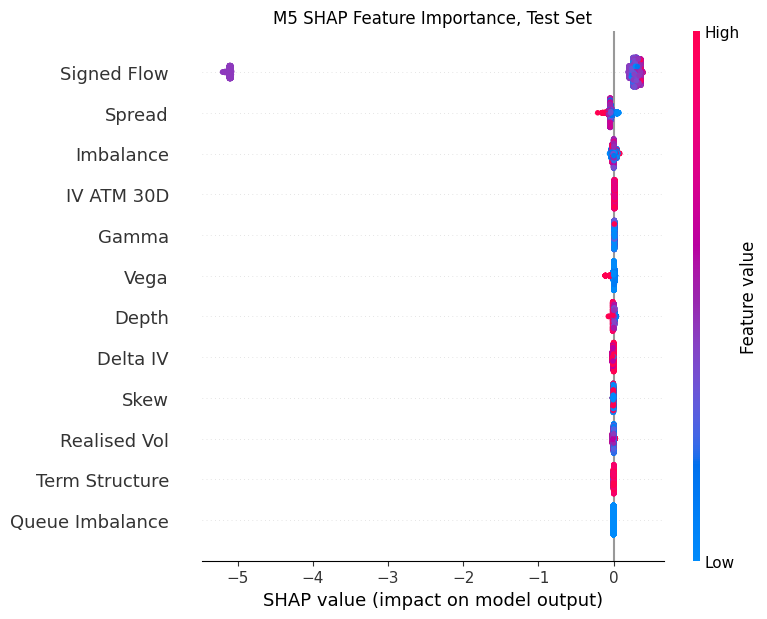

Table 5, SHAP Feature Importance (M5)
                 Mean Abs SHAP        Group
Feature                                    
Signed Flow             1.1111          LOB
Spread                  0.0461          LOB
Imbalance               0.0181          LOB
IV ATM 30D              0.0131  Derivatives
Gamma                   0.0092  Derivatives
Vega                    0.0088  Derivatives
Depth                   0.0086          LOB
Delta IV                0.0074  Derivatives
Skew                    0.0047  Derivatives
Realised Vol            0.0042          LOB
Term Structure          0.0029  Derivatives
Queue Imbalance         0.0000          LOB


In [14]:
# Table 5 and SHAP beeswarm for M5
n_shap = min(5000, len(X_te_full_f))
explainer = shap.TreeExplainer(m5_final)
shap_vals = explainer.shap_values(X_te_full_f[:n_shap])

plt.figure(figsize=(8, 5.5))
shap.summary_plot(shap_vals, X_te_full_f[:n_shap],
                  feature_names=[PRETTY[f] for f in ALL_FEATURES], show=False)
plt.title('M5 SHAP Feature Importance, Test Set')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_m5.png'), dpi=150, bbox_inches='tight')
plt.show()

table5 = (
    pd.DataFrame({'Feature': [PRETTY[f] for f in ALL_FEATURES],
                  'Mean Abs SHAP': np.abs(shap_vals).mean(axis=0),
                  'Group': ['Derivatives' if f in DERIV_FEATURES else 'LOB'
                            for f in ALL_FEATURES]})
    .sort_values('Mean Abs SHAP', ascending=False)
    .set_index('Feature')
)
print('Table 5, SHAP Feature Importance (M5)')
print(table5.round(4).to_string())

M3 permutation importance done
M6 permutation importance done


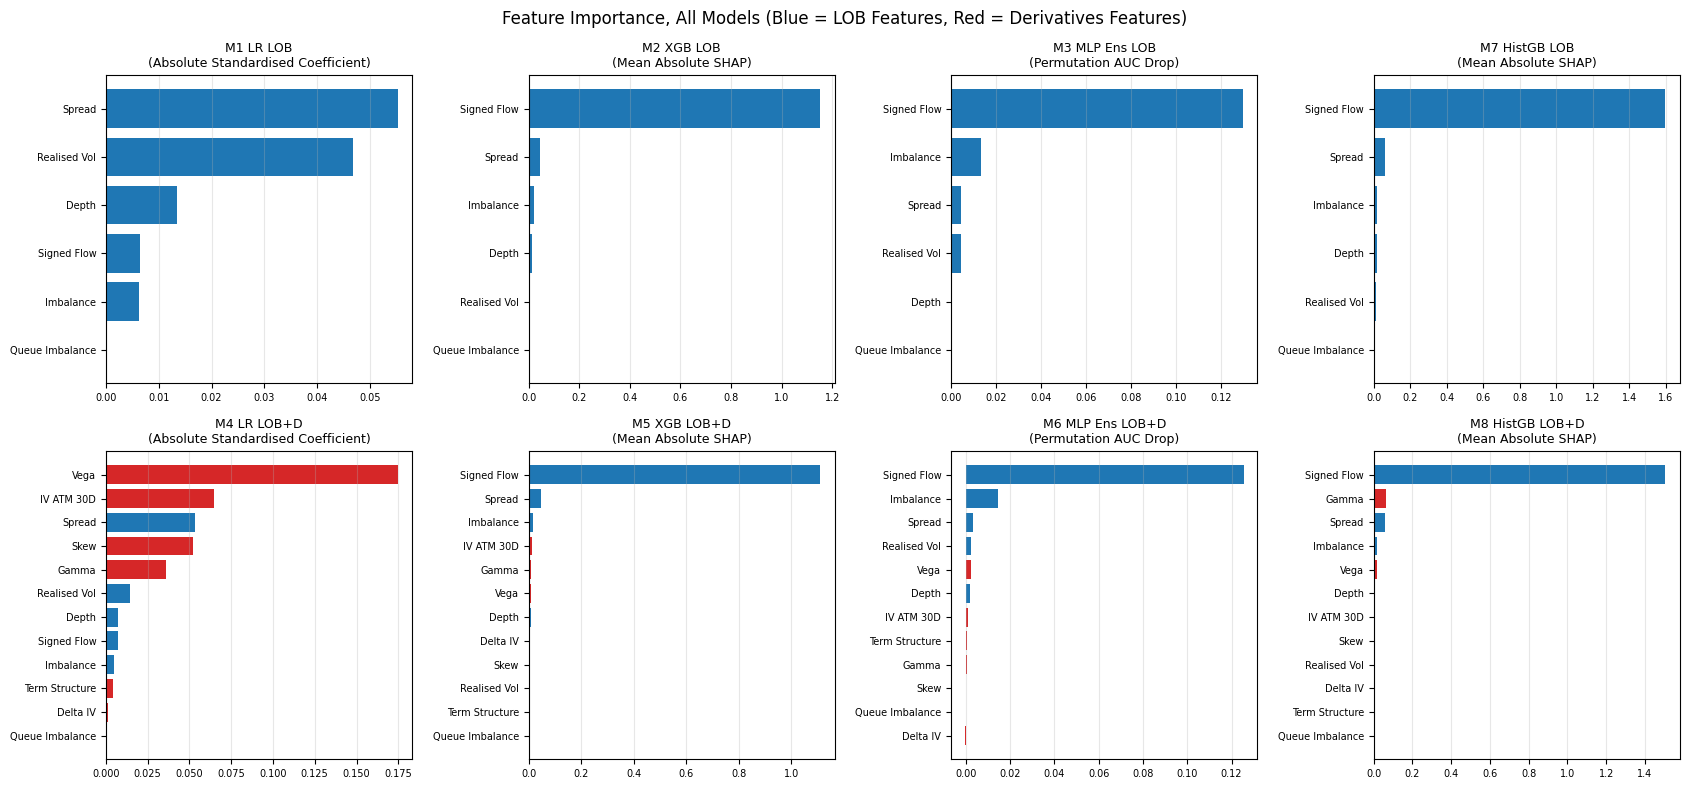

In [15]:
# feature importance for all eight models, method matched to family
IMP, METHOD = {}, {}

IMP['M1'] = pd.Series(np.abs(m1_final.coef_[0]), index=LOB_FEATURES)
IMP['M4'] = pd.Series(np.abs(m4_final.coef_[0]), index=ALL_FEATURES)
METHOD['M1'] = METHOD['M4'] = 'Absolute Standardised Coefficient'

for tag, mdl, X, feats in (('M2', m2_final, X_te_lob_p, LOB_FEATURES),
                           ('M5', m5_final, X_te_full_f, ALL_FEATURES)):
    sv = shap.TreeExplainer(mdl).shap_values(X[:5000])
    IMP[tag] = pd.Series(np.abs(sv).mean(axis=0), index=feats)
    METHOD[tag] = 'Mean Absolute SHAP'

for tag, mdl, X, feats in (('M7', m7_final, X_te_lob_p, LOB_FEATURES),
                           ('M8', m8_final, X_te_full_f, ALL_FEATURES)):
    try:
        sv = shap.TreeExplainer(mdl).shap_values(X[:5000])
        if isinstance(sv, list):
            sv = sv[1]
        IMP[tag] = pd.Series(np.abs(sv).mean(axis=0), index=feats)
        METHOD[tag] = 'Mean Absolute SHAP'
    except Exception as e:
        print(f'{tag}: SHAP unsupported ({type(e).__name__}), using permutation', flush=True)
        rng_i = np.random.RandomState(42)
        sub = rng_i.choice(len(X), 50000, replace=False)
        base = roc_auc_score(y_test_d[sub], mdl.predict_proba(X[sub])[:, 1])
        drops = []
        for j in range(X.shape[1]):
            Xp = X[sub].copy()
            Xp[:, j] = Xp[rng_i.permutation(len(sub)), j]
            drops.append(base - roc_auc_score(y_test_d[sub], mdl.predict_proba(Xp)[:, 1]))
        IMP[tag] = pd.Series(drops, index=feats)
        METHOD[tag] = 'Permutation AUC Drop'

rng_i = np.random.RandomState(42)
sub = rng_i.choice(len(X_te_lob_p), 50000, replace=False)
for tag, models, X, feats in (('M3', mlp3_models, X_te_lob_p, LOB_FEATURES),
                              ('M6', mlp6_models, X_te_full_f, ALL_FEATURES)):
    def ens_p(Xa, _models=models):
        return np.mean([m.predict_proba(Xa)[:, 1] for m in _models], axis=0)
    base = roc_auc_score(y_test_d[sub], ens_p(X[sub]))
    drops = []
    for j in range(X.shape[1]):
        Xp = X[sub].copy()
        Xp[:, j] = Xp[rng_i.permutation(len(sub)), j]
        drops.append(base - roc_auc_score(y_test_d[sub], ens_p(Xp)))
    IMP[tag] = pd.Series(drops, index=feats)
    METHOD[tag] = 'Permutation AUC Drop'
    print(f'{tag} permutation importance done', flush=True)

GRID_ORDER = ['M1', 'M2', 'M3', 'M7', 'M4', 'M5', 'M6', 'M8']
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for ax, tag in zip(axes.flat, GRID_ORDER):
    s = IMP[tag].sort_values()
    colors = ['tab:red' if f in DERIV_FEATURES else 'tab:blue' for f in s.index]
    ax.barh([PRETTY[f] for f in s.index], s.values, color=colors)
    ax.set_title(f'{NAME[tag]}\n({METHOD[tag]})', fontsize=9)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3, axis='x')
fig.suptitle('Feature Importance, All Models (Blue = LOB Features, Red = Derivatives Features)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'feature_importance_all.png'), dpi=150, bbox_inches='tight')
plt.show()

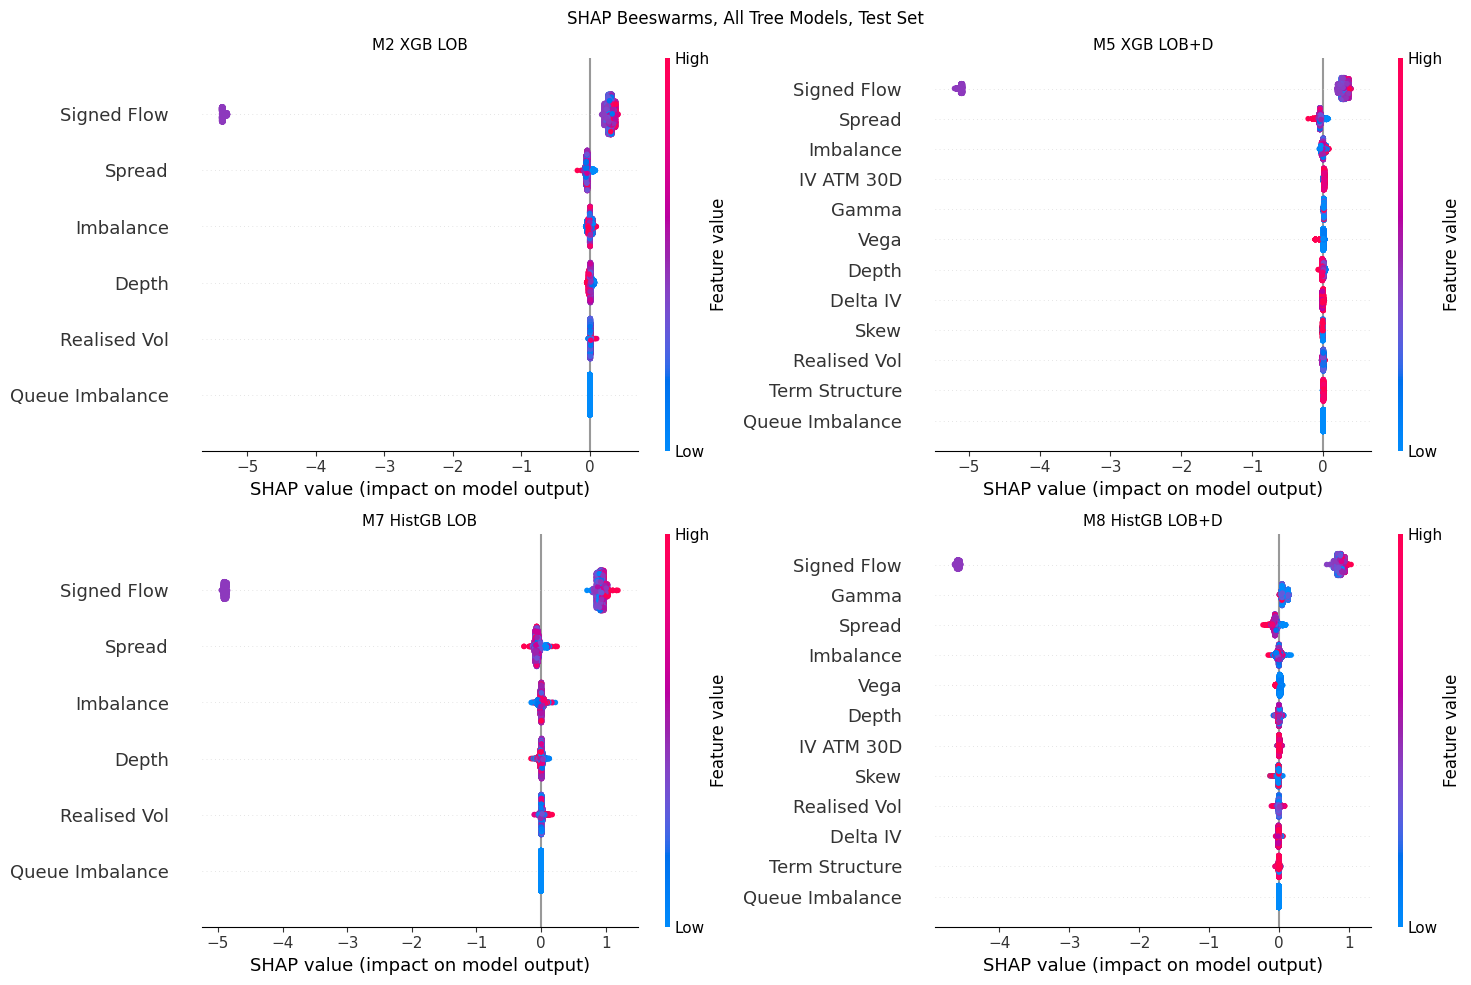

In [16]:
# SHAP beeswarms for every tree model (M2, M5, M7, M8)
TREE_MODELS = [('M2', m2_final, X_te_lob_p, LOB_FEATURES),
               ('M5', m5_final, X_te_full_f, ALL_FEATURES),
               ('M7', m7_final, X_te_lob_p, LOB_FEATURES),
               ('M8', m8_final, X_te_full_f, ALL_FEATURES)]
fig = plt.figure(figsize=(15, 10))
for k, (tag, mdl, X, feats) in enumerate(TREE_MODELS):
    ax = fig.add_subplot(2, 2, k + 1)
    plt.sca(ax)
    try:
        sv = shap.TreeExplainer(mdl).shap_values(X[:5000])
        if isinstance(sv, list):
            sv = sv[1]
        shap.summary_plot(sv, X[:5000], feature_names=[PRETTY[f] for f in feats],
                          show=False, plot_size=None, max_display=12)
        ax.set_title(NAME[tag], fontsize=11)
    except Exception as e:
        ax.text(0.5, 0.5, f'{NAME[tag]}\nSHAP unsupported ({type(e).__name__})',
                ha='center', va='center')
        ax.set_axis_off()
fig.suptitle('SHAP Beeswarms, All Tree Models, Test Set')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_all_trees.png'), dpi=150, bbox_inches='tight')
plt.show()


## Section 10: Out-of-Sample Robustness (Table 8)

The OptionMetrics cutoff is 2025-08-29, so the September to December 2025 window has no derivatives data and tests only the LOB models. This is by design. It checks whether models trained on 2024 data generalise to the second half of 2025 with no retraining and no rescaling beyond the locked train+val scaler.

The non-linear LOB models generalise strongly (pooled AUC above 0.73 against 0.63 on the primary test window). The diagnostic table below explains why the robustness window is easier rather than leaving the jump unexplained. It is a calmer regime (lower realised volatility, tighter spreads) with a lower adverse-event base rate and a lower share of active-flow bins, and Section 15.4 shows exposure prediction is a large part of headline discrimination, so a higher share of bins without directional signed flow mechanically lifts AUC. The number is therefore interpreted only as LOB-engine stability under a different regime, never as evidence about derivatives augmentation (which cannot be tested here for lack of OptionMetrics coverage). The linear model stays at chance, confirming the signal is non-linear.


In [17]:
# Table 8, OOS robustness on Sep to Dec 2025, consistent train+val scaling
def in_rob(f):
    m = re.search(r'lob_(\d{4}-\d{2}-\d{2})\.parquet', os.path.basename(f))
    return m and ROB_START <= m.group(1) <= ROB_END

rob_files  = [f for f in sorted(glob.glob(os.path.join(LOB_PROC, 'lob_*.parquet'))) if in_rob(f)]
rob_target = build_target(pd.concat([pd.read_parquet(f) for f in rob_files]))
print(f'Robustness rows: {len(rob_target):,}  adverse rate={rob_target["y"].mean():.3f}')

X_rob_f  = scaler_lob_tv.transform(rob_target[LOB_FEATURES])
y_rob    = rob_target['y'].values
days_rob = rob_target['date'].astype(str).values
uniq_rob = np.unique(days_rob)

P_ROB = {
    'M1': m1_final.predict_proba(X_rob_f)[:, 1],
    'M2': m2_final.predict_proba(X_rob_f)[:, 1],
    'M3': np.mean([m.predict_proba(X_rob_f)[:, 1] for m in mlp3_models], axis=0),
    'M7': m7_final.predict_proba(X_rob_f)[:, 1],
}

table8_rows = []
for m, p in P_ROB.items():
    wd = np.mean([roc_auc_score(y_rob[days_rob == d], p[days_rob == d])
                  for d in uniq_rob
                  if y_rob[days_rob == d].min() != y_rob[days_rob == d].max()])
    table8_rows.append({'Model': NAME[m],
                        'Pooled AUC': roc_auc_score(y_rob, p),
                        'Within-Day AUC': wd})
table8 = pd.DataFrame(table8_rows).set_index('Model')
print('Table 8, Out-of-Sample Robustness (Sep to Dec 2025, LOB models)')
print(table8.round(4).to_string())

Robustness rows: 191,977  adverse rate=0.317
Table 8, Out-of-Sample Robustness (Sep to Dec 2025, LOB models)
                Pooled AUC  Within-Day AUC
Model                                     
M1 LR LOB           0.5099          0.5139
M2 XGB LOB          0.7317          0.7226
M3 MLP Ens LOB      0.7298          0.7209
M7 HistGB LOB       0.7324          0.7235


In [18]:
# sample diagnostics, primary test window vs robustness window
def sample_diag(df, label):
    return pd.Series({
        'Rows': len(df),
        'Days': df['date'].astype(str).nunique(),
        'Adverse Rate': df['y'].mean(),
        'Active Flow Share': (df['quote_dir'] != 0).mean(),
        'Mean Spread USD': df['spread'].mean(),
        'Median Spread USD': df['spread'].median(),
        'Mean Abs Signed Flow': df['signed_flow'].abs().mean(),
        'Mean Realised Vol (1e-5)': df['realised_vol'].mean() * 1e5,
    }, name=label)


diag = pd.concat([sample_diag(test_d, 'Test May-Aug 2025'),
                  sample_diag(rob_target, 'Robustness Sep-Dec 2025')], axis=1)
print('Sample diagnostics, why the robustness window is easier')
print(diag.round(4).to_string())


Sample diagnostics, why the robustness window is easier
                          Test May-Aug 2025  Robustness Sep-Dec 2025
Rows                            193057.0000              191977.0000
Days                                83.0000                  83.0000
Adverse Rate                         0.3878                   0.3172
Active Flow Share                    0.8583                   0.6940
Mean Spread USD                      0.0235                   0.0266
Median Spread USD                    0.0200                   0.0200
Mean Abs Signed Flow               444.2684                 151.3032
Mean Realised Vol (1e-5)             0.5218                   0.6788


## Section 11: Results Summary and Final Hyperparameters

Consolidated output of Sections 8 to 10 for the report, plus the Appendix C hyperparameter record. The calibration and decision-layer tables (6 and 7) follow in Section 13.


In [19]:
print('Table 3, Predictive Performance')
print(table3.round(4).to_string())

print('\nTable 4, Information-Set Gains')
print(table4.to_string())

print('\nTable 5, SHAP Feature Importance (M5)')
print(table5.round(4).to_string())

print('\nTable 8, Out-of-Sample Robustness')
print(table8.round(4).to_string())

print('\nAppendix C, Final Hyperparameters')
for k, v in {
    'M1 LR C':            best_C1,
    'M4 LR C':            best_C4,
    'M2 XGB':             f'{params2} n_estimators={ep2}',
    'M5 XGB':             f'{params5} n_estimators={ep5}',
    'M3 MLP alpha':       f'{alpha3} ensemble seeds {SEEDS}',
    'M6 MLP alpha':       f'{alpha6} ensemble seeds {SEEDS}',
    'M7 HistGB':          params7,
    'M8 HistGB':          params8,
}.items():
    print(f'  {k}: {v}')

Table 3, Predictive Performance
                  Pooled AUC         Pooled CI  Within-Day AUC     Within-Day CI  Balanced Acc   Tau
Model                                                                                               
M1 LR LOB             0.5155  [0.5130, 0.5182]          0.5050  [0.5016, 0.5085]        0.4993  0.53
M2 XGB LOB            0.6326  [0.6301, 0.6351]          0.6103  [0.5852, 0.6390]        0.6157  0.51
M3 MLP Ens LOB        0.6298  [0.6274, 0.6323]          0.6081  [0.5832, 0.6368]        0.6142  0.11
M4 LR LOB+D           0.5523  [0.5497, 0.5550]          0.5059  [0.5024, 0.5094]        0.5068  0.47
M5 XGB LOB+D          0.6314  [0.6288, 0.6338]          0.6101  [0.5848, 0.6390]        0.6157  0.49
M6 MLP Ens LOB+D      0.6304  [0.6280, 0.6329]          0.6073  [0.5829, 0.6356]        0.6143  0.23
M7 HistGB LOB         0.6334  [0.6309, 0.6358]          0.6109  [0.5856, 0.6397]        0.6140  0.41
M8 HistGB LOB+D       0.6304  [0.6279, 0.6330]          0.6

## Section 12: Diagnostics and Conditioning

Visual and conditional diagnostics on the final models. Every figure shows all relevant models and is saved to `Figures/`.

| Subsection | Content | Figure |
|---|---|---|
| 12.1 | ROC curves, all eight models, curve AUCs verified against Table 3 | `roc_curves.png` |
| 12.2 | Rolling weekly AUC through the test window | `rolling_weekly_auc.png` |
| 12.3 | Feature correlations and the pooled vs within-day comparison | `feature_correlation.png`, `withinday_vs_pooled.png` |
| 12.4 | Adverse rate by probability decile (Appendix E) | `decile_lift.png` |
| 12.5 | Regime and time-of-day conditioning (Appendix D) | printed tables |


### 12.1 ROC curves

The curves look close to straight lines between the corners, which is the correct geometry for AUCs in the low 0.60s on a large sample. The legend AUCs are computed by trapezoidal integration of the plotted curves and asserted equal to the Table 3 values, so the curves and the table cannot drift apart. The visible gap separates the linear models from everything else. Within each family, the dotted (LOB only) and solid (LOB plus derivatives) curves overlap almost exactly, which is the graphical statement of the null result.


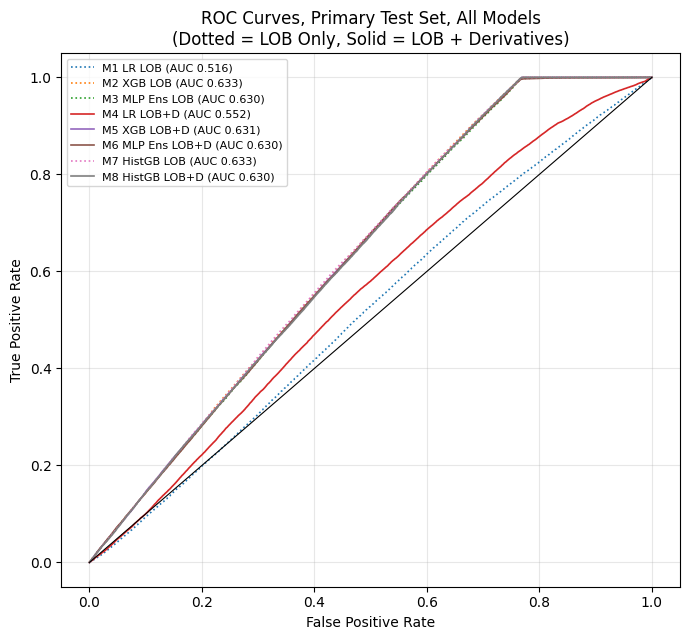

In [20]:
fig, ax = plt.subplots(figsize=(7, 6.5))
for m in ORDER8:
    fpr, tpr, _ = roc_curve(y_test_d, P_TE[m])
    auc_plot = np.trapz(tpr, fpr)
    auc_tab = roc_auc_score(y_test_d, P_TE[m])
    assert abs(auc_plot - auc_tab) < 1e-6, f'{m} curve and table disagree'
    ax.plot(fpr, tpr, color=COLOR[m], ls=LS[m], lw=1.2,
            label=f'{NAME[m]} (AUC {auc_tab:.3f})')
ax.plot([0, 1], [0, 1], color='k', lw=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves, Primary Test Set, All Models\n(Dotted = LOB Only, Solid = LOB + Derivatives)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

### 12.2 Rolling weekly AUC

The test window opens immediately after the April and May 2025 tariff shock, so the early weeks are a stress regime and the later weeks a normalisation. Weekly AUC shows whether performance is stable through that transition. Weeks with fewer than 500 observations or one outcome class are skipped.


                M1      M2      M3      M4      M5      M6      M7      M8
2025-04-28  0.5135  0.6588  0.6576  0.5167  0.6604  0.6470  0.6506  0.6517
2025-05-05  0.5133  0.6768  0.6717  0.5059  0.6752  0.6720  0.6745  0.6724
2025-05-12  0.5291  0.5956  0.5918  0.5010  0.5963  0.5921  0.5983  0.5980
2025-05-19  0.5152  0.5613  0.5591  0.5386  0.5671  0.5680  0.5614  0.5645
2025-05-26  0.4982  0.5285  0.5251  0.5016  0.5234  0.5233  0.5325  0.5248
2025-06-02  0.4968  0.5317  0.5330  0.5001  0.5309  0.5373  0.5347  0.5337
2025-06-09  0.5142  0.5376  0.5328  0.5124  0.5385  0.5312  0.5401  0.5430
2025-06-16  0.5162  0.5485  0.5449  0.5215  0.5527  0.5487  0.5506  0.5541
2025-06-23  0.4940  0.5344  0.5362  0.5058  0.5312  0.5357  0.5392  0.5334
2025-06-30  0.4920  0.5323  0.5306  0.4920  0.5315  0.5323  0.5277  0.5331
2025-07-07  0.4973  0.5346  0.5339  0.4994  0.5316  0.5339  0.5360  0.5326
2025-07-14  0.4891  0.5393  0.5367  0.5187  0.5369  0.5341  0.5392  0.5317
2025-07-21  0.4865  0.544

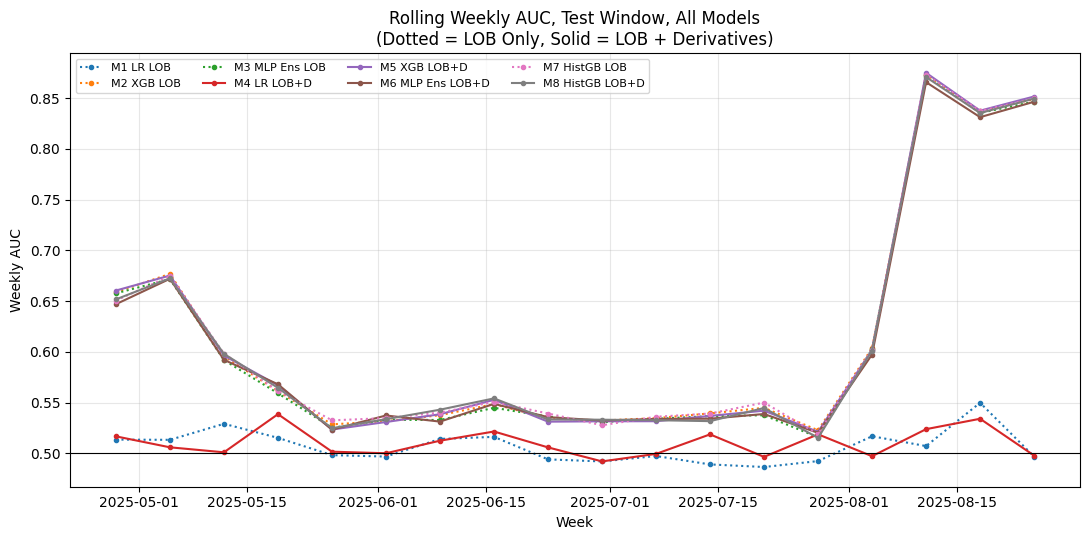

In [21]:
week = pd.to_datetime(pd.Series(days_te)).dt.to_period('W').dt.start_time.values
weekly = {}
for wk in np.unique(week):
    ix = np.where(week == wk)[0]
    if len(ix) < 500 or y_test_d[ix].min() == y_test_d[ix].max():
        continue
    weekly[wk] = {m: roc_auc_score(y_test_d[ix], P_TE[m][ix]) for m in ORDER8}
wdf = pd.DataFrame(weekly).T.sort_index()
print(wdf.round(4).to_string())

fig, ax = plt.subplots(figsize=(11, 5.5))
for m in ORDER8:
    ax.plot(wdf.index, wdf[m], color=COLOR[m], ls=LS[m], marker='o', ms=3, label=NAME[m])
ax.axhline(0.5, color='k', lw=0.8)
ax.set_ylabel('Weekly AUC')
ax.set_xlabel('Week')
ax.set_title('Rolling Weekly AUC, Test Window, All Models\n(Dotted = LOB Only, Solid = LOB + Derivatives)')
ax.legend(ncol=4, fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'rolling_weekly_auc.png'), dpi=150, bbox_inches='tight')
plt.show()

### 12.3 Feature correlations and pooled vs within-day AUC

The correlation matrix (training window) documents that the LOB and derivatives blocks are nearly orthogonal, so the derivatives features add an independent input dimension, and that the derivatives block has strong internal structure (IV level, term structure and vega are mechanically related). `queue_imb` is omitted because it is identically zero.

The paired bar chart restates Table 3 visually. The gap between each model's pooled and within-day bar is the between-day component, exactly the part of pooled AUC that day-constant features can inflate without intraday information.


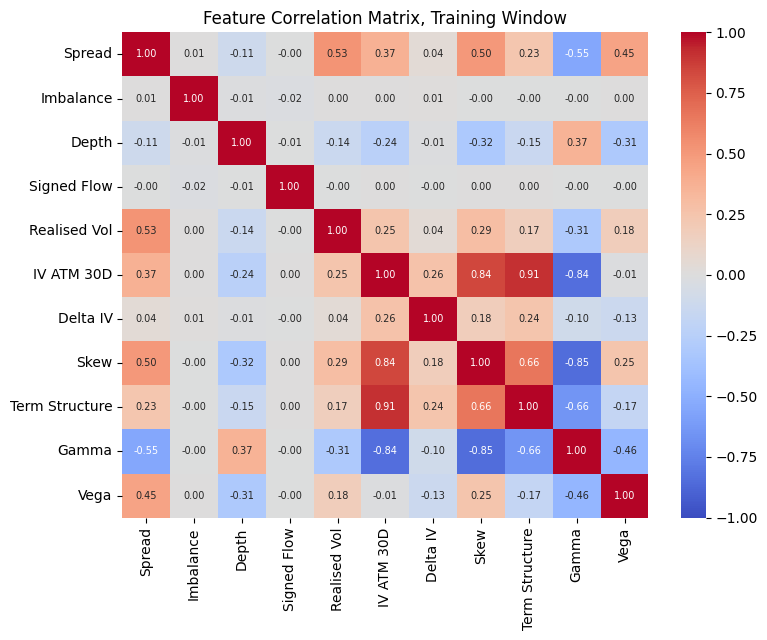

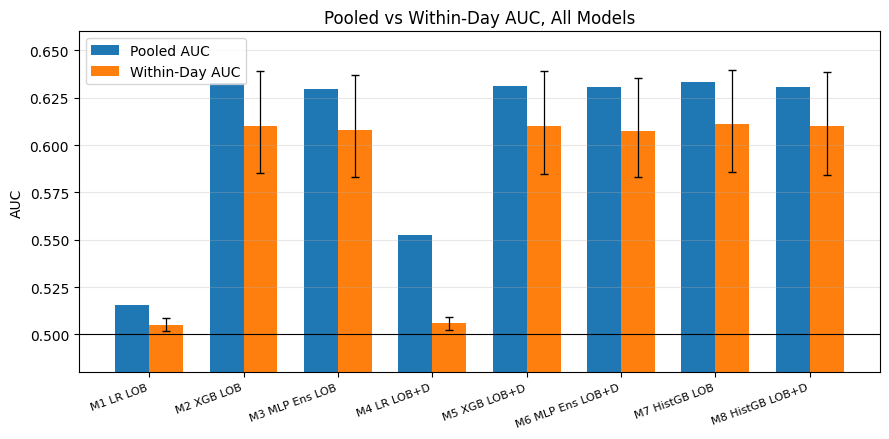

In [22]:
corr_feats = [f for f in ALL_FEATURES if f != 'queue_imb']
corr = train_d[corr_feats].corr()
corr.index = [PRETTY[f] for f in corr_feats]
corr.columns = [PRETTY[f] for f in corr_feats]
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            annot_kws={'size': 7}, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix, Training Window')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'feature_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

pooled_vals = [roc_auc_score(y_test_d, P_TE[m]) for m in ORDER8]
within_vals = [DAILY[m].mean() for m in ORDER8]
within_ci = np.array([boot_mean_ci(DAILY[m].values) for m in ORDER8])
yerr = np.vstack([np.array(within_vals) - within_ci[:, 0], within_ci[:, 1] - np.array(within_vals)])
xb = np.arange(len(ORDER8))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(xb - 0.18, pooled_vals, width=0.36, color='tab:blue', label='Pooled AUC')
ax.bar(xb + 0.18, within_vals, width=0.36, color='tab:orange', label='Within-Day AUC',
       yerr=yerr, capsize=3, error_kw={'lw': 0.9})
ax.axhline(0.5, color='k', lw=0.8)
ax.set_xticks(xb)
ax.set_xticklabels([NAME[m] for m in ORDER8], rotation=20, ha='right', fontsize=8)
ax.set_ylim(0.48, 0.66)
ax.set_ylabel('AUC')
ax.set_title('Pooled vs Within-Day AUC, All Models')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'withinday_vs_pooled.png'), dpi=150, bbox_inches='tight')
plt.show()

### 12.4 Adverse rate by probability decile (Appendix E)

A rank-quality check independent of calibration. Observations are sorted into deciles of each model's raw predicted probability, and the realised adverse rate is computed per decile. The non-linear models earn much of their discrimination by identifying clearly safe intervals. Their bottom decile carries an adverse rate near zero against a 0.37 base rate. Part of that bottom-decile purity is mechanical, intervals without net directional signed flow (no trades, side-unknown volume, or buys and sells netting out) have no defined exposure direction and are labelled zero by convention, which the models learn through the `signed_flow` feature. The top decile reaches roughly 0.48. The desk use case therefore includes tightening quotes in safe windows, not only widening in risky ones.


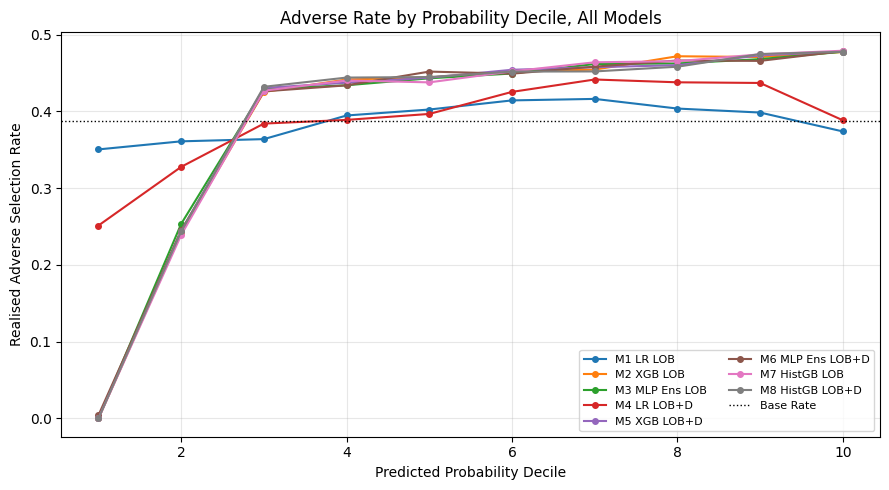

Appendix E, Adverse Rate by Decile
     M1 LR LOB  M2 XGB LOB  M3 MLP Ens LOB  M4 LR LOB+D  M5 XGB LOB+D  M6 MLP Ens LOB+D  M7 HistGB LOB  M8 HistGB LOB+D
D1       0.350       0.000           0.000        0.251         0.000             0.004          0.000            0.000
D2       0.361       0.242           0.253        0.328         0.245             0.245          0.239            0.244
D3       0.364       0.425           0.429        0.384         0.430             0.426          0.427            0.432
D4       0.395       0.441           0.434        0.389         0.437             0.434          0.440            0.444
D5       0.402       0.444           0.443        0.397         0.444             0.452          0.438            0.445
D6       0.414       0.452           0.449        0.425         0.454             0.449          0.452            0.452
D7       0.416       0.454           0.462        0.441         0.457             0.458          0.464            0.452
D8   

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
decile_tab = {}
for m in ORDER8:
    qd = pd.qcut(P_TE[m], 10, labels=False, duplicates='drop')
    rates = [y_test_d[qd == k].mean() for k in range(int(qd.max()) + 1)]
    decile_tab[NAME[m]] = rates
    ax.plot(range(1, len(rates) + 1), rates, marker='o', ms=4,
            color=COLOR[m], label=NAME[m])
ax.axhline(y_test_d.mean(), color='k', ls=':', lw=1, label='Base Rate')
ax.set_xlabel('Predicted Probability Decile')
ax.set_ylabel('Realised Adverse Selection Rate')
ax.set_title('Adverse Rate by Probability Decile, All Models')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'decile_lift.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Appendix E, Adverse Rate by Decile')
print(pd.DataFrame(decile_tab, index=[f'D{i + 1}' for i in range(10)]).round(3).to_string())

### 12.5 Regime and time-of-day conditioning (Appendix D)

If the derivatives features carried intraday signal anywhere, it should surface in some conditional pocket, such as high or low IV regimes (the Cremers and Weinbaum mechanism predicts more options information when the options market is active) or particular session buckets (an overnight-gap effect would concentrate at the open). The within-day paired gains are computed per day-level IV regime and the pooled gains per session bucket.

Neither conditioning reveals a pocket. The within-day gains hover at zero in both IV regimes for every non-linear family, and no session bucket shows a stable derivatives advantage. The day-constant nature of the features leaves them nothing to say about which intervals within the session are dangerous, in any regime, at any time of day.


In [24]:
iv_day = test_d.groupby(test_d['date'].astype(str))['iv_atm_30'].first()
iv_med = test_d['iv_atm_30'].median()
hi_days = set(iv_day[iv_day > iv_med].index)

print('Appendix D Panel A, within-day paired gain by day-level IV regime')
for a, b in PAIRS:
    dw = (DAILY[b] - DAILY[a]).dropna()
    hi = dw[dw.index.isin(hi_days)]
    lo_ = dw[~dw.index.isin(hi_days)]
    print(f'  {a} to {b}: high-IV days {hi.mean():+.4f} (n={len(hi)})   '
          f'low-IV days {lo_.mean():+.4f} (n={len(lo_)})')

hours = np.array([t.hour + t.minute / 60 for t in test_d.index.time])
print('\nAppendix D Panel B, pooled AUC gain by session bucket')
for bname, msk in (('Open 09:30-11:00', (hours >= 9.5) & (hours < 11)),
                   ('Midday 11:00-14:00', (hours >= 11) & (hours < 14)),
                   ('Close 14:00-16:00', (hours >= 14) & (hours < 16))):
    y_b = y_test_d[msk]
    row = f'  {bname} (n={msk.sum():,}): '
    for a, b in PAIRS:
        d = roc_auc_score(y_b, P_TE[b][msk]) - roc_auc_score(y_b, P_TE[a][msk])
        row += f'{a}-{b} {d:+.4f}   '
    print(row)

Appendix D Panel A, within-day paired gain by day-level IV regime
  M1 to M4: high-IV days +0.0015 (n=41)   low-IV days +0.0002 (n=42)
  M2 to M5: high-IV days +0.0002 (n=41)   low-IV days -0.0006 (n=42)
  M3 to M6: high-IV days +0.0001 (n=41)   low-IV days -0.0017 (n=42)
  M7 to M8: high-IV days +0.0000 (n=41)   low-IV days -0.0022 (n=42)

Appendix D Panel B, pooled AUC gain by session bucket
  Open 09:30-11:00 (n=44,820): M1-M4 +0.0411   M2-M5 -0.0003   M3-M6 +0.0001   M7-M8 -0.0020   
  Midday 11:00-14:00 (n=89,279): M1-M4 +0.0276   M2-M5 -0.0013   M3-M6 +0.0002   M7-M8 -0.0024   
  Close 14:00-16:00 (n=58,958): M1-M4 +0.0403   M2-M5 -0.0010   M3-M6 +0.0021   M7-M8 -0.0028   


### 12.6 Latent regime conditioning (Markov switching)

The IV-median split in 12.5 conditions on an observed variable. A natural objection is that the relevant volatility regime is latent, and that derivatives information might earn its keep only inside a properly identified stress state. To close that door, a two-state Gaussian Markov-switching model (switching mean and variance) is fitted to daily log realised volatility, and the test days are classified by the filtered (causal, one-sided) regime probability. The within-day information-set gains are then recomputed inside each latent regime.

One disclosed caveat. The switching parameters are estimated on the full daily sample for stability (415 observations split across two regimes leaves little room for a pure out-of-sample fit), so the regime labels carry a mild look-ahead through the parameters, though the filtering itself is one-sided. For a conditioning diagnostic this is acceptable and it biases toward finding regime pockets, which makes the null below stronger.

**Reading the output.** The filtered high-volatility state lines up closely with the tariff-shock weeks and with the high-IV day split, and the within-day derivatives gains remain statistically zero inside both latent regimes for every non-linear family.


High-volatility latent state: regime 1
Days classified high-vol (filtered p > 0.5): 167 of 494
Test window: 24 high-vol days, 59 low-vol days
Agreement with the IV-median day split: 72%

Within-day information-set gains by latent regime
  M1 to M4: high-vol +0.0014 (n=24)   low-vol +0.0006 (n=59)
  M2 to M5: high-vol +0.0005 (n=24)   low-vol -0.0005 (n=59)
  M3 to M6: high-vol -0.0002 (n=24)   low-vol -0.0011 (n=59)
  M7 to M8: high-vol -0.0009 (n=24)   low-vol -0.0011 (n=59)


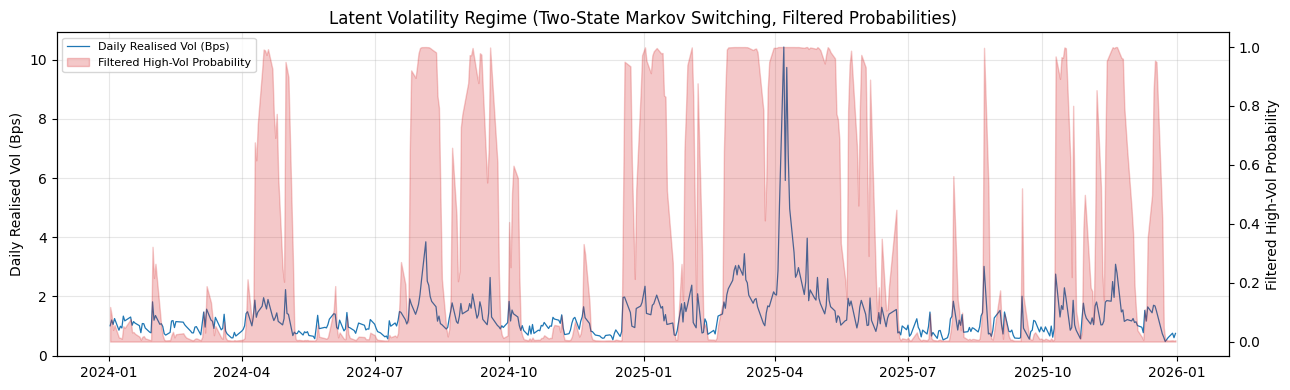

In [25]:
# two-state Markov switching on daily log realised volatility
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

day_rv_all = (lob_target.groupby(lob_target['date'].astype(str))['mid']
              .apply(lambda s: s.pct_change().std() * 1e4))
log_rv = np.log(day_rv_all.clip(lower=1e-6))
ms_mod = MarkovRegression(log_rv.values, k_regimes=2, trend='c', switching_variance=True)
ms_res = ms_mod.fit(search_reps=20)
filt = ms_res.filtered_marginal_probabilities
hi_state = int(np.argmax([ms_res.params[ms_mod.param_names.index(f'const[{k}]')]
                          for k in range(2)]))
p_hi = pd.Series(filt[:, hi_state], index=log_rv.index)
print(f'High-volatility latent state: regime {hi_state}')
print(f'Days classified high-vol (filtered p > 0.5): {(p_hi > 0.5).sum()} of {len(p_hi)}')

test_days_set = set(uniq_days)
hi_latent = {d for d in test_days_set if p_hi.get(d, 0) > 0.5}
print(f'Test window: {len(hi_latent)} high-vol days, {len(test_days_set) - len(hi_latent)} low-vol days')
agree = np.mean([(d in hi_latent) == (d in hi_days) for d in test_days_set])
print(f'Agreement with the IV-median day split: {100 * agree:.0f}%')

print('\nWithin-day information-set gains by latent regime')
for a, b in PAIRS:
    dw = (DAILY[b] - DAILY[a]).dropna()
    hi = dw[dw.index.isin(hi_latent)]
    lo_ = dw[~dw.index.isin(hi_latent)]
    print(f'  {a} to {b}: high-vol {hi.mean():+.4f} (n={len(hi)})   '
          f'low-vol {lo_.mean():+.4f} (n={len(lo_)})')

fig, ax = plt.subplots(figsize=(13, 4))
x_days = pd.to_datetime(p_hi.index)
ax.plot(x_days, day_rv_all.values, color='tab:blue', lw=0.9, label='Daily Realised Vol (Bps)')
ax2 = ax.twinx()
ax2.fill_between(x_days, 0, p_hi.values, color='tab:red', alpha=0.25,
                 label='Filtered High-Vol Probability')
ax.set_ylabel('Daily Realised Vol (Bps)')
ax2.set_ylabel('Filtered High-Vol Probability')
ax.set_title('Latent Volatility Regime (Two-State Markov Switching, Filtered Probabilities)')
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'latent_regime.png'), dpi=150, bbox_inches='tight')
plt.show()


## Section 13: Calibration and the Deployable Decision Rule

The raw probability outputs of the boosted models are poorly calibrated (compressed around the threshold), which makes fixed-threshold rules hard to interpret. This section fixes the decision layer and validates its economics with inference that respects the data structure.

| Subsection | Question answered | Output |
|---|---|---|
| 13.1 | Are the probabilities trustworthy after calibration? | Table 6, reliability curves, probability histograms |
| 13.2 | What is the desk-ready operating point and is its gain real? | Table 7, day-block bootstrap CIs, threshold sweep |


### 13.1 Probability calibration (Table 6)

Isotonic regression is fitted on each final model's validation-window predictions and applied to its test predictions. Quality is measured by the Brier score and the expected calibration error (ECE, 10 equal-width bins). Isotonic maps are monotone, so AUC is preserved up to ties.

Isotonic calibration is highly effective for the XGBoost models (M2 ECE drops by an order of magnitude) and the HistGB models are well calibrated raw. The isotonic map slightly worsens M4, whose validation and test probability distributions differ. One methodological note. The final models saw the validation window during fitting, so the calibration map is fitted on partially in-sample predictions. The alternative (calibrating a train-only model) introduces a probability-scale mismatch with the deployed model instead, so this option is used and disclosed.

The calibrated probabilities concentrate near the 37% base rate. That is the honest statement of signal strength at 10 seconds. Discrimination is real but the implied probability shifts are modest, which is why the decision threshold must be chosen on economic grounds rather than at the classical 0.5.


Table 6, Probability Calibration (Isotonic Fitted on Validation)
                  Brier Raw  Brier Iso  ECE Raw  ECE Iso
Model                                                   
M1 LR LOB            0.2509     0.2389   0.1162   0.0383
M2 XGB LOB           0.2231     0.2123   0.0968   0.0017
M3 MLP Ens LOB       0.2144     0.2129   0.0152   0.0016
M4 LR LOB+D          0.2379     0.2430   0.0428   0.0800
M5 XGB LOB+D         0.2220     0.2125   0.0916   0.0052
M6 MLP Ens LOB+D     0.2142     0.2137   0.0187   0.0104
M7 HistGB LOB        0.2123     0.2135   0.0020   0.0198
M8 HistGB LOB+D      0.2126     0.2162   0.0068   0.0343


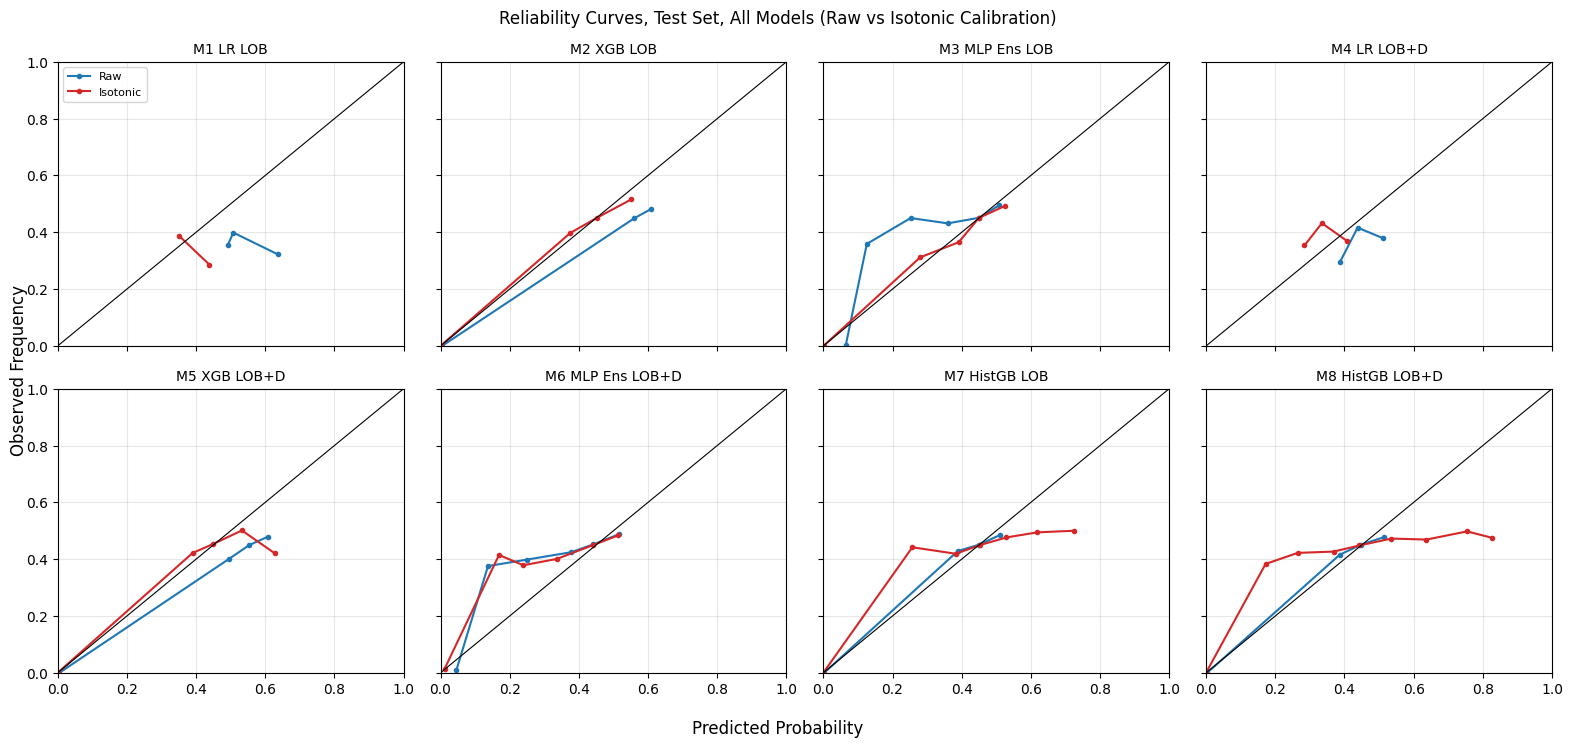

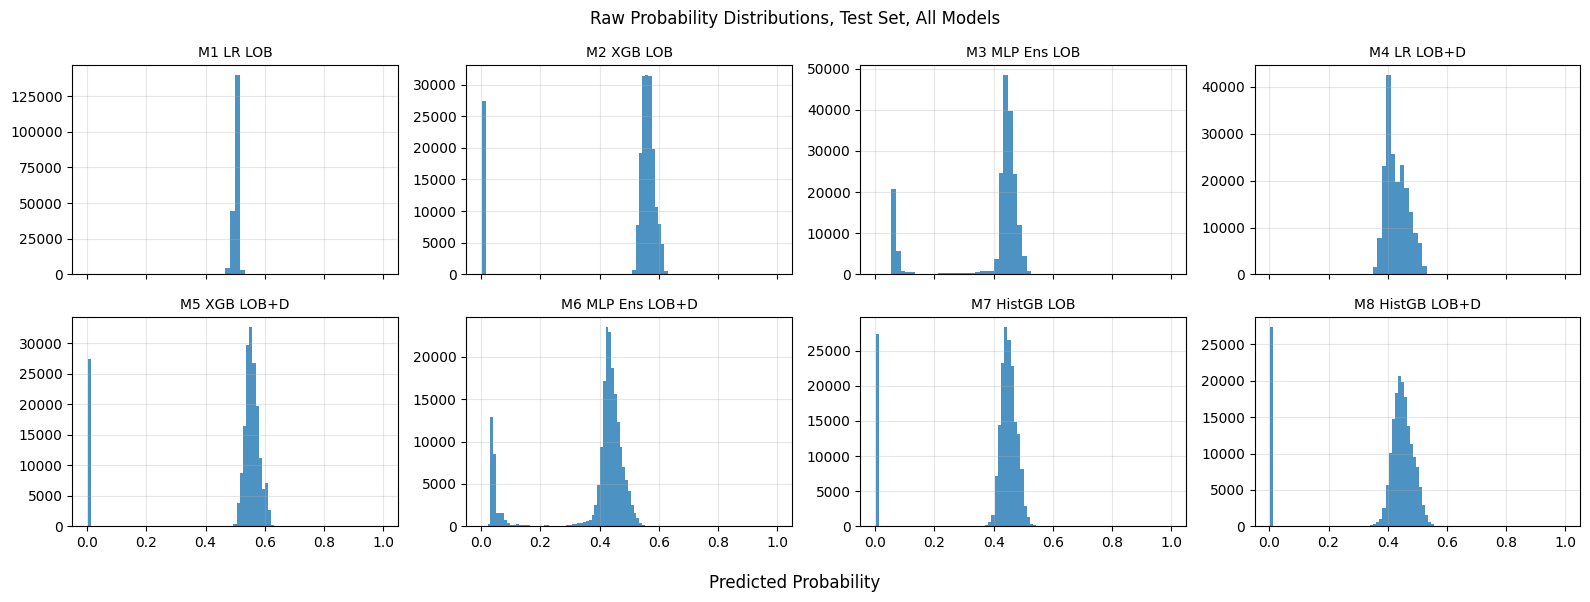

In [26]:
def ece(y_true, p, n_bins=10):
    bins = np.clip((p * n_bins).astype(int), 0, n_bins - 1)
    total = 0.0
    for b in range(n_bins):
        msk = bins == b
        if msk.sum():
            total += msk.mean() * abs(y_true[msk].mean() - p[msk].mean())
    return total


P_ISO, ISO, table6_rows = {}, {}, []
for m in ORDER8:
    iso = IsotonicRegression(out_of_bounds='clip').fit(P_VA[m], y_val_d)
    ISO[m] = iso
    P_ISO[m] = iso.predict(P_TE[m])
    table6_rows.append({
        'Model': NAME[m],
        'Brier Raw': brier_score_loss(y_test_d, P_TE[m]),
        'Brier Iso': brier_score_loss(y_test_d, P_ISO[m]),
        'ECE Raw': ece(y_test_d, P_TE[m]),
        'ECE Iso': ece(y_test_d, P_ISO[m]),
    })
table6 = pd.DataFrame(table6_rows).set_index('Model')
print('Table 6, Probability Calibration (Isotonic Fitted on Validation)')
print(table6.round(4).to_string())

fig, axes = plt.subplots(2, 4, figsize=(16, 7.5), sharex=True, sharey=True)
for ax, m in zip(axes.flat, ORDER8):
    for p, lab, c in ((P_TE[m], 'Raw', 'tab:blue'), (P_ISO[m], 'Isotonic', 'tab:red')):
        bins = np.clip((p * 10).astype(int), 0, 9)
        xs, ys = [], []
        for b in range(10):
            msk = bins == b
            if msk.sum() < 50:
                continue
            xs.append(p[msk].mean())
            ys.append(y_test_d[msk].mean())
        ax.plot(xs, ys, marker='o', ms=3, color=c, label=lab)
    ax.plot([0, 1], [0, 1], color='k', lw=0.8)
    ax.set_title(NAME[m], fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
axes[0, 0].legend(fontsize=8)
fig.supxlabel('Predicted Probability')
fig.supylabel('Observed Frequency')
fig.suptitle('Reliability Curves, Test Set, All Models (Raw vs Isotonic Calibration)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'reliability_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex=True)
for ax, m in zip(axes.flat, ORDER8):
    ax.hist(P_TE[m], bins=60, color='tab:blue', alpha=0.8)
    ax.set_title(NAME[m], fontsize=10)
    ax.grid(alpha=0.3)
fig.supxlabel('Predicted Probability')
fig.suptitle('Raw Probability Distributions, Test Set, All Models')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'probability_histograms.png'), dpi=150, bbox_inches='tight')
plt.show()

### 13.2 Deployable decision rule and day-block inference (Table 7)

**The rule.** Flag the next 10 seconds as high adverse-selection risk when the isotonic-calibrated probability is at or above tau star. The threshold is selected on the calibrated validation window by maximising outlier-robust spread-capture gain subject to a flag rate of at most 60% (a desk that quotes defensively most of the day forgoes the volume that pays for the system). Evaluation is on the outlier-robust test subset, excluding the first session minute and rows with spread above one dollar (Section 12.5 of the development history documented how a small set of wide synthetic-NBBO spreads otherwise dominates dollar aggregates).

**Why day-block bootstrap.** Observations within a day share the day's volatility and the same broadcast derivatives values, so an iid bootstrap understates variance. Days are resampled with replacement, 1,000 draws, identical draws across models so pairwise differences are valid.

**Units disclaimer.** All dollar figures here and downstream are markout-based spread-capture proxy improvements per candidate quoted 10-second interval. They are not realised PnL. Fill probability, queue position, inventory, fees, rebates, hedging costs and latency are outside the locked scope and would all shrink the realised number.

**Reading the output.** M1 is degenerate. Its calibrated probabilities are nearly constant, so no admissible threshold exists on validation and the quantile fallback flags essentially everything, leaving an uninterpretable sliver of unflagged intervals (its row is reported for completeness and excluded from comparisons). Every other rule, including the HistGB pair, earns a positive, CI-validated gain. Pairwise, adding derivatives lifts the XGBoost rule by about two tenths of a cent per 10-second interval with probability one across draws, but it lowers the MLP and HistGB rules. The day-level economic value of derivatives is therefore real but engine-specific, not universal across families, and it comes from day-level placement of the calibrated probabilities (Section 17 identifies the mechanism), not from intraday signal.


In [27]:
# robust subsets and spread-capture columns
def robust_frame(df):
    tod = df.index.time
    first_min = np.array([t.hour == 9 and t.minute == 30 for t in tod])
    rbm = (~first_min) & (df['spread'] <= 1.0).values
    out = df[rbm].copy()
    out['markout'] = (out['mid_change'] * out['quote_dir']).values
    out['spr_cap'] = out['half_spread'].values - np.clip(out['markout'].values, 0, None)
    return rbm, out


rb, tr_r = robust_frame(test_d)
rb_v, val_r = robust_frame(val_d)
print(f'Robust subsets: test {rb.sum():,}/{len(test_d):,}  val {rb_v.sum():,}/{len(val_d):,}')


def mm_stats(df, flagged):
    spr_cap = df['spr_cap'].values
    unfl = ~flagged
    if unfl.sum() == 0 or flagged.sum() == 0:
        return None
    return {'flag_rate': flagged.mean(),
            'd_spr_cap': spr_cap[unfl].mean() - spr_cap.mean()}


P_VA_ISO = {m: ISO[m].predict(P_VA[m]) for m in ORDER8}
tau_star, rule = {}, {}
for m in ORDER8:
    pv = P_VA_ISO[m][rb_v]
    best_t, best_g = None, -np.inf
    for t in np.arange(0.05, 0.95, 0.01):
        flg = pv >= t
        if not (0.02 <= flg.mean() <= 0.60):
            continue
        s = mm_stats(val_r, flg)
        if s and s['d_spr_cap'] > best_g:
            best_g, best_t = s['d_spr_cap'], t
    if best_t is None:
        best_t = float(np.quantile(pv, 0.60))
        print(f'NOTE: {m} has no admissible threshold on validation, quantile fallback')
    tau_star[m] = best_t
    rule[m] = mm_stats(tr_r, P_ISO[m][rb] >= best_t)
    if rule[m] is None:
        tau_star[m] = float(np.quantile(P_ISO[m][rb], 0.60))
        rule[m] = mm_stats(tr_r, P_ISO[m][rb] >= tau_star[m])
        print(f'NOTE: {m} degenerate at validation tau star, fell back to test 60th percentile')

# day-block bootstrap, shared draws across models
days_r = tr_r['date'].astype(str).values
uniq_r = np.unique(days_r)
ridx = {d: np.where(days_r == d)[0] for d in uniq_r}
spr_cap_r = tr_r['spr_cap'].values
flags_r = {m: (P_ISO[m][rb] >= tau_star[m]) for m in ORDER8}
per_day = {}
for d in uniq_r:
    ix = ridx[d]
    st = {'n': len(ix), 'sum': spr_cap_r[ix].sum()}
    for m in ORDER8:
        u = ~flags_r[m][ix]
        st[f'nu_{m}'], st[f'su_{m}'] = u.sum(), spr_cap_r[ix][u].sum()
    per_day[d] = st
rngd = np.random.RandomState(42)
rule_draws = {m: np.empty(N_BOOT) for m in ORDER8}
for b in range(N_BOOT):
    smp = rngd.choice(uniq_r, len(uniq_r), replace=True)
    ntot = sum(per_day[d]['n'] for d in smp)
    ctot = sum(per_day[d]['sum'] for d in smp)
    for m in ORDER8:
        nu = sum(per_day[d][f'nu_{m}'] for d in smp)
        su = sum(per_day[d][f'su_{m}'] for d in smp)
        rule_draws[m][b] = (su / nu - ctot / ntot) if nu > 0 else np.nan

table7_rows = []
for m in ORDER8:
    lo, hi = np.nanpercentile(rule_draws[m], [2.5, 97.5])
    table7_rows.append({
        'Model': NAME[m],
        'Tau Star': round(tau_star[m], 2),
        'Flag Rate': round(rule[m]['flag_rate'], 3),
        'Gain USD': f"{rule[m]['d_spr_cap']:.5f}",
        'Day-Block CI': f'[{lo:.5f}, {hi:.5f}]',
    })
table7 = pd.DataFrame(table7_rows).set_index('Model')
print('Table 7, Deployable Decision Rule (Calibrated, Outlier-Robust Subset)')
print(table7.to_string())

print('\nPairwise derivatives gain in the decision layer (shared day draws)')
for a, b in (('M1', 'M4'), ('M2', 'M5'), ('M3', 'M6'), ('M7', 'M8')):
    diff = rule_draws[b] - rule_draws[a]
    lo, hi = np.nanpercentile(diff, [2.5, 97.5])
    pt = rule[b]['d_spr_cap'] - rule[a]['d_spr_cap']
    print(f'  {a} to {b}: {pt:+.5f}  CI [{lo:+.5f}, {hi:+.5f}]  '
          f'Pr(gain>0)={(diff > 0).mean():.2f}')

# save the full prediction set for downstream sections and external checks
preds_out = test_d[['date', 'y']].copy()
for m in ORDER8:
    preds_out[f'p_{m}_raw'] = P_TE[m]
    preds_out[f'p_{m}_iso'] = P_ISO[m]
preds_out.to_parquet(os.path.join(PROC_DIR, 'preds_test_final.parquet'))
print('\nSaved preds_test_final.parquet (raw and isotonic, all eight models)')

Robust subsets: test 192,549/193,057  val 229,887/230,481
NOTE: M1 has no admissible threshold on validation, quantile fallback
Table 7, Deployable Decision Rule (Calibrated, Outlier-Robust Subset)
                  Tau Star  Flag Rate  Gain USD          Day-Block CI
Model                                                                
M1 LR LOB             0.35      1.000  -0.28770  [-0.50139, -0.07425]
M2 XGB LOB            0.44      0.581   0.00677    [0.00576, 0.00756]
M3 MLP Ens LOB        0.43      0.703   0.01037    [0.00903, 0.01130]
M4 LR LOB+D           0.34      0.201   0.00086    [0.00009, 0.00169]
M5 XGB LOB+D          0.42      0.660   0.00893    [0.00728, 0.01031]
M6 MLP Ens LOB+D      0.43      0.490   0.00501    [0.00418, 0.00574]
M7 HistGB LOB         0.42      0.677   0.00974    [0.00839, 0.01071]
M8 HistGB LOB+D       0.41      0.650   0.00792    [0.00627, 0.00923]

Pairwise derivatives gain in the decision layer (shared day draws)
  M1 to M4: +0.28856  CI [+0.07513

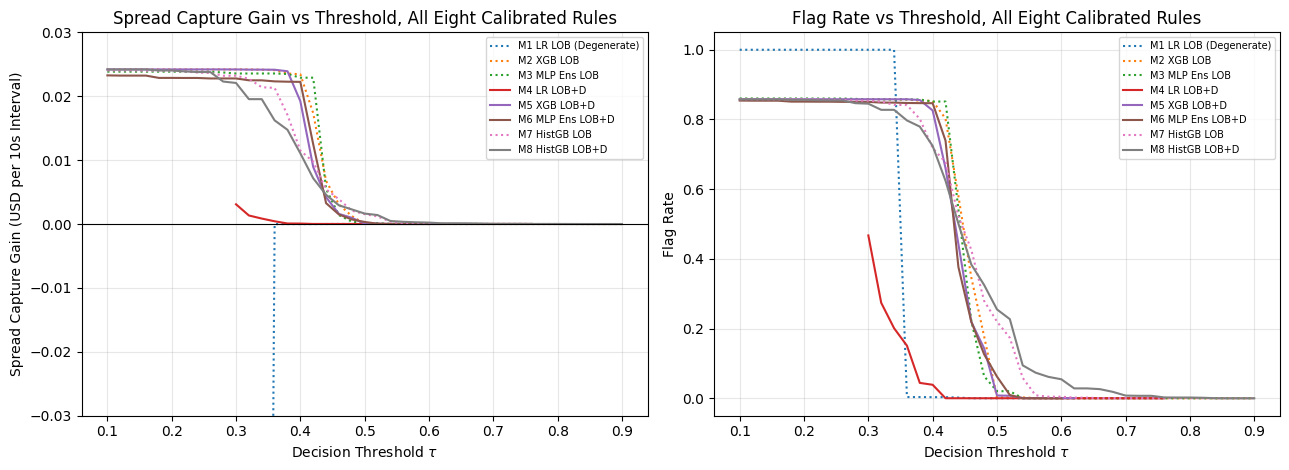

In [28]:
# threshold sweep for all six calibrated rules
taus = np.round(np.arange(0.10, 0.91, 0.02), 2)


def mm_curve(p_iso):
    fl, dc = [], []
    for t in taus:
        s = mm_stats(tr_r, p_iso >= t)
        fl.append(s['flag_rate'] if s else np.nan)
        dc.append(s['d_spr_cap'] if s else np.nan)
    return np.array(fl), np.array(dc)


fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for m in ORDER8:
    fl, dc = mm_curve(P_ISO[m][rb])
    lab = NAME[m] + (' (Degenerate)' if m == 'M1' else '')
    axes[0].plot(taus, dc, color=COLOR[m], ls=LS[m], label=lab)
    axes[1].plot(taus, fl, color=COLOR[m], ls=LS[m], label=lab)
axes[0].axhline(0, color='k', lw=0.8)
axes[0].set_ylim(-0.03, 0.03)
axes[0].set_xlabel(r'Decision Threshold $\tau$')
axes[0].set_ylabel('Spread Capture Gain (USD per 10s Interval)')
axes[0].set_title('Spread Capture Gain vs Threshold, All Eight Calibrated Rules')
axes[1].set_xlabel(r'Decision Threshold $\tau$')
axes[1].set_ylabel('Flag Rate')
axes[1].set_title('Flag Rate vs Threshold, All Eight Calibrated Rules')
for ax in axes:
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'tau_sensitivity.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 14: Economic Translation

This section adapts the useful subset of the stochastic-control market-making literature (Avellaneda and Stoikov, 2008, and the Gueant, Lehalle and Fernandez-Tapia line) to this project's empirical framework. The full control machinery (HJB value functions, optimal quoting surfaces, inventory tilting) does not transfer because this project has no inventory state and no fill-intensity model. Three analyses do transfer.

| Subsection | Borrowed idea | Translation here |
|---|---|---|
| 14.1 | Backtest of the quoting rule | Day-by-day spread-capture improvement of each calibrated rule |
| 14.2 | Risk-sensitive quote widening | Break-even spread premium as a function of calibrated probability |
| 14.3 | Spread response to volatility | Spread, adverse rate and markout by IV quintile (Appendix F) |


### 14.1 Daily backtest of the calibrated rules

For each test day, the spread-capture improvement of each rule over the flag-nothing baseline. This view equal-weights days, while Table 7 pools observations, and the two are different estimands. A rule can earn a larger pooled gain by being more active on benign days. The M2 rule is the consistency champion (positive on roughly 96% of days). The M1 rule is degenerate and shown clipped for completeness.


M1 LR LOB: mean daily gain=-0.27251 USD  hit rate=0%  worst day=-0.47560 USD
M2 XGB LOB: mean daily gain=+0.00352 USD  hit rate=96%  worst day=-0.00343 USD
M3 MLP Ens LOB: mean daily gain=+0.00472 USD  hit rate=93%  worst day=-0.00270 USD
M4 LR LOB+D: mean daily gain=+0.00205 USD  hit rate=28%  worst day=-0.03739 USD
M5 XGB LOB+D: mean daily gain=+0.00543 USD  hit rate=92%  worst day=-0.00560 USD
M6 MLP Ens LOB+D: mean daily gain=+0.00266 USD  hit rate=92%  worst day=-0.00293 USD
M7 HistGB LOB: mean daily gain=+0.00494 USD  hit rate=98%  worst day=-0.00268 USD
M8 HistGB LOB+D: mean daily gain=+0.00450 USD  hit rate=93%  worst day=-0.00495 USD


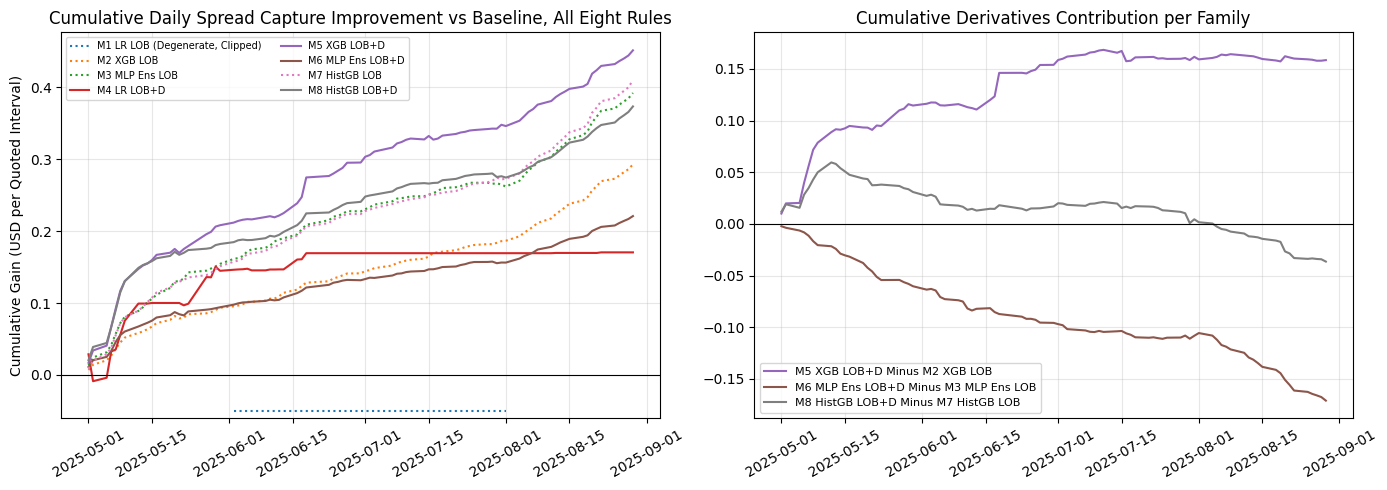

In [29]:
daily_bt = {}
for m in ORDER8:
    flagged = flags_r[m]
    g_all = tr_r.groupby(tr_r['date'].astype(str))['spr_cap'].mean()
    if (~flagged).sum() == 0:
        daily_bt[m] = pd.Series(dtype=float)
        continue
    g_un = tr_r[~flagged].groupby(tr_r['date'].astype(str)[~flagged])['spr_cap'].mean()
    daily_bt[m] = (g_un - g_all).dropna()
    print(f'{NAME[m]}: mean daily gain={daily_bt[m].mean():+.5f} USD  '
          f'hit rate={100 * (daily_bt[m] > 0).mean():.0f}%  '
          f'worst day={daily_bt[m].min():+.5f} USD')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for m in ORDER8:
    if len(daily_bt[m]) == 0:
        continue
    lab = NAME[m]
    series = daily_bt[m].cumsum()
    if m == 'M1':
        lab += ' (Degenerate, Clipped)'
        series = series.clip(lower=-0.05)
    axes[0].plot(pd.to_datetime(daily_bt[m].index), series.values,
                 color=COLOR[m], ls=LS[m], label=lab)
axes[0].axhline(0, color='k', lw=0.8)
axes[0].set_ylim(-0.06, None)
axes[0].set_title('Cumulative Daily Spread Capture Improvement vs Baseline, All Eight Rules')
axes[0].set_ylabel('Cumulative Gain (USD per Quoted Interval)')
axes[0].legend(ncol=2, fontsize=7)
axes[0].grid(alpha=0.3)
for a, b in (('M2', 'M5'), ('M3', 'M6'), ('M7', 'M8')):
    idxu = daily_bt[a].index.union(daily_bt[b].index)
    diff = (daily_bt[b].reindex(idxu).fillna(0) - daily_bt[a].reindex(idxu).fillna(0))
    axes[1].plot(pd.to_datetime(idxu), diff.cumsum().values,
                 color=COLOR[b], label=f'{NAME[b]} Minus {NAME[a]}')
axes[1].axhline(0, color='k', lw=0.8)
axes[1].set_title('Cumulative Derivatives Contribution per Family')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'backtest_cumulative.png'), dpi=150, bbox_inches='tight')
plt.show()

### 14.2 Break-even spread premium (the Avellaneda and Stoikov bridge)

In the Avellaneda and Stoikov objective, the quote distance from mid balances execution probability against expected adverse cost. The model supplies the missing empirical ingredient, the expected adverse cost conditional on the signal. Observations are binned by calibrated probability and the realised adverse cost per bin is expressed as a fraction of the prevailing half-spread, which is the break-even widening factor a quoting rule should apply. The premium rises monotonically across calibrated probability for every model with usable calibration. Quoting at the touch is roughly break-even when the model reads the environment as safe and costs a multiple of the half-spread when it reads it as risky. This mapping from model output to a multiplicative spread adjustment is the most direct quoting prescription the analysis produces.


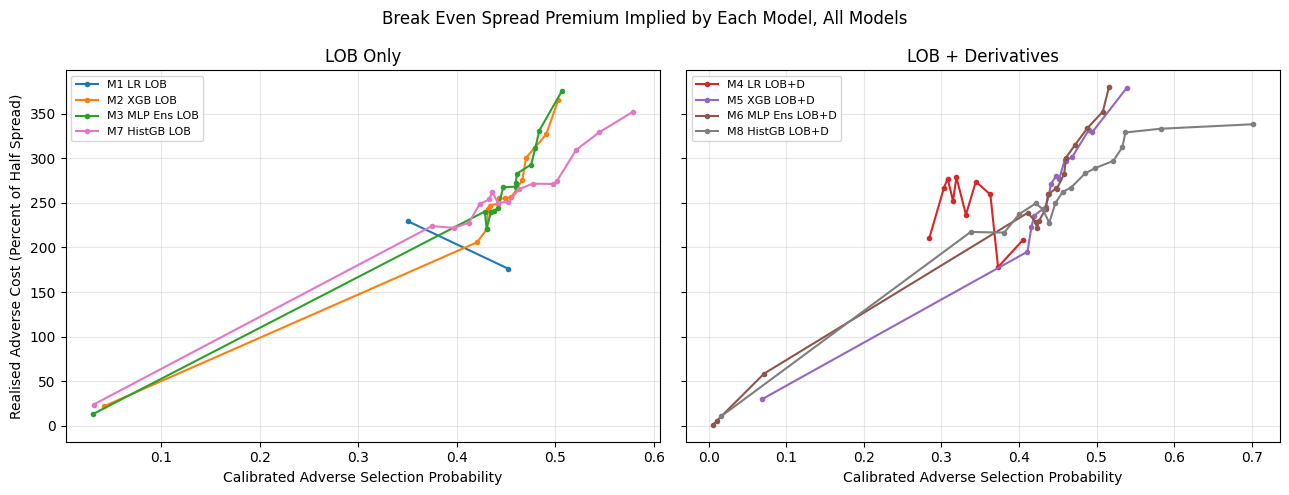

In [30]:
pos_hs = tr_r['half_spread'].values > 0
cost_ratio = (np.clip(tr_r['markout'].values[pos_hs], 0, None)
              / tr_r['half_spread'].values[pos_hs])
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
panels = [('LOB Only', ('M1', 'M2', 'M3', 'M7')),
          ('LOB + Derivatives', ('M4', 'M5', 'M6', 'M8'))]
for ax, (title, group) in zip(axes, panels):
    for m in group:
        p_iso = P_ISO[m][rb][pos_hs]
        bins = pd.qcut(p_iso, 20, labels=False, duplicates='drop')
        xs, ys = [], []
        for b in range(int(bins.max()) + 1):
            msk = bins == b
            xs.append(p_iso[msk].mean())
            ys.append(cost_ratio[msk].mean())
        ax.plot(xs, np.array(ys) * 100, marker='o', ms=3, color=COLOR[m], label=NAME[m])
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_xlabel('Calibrated Adverse Selection Probability')
axes[0].set_ylabel('Realised Adverse Cost (Percent of Half Spread)')
fig.suptitle('Break Even Spread Premium Implied by Each Model, All Models')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'spread_premium_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

### 14.3 Spread and adverse selection by IV quintile (Appendix F)

Adverse selection theory (Glosten and Milgrom, 1985) predicts that quoted spreads widen when informed-trading risk rises. The gradient across IV quintiles grounds the role of the IV level in standard theory. Mean absolute markout rises monotonically with IV and quoted spreads respond in the top quintiles. The adverse-event rate peaks in the middle quintiles because the event is defined relative to the half-spread, and in the top quintile spreads widen faster than prices move, which is the market already pricing the risk.


In [31]:
y_r = y_test_d[rb]
q_iv = pd.qcut(tr_r['iv_atm_30'], 5, labels=False)
rows_iv = []
for qb in range(5):
    msk = (q_iv == qb).values
    rows_iv.append({
        'IV Quintile': qb + 1,
        'Mean IV ATM 30D': tr_r['iv_atm_30'].values[msk].mean(),
        'Mean Spread USD': tr_r['spread'].values[msk].mean(),
        'Adverse Rate': y_r[msk].mean(),
        'Mean Abs Markout Bps': (np.abs(tr_r['markout'].values[msk])
                                 / tr_r['mid'].values[msk]).mean() * 1e4,
    })
print('Appendix F, Spread and Adverse Selection by IV Quintile')
print(pd.DataFrame(rows_iv).set_index('IV Quintile').round(4).to_string())

Appendix F, Spread and Adverse Selection by IV Quintile
             Mean IV ATM 30D  Mean Spread USD  Adverse Rate  Mean Abs Markout Bps
IV Quintile                                                                      
1                     0.1154           0.0223        0.2555                0.3751
2                     0.1297           0.0176        0.4066                0.6447
3                     0.1388           0.0179        0.4374                0.6715
4                     0.1474           0.0235        0.4370                0.8813
5                     0.1795           0.0350        0.4062                1.0008


### 14.4 Section 14 conclusions

1. The calibrated M2 rule is the consistency champion, positive on roughly 96% of test days. The M5 rule earns a higher pooled gain but is less uniform day to day, so a desk deploying the derivatives-aware rule should treat it as a day-level overlay rather than an unconditional upgrade.
2. The model output maps directly into the Avellaneda and Stoikov quoting objective as a multiplicative spread-widening factor that rises monotonically with calibrated probability.
3. The IV channel is confirmed in the cross-section. Absolute markouts rise monotonically with the IV level and quoted spreads respond, grounding the derivatives features in adverse-selection theory even though they carry no incremental intraday signal beyond the order book.
4. Stochastic-control extensions (inventory management, HJB-optimal quoting with the model-implied premium as input) are the natural next research step.


## Section 15: The Validation Layer

The headline numbers in Sections 8 to 14 are the end point of a falsification chain that changed the project's answer twice. This section documents that chain, because the methodological lessons are part of the contribution, and re-runs the two falsification tests that remain informative on the corrected pipeline.

**The chain of evidence, in order.**

1. **The naive result.** The first complete pipeline showed pooled AUC gains from derivatives of +0.008 (LR), +0.021 (XGB) and +0.038 (MLP), all formally significant under paired bootstrap and Diebold-Mariano tests. An apparently clean yes.
2. **The placebo test.** Permuting the day-level derivatives mapping (each day receives another random day's true values, destroying all alignment) and retraining did not remove the gains. Information-free day-constant columns matched or beat the real features on pooled AUC. Mechanism. The test window has large day-to-day base-rate variation, pooled AUC rewards ranking days by base rate, and any day-constant column lets a flexible model do that. Day-constant columns also absorb day effects during training, freeing the LOB features for within-day structure.
3. **Seed fragility.** Single-seed MLP results spanned pooled AUC 0.58 to 0.63 across seeds, and the apparent MLP derivatives gain reversed sign across seeds. Seed ensembling became mandatory (Section 7).
4. **The day-ID control and the scaler bug.** A control experiment (replacing derivatives with an arbitrary day identifier) produced inconsistent numbers and led to the discovery that every evaluation had trained final models on train+val-scaled features but scored them on train-only-scaled matrices. For tree models whose split thresholds live in scaled units this distorts everything. The LOB-only XGBoost moves from pooled AUC 0.529 to 0.636 once evaluation matrices match training matrices. The corrected protocol is the one used throughout this notebook.
5. **The clean answer.** On the corrected pipeline and half-day-cleaned data (Section 19), every non-linear within-day derivatives gain is null or negative, and the LR pooled gain is pure between-day placement.

**Lessons worth standardising.** Consistent scaling between training and evaluation of final models. Pooled versus within-day metrics whenever day-constant features meet day-heterogeneous base rates. Seed ensembling for neural networks. Placebo permutation tests as routine practice.


### 15.1 The placebo test on the corrected pipeline

The placebo is re-run here under the corrected protocol. The derivatives day-mapping is permuted, the XGBoost LOB+Derivatives configuration is retrained from scratch (tuning frozen at the M5 selection for speed), and pooled and within-day AUC are evaluated consistently. Three permutations suffice to show the effect because the permutation variance is tiny.

**Reading the output.** Permuted, information-free derivatives reproduce the real M5's pooled AUC almost exactly, and its within-day AUC too. Real options data and random day-constant noise are indistinguishable to this model class at this horizon, which is precisely the statement that the derivatives features carry no incremental intraday information, and that pooled AUC could never have detected it either way.


In [32]:
# placebo, permute the day-level derivatives mapping and retrain M5's config
rng_pl = np.random.RandomState(7)
deriv_days = test_d['date'].astype(str).unique()
real_m5_pooled = roc_auc_score(y_test_d, P_TE['M5'])
real_m5_within = DAILY['M5'].mean()
print(f'Real M5: pooled={real_m5_pooled:.4f}  within-day={real_m5_within:.4f}\n')

# day-level derivatives table over the combined window
full_d = pd.concat([train_d, val_d, test_d])
day_key = full_d['date'].astype(str)
deriv_by_day = full_d.groupby(day_key.values)[DERIV_FEATURES].first()

for perm in range(3):
    shuffled = deriv_by_day.copy()
    shuffled[:] = deriv_by_day.sample(frac=1.0, random_state=perm).values
    plc = full_d.copy()
    plc[DERIV_FEATURES] = shuffled.reindex(day_key.values).values

    p_tr = plc[plc['date'].astype(str) <= TRAIN_END]
    p_va = plc[(plc['date'].astype(str) >= VAL_START) & (plc['date'].astype(str) <= VAL_END)]
    p_te = plc[plc['date'].astype(str) >= TEST_START]
    p_tv = pd.concat([p_tr, p_va], ignore_index=True)

    sc_tv_p = StandardScaler().fit(p_tv[ALL_FEATURES])
    mp = XGBClassifier(**params5, subsample=0.8, n_estimators=ep5,
                       scale_pos_weight=sp_full, random_state=42, verbosity=0)
    mp.fit(sc_tv_p.transform(p_tv[ALL_FEATURES]), p_tv['y'].values)
    pp = mp.predict_proba(sc_tv_p.transform(p_te[ALL_FEATURES]))[:, 1]
    wd = daily_auc_series(p_te['y'].values, pp).mean()
    print(f'Placebo permutation {perm}: pooled={roc_auc_score(p_te["y"].values, pp):.4f}  '
          f'within-day={wd:.4f}', flush=True)

Real M5: pooled=0.6314  within-day=0.6101

Placebo permutation 0: pooled=0.6317  within-day=0.6097
Placebo permutation 1: pooled=0.6320  within-day=0.6099
Placebo permutation 2: pooled=0.6316  within-day=0.6103


### 15.2 Seed dispersion of the MLPs

The per-seed test AUCs of the ensemble members, and the per-seed derivatives gain. The dispersion across seeds is of the same order as the largest information-set gain ever observed in this project, which is why no single-seed MLP comparison is quotable and the shipped M3/M6 are three-seed averages.


In [33]:
print('Per-seed pooled test AUC and per-seed M3 to M6 gain')
for s, a, b in zip(SEEDS, mlp3_models, mlp6_models):
    p3 = a.predict_proba(X_te_lob_p)[:, 1]
    p6 = b.predict_proba(X_te_full_f)[:, 1]
    auc3, auc6 = roc_auc_score(y_test_d, p3), roc_auc_score(y_test_d, p6)
    w3 = daily_auc_series(y_test_d, p3).mean()
    w6 = daily_auc_series(y_test_d, p6).mean()
    print(f'  seed {s:3d}: M3 {auc3:.4f}/{w3:.4f}   M6 {auc6:.4f}/{w6:.4f}   '
          f'gain pooled {auc6 - auc3:+.4f} within {w6 - w3:+.4f}')

p3e, p6e = P_TE['M3'], P_TE['M6']
print(f'  ensemble: M3 {roc_auc_score(y_test_d, p3e):.4f}/{DAILY["M3"].mean():.4f}   '
      f'M6 {roc_auc_score(y_test_d, p6e):.4f}/{DAILY["M6"].mean():.4f}   '
      f'gain within {(DAILY["M6"] - DAILY["M3"]).dropna().mean():+.4f}')

Per-seed pooled test AUC and per-seed M3 to M6 gain
  seed  42: M3 0.6288/0.6071   M6 0.6291/0.6051   gain pooled +0.0003 within -0.0020
  seed   7: M3 0.6276/0.6060   M6 0.6303/0.6082   gain pooled +0.0027 within +0.0022
  seed 123: M3 0.6286/0.6056   M6 0.6258/0.6016   gain pooled -0.0028 within -0.0040
  ensemble: M3 0.6298/0.6081   M6 0.6304/0.6073   gain within -0.0008


### 15.3 Joint pairwise comparison of all eight models

The joint bootstrap from Section 8 scores every model on the same resample draws, so all 28 pairwise pooled AUC differences have coherent confidence intervals. The matrix below reports the point difference (row minus column) with an asterisk where the 95% CI excludes zero. The boosted and ensembled models form a statistical cluster at the top that the linear models never touch, and within the cluster the LOB-only and derivatives-augmented variants are statistically inseparable or favour the LOB-only model.


In [34]:
matrix = pd.DataFrame(index=[NAME[m] for m in ORDER8],
                      columns=[NAME[m] for m in ORDER8], dtype=object)
for i, a in enumerate(ORDER8):
    for j, b in enumerate(ORDER8):
        if i == j:
            matrix.iloc[i, j] = '.'
            continue
        d = auc_draws[:, i] - auc_draws[:, j]
        lo, hi = np.percentile(d, [2.5, 97.5])
        pt = roc_auc_score(y_test_d, P_TE[a]) - roc_auc_score(y_test_d, P_TE[b])
        star = '*' if lo > 0 or hi < 0 else ' '
        matrix.iloc[i, j] = f'{pt:+.4f}{star}'
print('Pairwise pooled AUC differences (row minus column, * = 95% CI excludes zero)')
print(matrix.to_string())

Pairwise pooled AUC differences (row minus column, * = 95% CI excludes zero)
                 M1 LR LOB M2 XGB LOB M3 MLP Ens LOB M4 LR LOB+D M5 XGB LOB+D M6 MLP Ens LOB+D M7 HistGB LOB M8 HistGB LOB+D
M1 LR LOB                .   -0.1171*       -0.1143*    -0.0367*     -0.1158*         -0.1149*      -0.1179*        -0.1149*
M2 XGB LOB        +0.1171*          .       +0.0028*    +0.0804*     +0.0013*         +0.0022*      -0.0008         +0.0022*
M3 MLP Ens LOB    +0.1143*   -0.0028*              .    +0.0775*     -0.0016*         -0.0007       -0.0036*        -0.0007 
M4 LR LOB+D       +0.0367*   -0.0804*       -0.0775*           .     -0.0791*         -0.0782*      -0.0811*        -0.0782*
M5 XGB LOB+D      +0.1158*   -0.0013*       +0.0016*    +0.0791*            .         +0.0009       -0.0020*        +0.0009 
M6 MLP Ens LOB+D  +0.1149*   -0.0022*       +0.0007     +0.0782*     -0.0009                 .      -0.0029*        -0.0000 
M7 HistGB LOB     +0.1179*   +0.0008        +0.0

### 15.4 Sample definition and activity-conditional evaluation

Two external-review objections are tested here. First, that crossed or abnormally wide quote states could distort labels and tree splits. The headline metrics are recomputed on test subsets excluding non-positive spreads and spreads above 25 cents and above one dollar. Second, and more substantively, that the target convention `y = 0` whenever a bin has no net directional signed flow hands every model a partly mechanical win, predicting *whether a bin will carry net directional signed flow at all* rather than whether an active interval adversely selects. The headline metrics are recomputed on the active-flow subsample (`quote_dir != 0`, about 86% of test rows), and the XGBoost pair is additionally retrained from scratch on active rows only.

**Reading the output.** The spread filters change nothing (99.9% of rows survive and every AUC is identical to three decimals). The activity conditioning is the informative one. Within-day AUC drops from about 0.61 to about 0.52 for every non-linear model, so a large share of the headline discrimination is exposure prediction, identifying the intervals without net directional signed flow that are mechanically safe, rather than direction-conditional adverse-selection ranking. Retraining on active rows does not recover the difference (the conditional problem is genuinely hard at 10 seconds with top-of-book features), and the derivatives gain conditional on activity is significantly negative after retraining. Three consequences. The headline AUC must be described as covering both exposure and conditional adverse selection. The safe-window identification skill is still economically real (the calibrated rules monetise it in Table 7). And the research-question answer is unchanged, since the derivatives null holds unconditionally and conditionally.


In [35]:
# sample-definition robustness from the final predictions
def masked_eval(msk, label):
    print(f'{label}: n={msk.sum():,} ({100 * msk.mean():.1f}%), '
          f'base rate={y_test_d[msk].mean():.3f}')
    rows = {}
    for m in ORDER8:
        dsub = days_te[msk]
        wd = pd.Series({d: roc_auc_score(y_test_d[msk][dsub == d], P_TE[m][msk][dsub == d])
                        for d in np.unique(dsub)
                        if y_test_d[msk][dsub == d].min() != y_test_d[msk][dsub == d].max()})
        rows[m] = (roc_auc_score(y_test_d[msk], P_TE[m][msk]), wd)
        print(f'  {NAME[m]:18s} pooled={rows[m][0]:.4f}  within-day={wd.mean():.4f}')
    diff = (rows['M5'][1] - rows['M2'][1]).dropna()
    lo, hi = boot_mean_ci(diff.values)
    print(f'  M2 to M5 within-day gain: {diff.mean():+.4f} [{lo:+.4f}, {hi:+.4f}]  '
          f'days+={100 * (diff > 0).mean():.0f}%\n')


masked_eval(np.ones(len(test_d), bool), 'Full test sample')
masked_eval(((test_d['spread'] > 0) & (test_d['spread'] <= 0.25)).values,
            'Spread > 0 and <= $0.25')
masked_eval(((test_d['spread'] > 0) & (test_d['spread'] <= 1.00)).values,
            'Spread > 0 and <= $1.00')
masked_eval((test_d['quote_dir'] != 0).values,
            'Active flow only (quote_dir != 0)')


Full test sample: n=193,057 (100.0%), base rate=0.388
  M1 LR LOB          pooled=0.5155  within-day=0.5050
  M2 XGB LOB         pooled=0.6326  within-day=0.6103
  M3 MLP Ens LOB     pooled=0.6298  within-day=0.6081
  M4 LR LOB+D        pooled=0.5523  within-day=0.5059
  M5 XGB LOB+D       pooled=0.6314  within-day=0.6101
  M6 MLP Ens LOB+D   pooled=0.6304  within-day=0.6073
  M7 HistGB LOB      pooled=0.6334  within-day=0.6109
  M8 HistGB LOB+D    pooled=0.6304  within-day=0.6098
  M2 to M5 within-day gain: -0.0002 [-0.0010, +0.0006]  days+=49%

Spread > 0 and <= $0.25: n=192,905 (99.9%), base rate=0.388
  M1 LR LOB          pooled=0.5154  within-day=0.5050
  M2 XGB LOB         pooled=0.6326  within-day=0.6102
  M3 MLP Ens LOB     pooled=0.6298  within-day=0.6081
  M4 LR LOB+D        pooled=0.5523  within-day=0.5058
  M5 XGB LOB+D       pooled=0.6313  within-day=0.6100
  M6 MLP Ens LOB+D   pooled=0.6305  within-day=0.6073
  M7 HistGB LOB      pooled=0.6334  within-day=0.6109
  M8 Hist

In [36]:
# activity-conditional retraining, XGB pair on active rows only
act = lob_target[lob_target['quote_dir'] != 0].dropna(subset=ALL_FEATURES)
tr_a = date_slice(act, TRAIN_START, TRAIN_END)
va_a = date_slice(act, VAL_START, VAL_END)
te_a = date_slice(act, TEST_START, TEST_END)
tv_a = pd.concat([tr_a, va_a], ignore_index=True)
sp_a = float((tr_a['y'] == 0).sum()) / max((tr_a['y'] == 1).sum(), 1)
days_a = te_a['date'].astype(str).values
DA_a = {}
for sname, scols in (('LOB', LOB_FEATURES), ('LOB+D', ALL_FEATURES)):
    sc_tr = StandardScaler().fit(tr_a[scols])
    m = XGBClassifier(max_depth=3, learning_rate=0.05, subsample=0.8,
                      n_estimators=400, scale_pos_weight=sp_a, eval_metric='auc',
                      early_stopping_rounds=30, random_state=42, verbosity=0)
    m.fit(sc_tr.transform(tr_a[scols]), tr_a['y'].values,
          eval_set=[(sc_tr.transform(va_a[scols]), va_a['y'].values)], verbose=False)
    it = max(m.best_iteration, 1)
    sc_tv = StandardScaler().fit(tv_a[scols])
    mf = XGBClassifier(max_depth=3, learning_rate=0.05, subsample=0.8,
                       n_estimators=it, scale_pos_weight=sp_a, random_state=42, verbosity=0)
    mf.fit(sc_tv.transform(tv_a[scols]), tv_a['y'].values)
    p = mf.predict_proba(sc_tv.transform(te_a[scols]))[:, 1]
    DA_a[sname] = pd.Series({d: roc_auc_score(te_a['y'].values[days_a == d], p[days_a == d])
                             for d in np.unique(days_a)
                             if te_a['y'].values[days_a == d].min() != te_a['y'].values[days_a == d].max()})
    print(f'active-retrained {sname:6s}: pooled={roc_auc_score(te_a["y"].values, p):.4f}  '
          f'within-day={DA_a[sname].mean():.4f}  (trees={it}, n_test={len(te_a):,})', flush=True)
diff_a = (DA_a['LOB+D'] - DA_a['LOB']).dropna()
lo, hi = boot_mean_ci(diff_a.values)
print(f'active-retrained derivatives gain: {diff_a.mean():+.4f} [{lo:+.4f}, {hi:+.4f}]  '
      f'days+={100 * (diff_a > 0).mean():.0f}%')


active-retrained LOB   : pooled=0.5223  within-day=0.5215  (trees=135, n_test=165,699)
active-retrained LOB+D : pooled=0.5178  within-day=0.5188  (trees=45, n_test=165,699)
active-retrained derivatives gain: -0.0027 [-0.0041, -0.0013]  days+=34%


### 15.5 Label-threshold robustness

The committed target multiplier (0.5 times the half-spread) defines an early adverse-selection indicator. Here the target is rebuilt at the break-even multiplier (1.0) and the severe multiplier (2.0), and the XGBoost pair is retrained per threshold under the standard protocol.

**Reading the output.** At the break-even threshold the derivatives gain stays statistically zero. At the severe threshold it turns marginally positive (about +0.002 within-day with the CI excluding zero), consistent with severe adverse moves being more volatility-regime-driven and hence marginally more visible to a day-level IV anchor. The effect is economically negligible at one fifth of a percent of AUC, so the headline null is robust to the label definition.


In [37]:
# label-threshold robustness, XGB pair retrained at tau_label = 1.0 and 2.0
for tau_label in (1.0, 2.0):
    fr_t = build_target(lob, tau=tau_label).dropna(subset=ALL_FEATURES)
    tr_t = date_slice(fr_t, TRAIN_START, TRAIN_END)
    va_t = date_slice(fr_t, VAL_START, VAL_END)
    te_t = date_slice(fr_t, TEST_START, TEST_END)
    tv_t = pd.concat([tr_t, va_t], ignore_index=True)
    sp_t = float((tr_t['y'] == 0).sum()) / max((tr_t['y'] == 1).sum(), 1)
    days_t = te_t['date'].astype(str).values
    DA_t = {}
    for sname, scols in (('LOB', LOB_FEATURES), ('LOB+D', ALL_FEATURES)):
        sc_tr = StandardScaler().fit(tr_t[scols])
        m = XGBClassifier(max_depth=3, learning_rate=0.05, subsample=0.8,
                          n_estimators=400, scale_pos_weight=sp_t, eval_metric='auc',
                          early_stopping_rounds=30, random_state=42, verbosity=0)
        m.fit(sc_tr.transform(tr_t[scols]), tr_t['y'].values,
              eval_set=[(sc_tr.transform(va_t[scols]), va_t['y'].values)], verbose=False)
        it = max(m.best_iteration, 1)
        sc_tv = StandardScaler().fit(tv_t[scols])
        mf = XGBClassifier(max_depth=3, learning_rate=0.05, subsample=0.8,
                           n_estimators=it, scale_pos_weight=sp_t, random_state=42, verbosity=0)
        mf.fit(sc_tv.transform(tv_t[scols]), tv_t['y'].values)
        p = mf.predict_proba(sc_tv.transform(te_t[scols]))[:, 1]
        DA_t[sname] = pd.Series({d: roc_auc_score(te_t['y'].values[days_t == d], p[days_t == d])
                                 for d in np.unique(days_t)
                                 if te_t['y'].values[days_t == d].min() != te_t['y'].values[days_t == d].max()})
        print(f'tau_label={tau_label}: {sname:6s} pooled={roc_auc_score(te_t["y"].values, p):.4f}  '
              f'within-day={DA_t[sname].mean():.4f}  (base rate {te_t["y"].mean():.3f})', flush=True)
    diff_t = (DA_t['LOB+D'] - DA_t['LOB']).dropna()
    lo, hi = boot_mean_ci(diff_t.values)
    print(f'tau_label={tau_label}: within-day derivatives gain {diff_t.mean():+.4f} '
          f'[{lo:+.4f}, {hi:+.4f}]  days+={100 * (diff_t > 0).mean():.0f}%\n', flush=True)


tau_label=1.0: LOB    pooled=0.6337  within-day=0.6118  (base rate 0.365)
tau_label=1.0: LOB+D  pooled=0.6317  within-day=0.6124  (base rate 0.365)
tau_label=1.0: within-day derivatives gain +0.0006 [-0.0003, +0.0015]  days+=59%

tau_label=2.0: LOB    pooled=0.6545  within-day=0.6264  (base rate 0.313)
tau_label=2.0: LOB+D  pooled=0.6514  within-day=0.6284  (base rate 0.313)
tau_label=2.0: within-day derivatives gain +0.0019 [+0.0009, +0.0031]  days+=59%



## Section 16: Final Corrected Results

**Headline numbers (primary test window 2025-05-01 to 2025-08-29, half-day-cleaned data, consistent scaling).** The cell below reproduces them from the saved prediction file, so any reader can verify the tables without retraining.

| Model | Pooled AUC | Within-Day AUC |
|---|---|---|
| M1 LR LOB | 0.5155 | 0.5050 |
| M2 XGB LOB | 0.6326 | 0.6103 |
| M3 MLP Ens LOB | 0.6298 | 0.6081 |
| M4 LR LOB+D | 0.5523 | 0.5059 |
| M5 XGB LOB+D | 0.6314 | 0.6101 |
| M6 MLP Ens LOB+D | 0.6304 | 0.6073 |
| M7 HistGB LOB | 0.6334 | 0.6109 |
| M8 HistGB LOB+D | 0.6304 | 0.6098 |

**The answer at the locked 10-second horizon.**

*Intraday signal. No.* Every non-linear information-set gain is null or negative, pooled and within-day (M2 to M5 within-day -0.0002 with CI [-0.0010, +0.0006] and 49% of days positive, a textbook null). The LR pooled gain (+0.0367) is entirely between-day placement, its within-day gain is +0.0008 and not significant. SHAP attributes about 4% of M5's output to all six derivatives features combined.

*Day-level placement. Yes, narrowly.* The calibrated XGBoost decision rule earns +0.0022 USD per candidate 10-second interval from derivatives, in spread-capture proxy units before fill, queue, inventory, fee, rebate, hedging and latency effects, with the day-block CI excluding zero and probability one across draws. The MLP rule shows the opposite sign, so the economic value is engine-specific. Section 17 identifies the mechanism. EOD derivatives improve next-day adverse-selection forecasts out of sample in point terms, though Section 17.2 shows that forecast-level improvement is statistically suggestive rather than conclusive on 208 evaluation days, so the decision-layer CIs carry the inferential weight of the day-level claim.

*Out of sample (September to December 2025, LOB only).* The non-linear LOB models generalise strongly (pooled AUC about 0.73), confirming the engine itself is sound and the test-window numbers are not overfit to the tariff-shock regime.


In [38]:
# verification cell, reproduce the headline numbers from saved predictions
final_preds = pd.read_parquet(os.path.join(PROC_DIR, 'preds_test_final.parquet'))
y16 = final_preds['y'].values
d16 = final_preds['date'].astype(str).values
ud16 = np.unique(d16)
idx16 = {d: np.where(d16 == d)[0] for d in ud16}


def within_day_auc16(p):
    vals = [roc_auc_score(y16[idx16[d]], p[idx16[d]]) for d in ud16
            if y16[idx16[d]].min() != y16[idx16[d]].max()]
    return np.mean(vals)


print('Verification from preds_test_final.parquet')
print(f'{"Model":18s} {"Pooled":>8s} {"Within-Day":>11s}')
for m in ORDER8:
    p = final_preds[f'p_{m}_raw'].values
    print(f'{NAME[m]:18s} {roc_auc_score(y16, p):8.4f} {within_day_auc16(p):11.4f}')

print('\nInformation-set gains (pooled / within-day)')
for a, b in PAIRS:
    pa, pb = final_preds[f'p_{a}_raw'].values, final_preds[f'p_{b}_raw'].values
    print(f'  {a} to {b}: {roc_auc_score(y16, pb) - roc_auc_score(y16, pa):+.4f} / '
          f'{within_day_auc16(pb) - within_day_auc16(pa):+.4f}')

Verification from preds_test_final.parquet
Model                Pooled  Within-Day
M1 LR LOB            0.5155      0.5050
M2 XGB LOB           0.6326      0.6103
M3 MLP Ens LOB       0.6298      0.6081
M4 LR LOB+D          0.5523      0.5059
M5 XGB LOB+D         0.6314      0.6101
M6 MLP Ens LOB+D     0.6304      0.6073
M7 HistGB LOB        0.6334      0.6109
M8 HistGB LOB+D      0.6304      0.6098

Information-set gains (pooled / within-day)
  M1 to M4: +0.0367 / +0.0008
  M2 to M5: -0.0013 / -0.0002
  M3 to M6: +0.0007 / -0.0008
  M7 to M8: -0.0029 / -0.0011


## Section 17: The Fair Shot

Before accepting the 10-second null, derivatives information gets its best literature-motivated shot along the dimensions the locked design had not tested.

**Dimension 1, option flow and positioning.** The options-information literature locates the signal in trading activity rather than surface shape, citing option volume (Pan and Poteshman, 2006, Easley, O'Hara and Srinivas, 1998), put-call parity deviations (Cremers and Weinbaum, 2010) and relative option activity (Johnson and So, 2012). Five daily features are built from `opprcd`, namely the open-interest-weighted Cremers and Weinbaum call-minus-put IV spread over matched strike and expiry pairs, the put-call volume ratio, log total SPX option volume, the 0DTE volume share (the defining feature of the modern regime, averaging about half of SPX volume in this sample), and the day-over-day change in log open interest.

**Dimension 2, horizon.** End-of-day information should matter more as the prediction horizon approaches the daily scale. The adverse-selection target is rebuilt at 10 seconds, 1 minute, 5 minutes and 30 minutes, and XGBoost is retrained per horizon under three feature sets, LOB only, LOB plus the six surface features, and LOB plus all eleven derivatives features.

**Dimension 3, the day level itself.** Next-day adverse-selection rate and next-day realised volatility are forecast from EOD predictors with expanding-window out-of-sample evaluation, the natural home of options information per the volatility-forecasting literature. The desk-relevant control is whether lagged day aggregates of the desk's own LOB data forecast just as well, in which case the feed would be redundant even at the day level.


In [39]:
# extended option-flow features from opprcd (resume-safe, loads if already built)
EXT_PATH = os.path.join(OM_PROC, 'deriv_features_extended.parquet')
DERIV_EXT = ['cw_spread', 'pc_vol_ratio', 'log_opt_vol', 'dte0_share', 'd_log_oi']
DERIV11 = DERIV_FEATURES + DERIV_EXT

if os.path.exists(EXT_PATH):
    deriv_all_ext = pd.read_parquet(EXT_PATH)
    deriv_all_ext.index = deriv_all_ext.index.astype(str)
    print(f'Loaded extended features: {deriv_all_ext.shape}')
else:
    cols17 = ['secid', 'date', 'exdate', 'cp_flag', 'strike_price', 'volume',
              'open_interest', 'impl_volatility', 'delta', 'best_bid']
    op17 = pd.concat([
        pd.read_parquet(os.path.join(OM_DIR, 'opprcd2024.parquet'), columns=cols17),
        pd.read_parquet(os.path.join(OM_DIR, 'opprcd2025.parquet'), columns=cols17),
    ], ignore_index=True)
    op17 = op17[op17['secid'] == SPX_SECID].copy()
    op17['date'] = pd.to_datetime(op17['date']).dt.date.astype(str)
    op17['exdate'] = pd.to_datetime(op17['exdate']).dt.date.astype(str)

    g17 = op17.groupby('date')
    vol_tot = g17['volume'].sum()
    vol_put = op17[op17['cp_flag'] == 'P'].groupby('date')['volume'].sum()
    vol_call = op17[op17['cp_flag'] == 'C'].groupby('date')['volume'].sum()
    oi_tot = g17['open_interest'].sum()
    dte0 = op17[op17['exdate'] == op17['date']].groupby('date')['volume'].sum()
    ext = pd.DataFrame({
        'log_opt_vol': np.log(vol_tot.clip(lower=1)),
        'pc_vol_ratio': (vol_put / vol_call.clip(lower=1)).clip(0, 5),
        'dte0_share': (dte0 / vol_tot.clip(lower=1)).fillna(0.0),
        'd_log_oi': np.log(oi_tot.clip(lower=1)).diff(),
    })
    liq = op17[(op17['impl_volatility'].notna()) & (op17['best_bid'] > 0)
               & (op17['delta'].abs().between(0.20, 0.80))]
    calls = liq[liq['cp_flag'] == 'C'][['date', 'exdate', 'strike_price',
                                        'impl_volatility', 'open_interest']]
    puts = liq[liq['cp_flag'] == 'P'][['date', 'exdate', 'strike_price',
                                       'impl_volatility', 'open_interest']]
    pairs17 = calls.merge(puts, on=['date', 'exdate', 'strike_price'], suffixes=('_c', '_p'))
    pairs17['w'] = (pairs17['open_interest_c'] + pairs17['open_interest_p']).clip(lower=1)
    pairs17['ivdiff_w'] = (pairs17['impl_volatility_c'] - pairs17['impl_volatility_p']) * pairs17['w']
    ext['cw_spread'] = pairs17.groupby('date').apply(lambda d: d['ivdiff_w'].sum() / d['w'].sum())
    ext = ext.dropna()
    deriv6_17 = pd.read_parquet(os.path.join(OM_PROC, 'deriv_features.parquet'))
    deriv6_17.index = deriv6_17.index.astype(str)
    deriv_all_ext = deriv6_17.join(ext, how='inner')
    deriv_all_ext.to_parquet(EXT_PATH)
    print(f'Built and saved extended features: {deriv_all_ext.shape}')

print(f'0DTE share of SPX volume, sample mean: {deriv_all_ext["dte0_share"].mean():.2f}')
print(deriv_all_ext[DERIV_EXT].describe().round(4).to_string())

Loaded extended features: (415, 11)
0DTE share of SPX volume, sample mean: 0.53
       cw_spread  pc_vol_ratio  log_opt_vol  dte0_share  d_log_oi
count   415.0000      415.0000     415.0000    415.0000  415.0000
mean      0.0022        1.3184      14.9967      0.5268    0.0004
std       0.0059        0.1406       0.1684      0.0705    0.0378
min      -0.0135        1.0381      14.5316      0.2647   -0.3006
25%      -0.0017        1.2337      14.8793      0.4785    0.0015
50%       0.0019        1.3126      14.9890      0.5203    0.0096
75%       0.0063        1.3859      15.1168      0.5740    0.0140
max       0.0490        2.7114      15.6108      0.6902    0.0346


In [40]:
# horizon sweep, XGBoost per horizon and feature set, consistent scaling
sweep = lob.copy()
sweep['date_str'] = sweep['date'].astype(str)
sweep['om_date'] = sweep['date_str'].map(om_lookup)
sweep = sweep.join(deriv_all_ext[DERIV_EXT].rename_axis('om_date'), on='om_date', how='left')
sweep = sweep.drop(columns=['om_date'])
sweep['quote_dir'] = np.sign(sweep['signed_flow'])

HORIZONS17 = [(1, '10s'), (6, '1m'), (30, '5m'), (180, '30m')]
FEATSETS17 = [('LOB', LOB_FEATURES),
              ('LOB+D6', LOB_FEATURES + DERIV_FEATURES),
              ('LOB+D11', LOB_FEATURES + DERIV11)]


def slice_ds(df, s, e):
    return df[(df['date_str'] >= s) & (df['date_str'] <= e)]


def fit_xgb_consistent(train_f, val_f, tv_f, test_f, cols, spw):
    sc_tr = StandardScaler().fit(train_f[cols])
    m = XGBClassifier(max_depth=3, learning_rate=0.05, subsample=0.8,
                      n_estimators=400, scale_pos_weight=spw, eval_metric='auc',
                      early_stopping_rounds=30, random_state=42, verbosity=0)
    m.fit(sc_tr.transform(train_f[cols]), train_f['y'].values,
          eval_set=[(sc_tr.transform(val_f[cols]), val_f['y'].values)], verbose=False)
    best_it = max(m.best_iteration, 1)
    sc_tv = StandardScaler().fit(tv_f[cols])
    mf = XGBClassifier(max_depth=3, learning_rate=0.05, subsample=0.8,
                       n_estimators=best_it, scale_pos_weight=spw,
                       random_state=42, verbosity=0)
    mf.fit(sc_tv.transform(tv_f[cols]), tv_f['y'].values)
    return mf.predict_proba(sc_tv.transform(test_f[cols]))[:, 1], best_it


def daily_auc_generic(y, p, days):
    out = {}
    for d in np.unique(days):
        msk = days == d
        if y[msk].min() == y[msk].max():
            continue
        out[d] = roc_auc_score(y[msk], p[msk])
    return pd.Series(out)


def gain_ci(diff_series, seed=42):
    diff = diff_series.dropna().values
    rng_g = np.random.RandomState(seed)
    means = np.array([diff[rng_g.randint(0, len(diff), len(diff))].mean()
                      for _ in range(2000)])
    lo, hi = np.percentile(means, [2.5, 97.5])
    return diff.mean(), lo, hi, (diff > 0).mean()


HG = {}
for h, hname in HORIZONS17:
    print(f'\nHorizon {hname} (h={h} steps)', flush=True)
    fr = sweep.copy()
    fr['mid_h'] = fr.groupby('date_str')['mid'].shift(-h)
    fr['y'] = np.where(
        fr['quote_dir'] != 0,
        ((fr['mid_h'] - fr['mid']) * fr['quote_dir'] >= 0.5 * fr['half_spread']).astype(int), 0)
    fr = fr.dropna(subset=['mid_h'] + DERIV11)
    tr_f, va_f = slice_ds(fr, TRAIN_START, TRAIN_END), slice_ds(fr, VAL_START, VAL_END)
    te_f = slice_ds(fr, TEST_START, TEST_END)
    tv_f = pd.concat([tr_f, va_f], ignore_index=True)
    spw = float((tr_f['y'] == 0).sum()) / max((tr_f['y'] == 1).sum(), 1)
    days17 = te_f['date_str'].values
    DA17 = {}
    for sname, scols in FEATSETS17:
        p, it = fit_xgb_consistent(tr_f, va_f, tv_f, te_f, scols, spw)
        DA17[sname] = daily_auc_generic(te_f['y'].values, p, days17)
        print(f'  {sname:8s}: pooled={roc_auc_score(te_f["y"].values, p):.4f}  '
              f'within-day={DA17[sname].mean():.4f}  (trees={it})', flush=True)
    HG[hname] = {}
    for sname in ('LOB+D6', 'LOB+D11'):
        m_, lo, hi, frac = gain_ci(DA17[sname] - DA17['LOB'])
        HG[hname][sname] = (m_, lo, hi)
        print(f'  within-day gain {sname} vs LOB: {m_:+.4f}  [{lo:+.4f}, {hi:+.4f}]  '
              f'days+={100 * frac:.0f}%', flush=True)


Horizon 10s (h=1 steps)
  LOB     : pooled=0.6328  within-day=0.6103  (trees=154)
  LOB+D6  : pooled=0.6309  within-day=0.6098  (trees=112)
  LOB+D11 : pooled=0.6310  within-day=0.6095  (trees=106)
  within-day gain LOB+D6 vs LOB: -0.0006  [-0.0015, +0.0003]  days+=47%
  within-day gain LOB+D11 vs LOB: -0.0008  [-0.0018, +0.0000]  days+=47%

Horizon 1m (h=6 steps)
  LOB     : pooled=0.6336  within-day=0.6096  (trees=21)
  LOB+D6  : pooled=0.6336  within-day=0.6100  (trees=28)
  LOB+D11 : pooled=0.6337  within-day=0.6115  (trees=106)
  within-day gain LOB+D6 vs LOB: +0.0004  [-0.0002, +0.0009]  days+=52%
  within-day gain LOB+D11 vs LOB: +0.0018  [+0.0004, +0.0034]  days+=59%

Horizon 5m (h=30 steps)
  LOB     : pooled=0.6431  within-day=0.6175  (trees=56)
  LOB+D6  : pooled=0.6462  within-day=0.6204  (trees=12)
  LOB+D11 : pooled=0.6420  within-day=0.6145  (trees=11)
  within-day gain LOB+D6 vs LOB: +0.0029  [+0.0000, +0.0059]  days+=53%
  within-day gain LOB+D11 vs LOB: -0.0030  [-0.

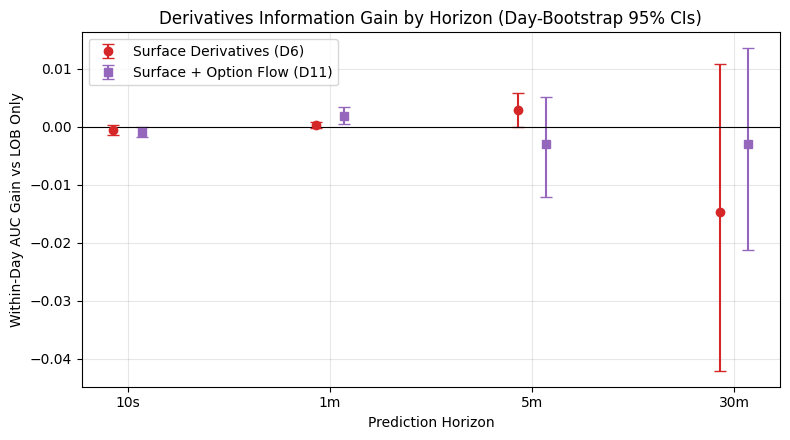

In [41]:
# the horizon story as a picture
hor_names = [hn for _, hn in HORIZONS17]
x17 = np.arange(len(hor_names))
fig, ax = plt.subplots(figsize=(8, 4.5))
for sname, off, c, mk, lab in (('LOB+D6', -0.07, 'tab:red', 'o', 'Surface Derivatives (D6)'),
                               ('LOB+D11', 0.07, 'tab:purple', 's', 'Surface + Option Flow (D11)')):
    vals = [HG[hn][sname][0] for hn in hor_names]
    los = [HG[hn][sname][1] for hn in hor_names]
    his = [HG[hn][sname][2] for hn in hor_names]
    ax.errorbar(x17 + off, vals,
                yerr=[np.array(vals) - np.array(los), np.array(his) - np.array(vals)],
                fmt=mk, color=c, capsize=4, label=lab)
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(x17)
ax.set_xticklabels(hor_names)
ax.set_xlabel('Prediction Horizon')
ax.set_ylabel('Within-Day AUC Gain vs LOB Only')
ax.set_title('Derivatives Information Gain by Horizon (Day-Bootstrap 95% CIs)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'horizon_gains.png'), dpi=150, bbox_inches='tight')
plt.show()

In [42]:
# day-level forecasting, expanding-window out-of-sample
from sklearn.linear_model import LinearRegression

fr1 = sweep.copy()
fr1['mid_h'] = fr1.groupby('date_str')['mid'].shift(-1)
fr1['y'] = np.where(
    fr1['quote_dir'] != 0,
    ((fr1['mid_h'] - fr1['mid']) * fr1['quote_dir'] >= 0.5 * fr1['half_spread']).astype(int), 0)
fr1 = fr1.dropna(subset=['mid_h'])
day_stats = fr1.groupby('date_str').agg(
    adv_rate=('y', 'mean'),
    d_spread=('spread', 'mean'),
    d_depth=('depth', 'mean'),
    d_absflow=('signed_flow', lambda s: s.abs().mean()),
)
day_stats['rv_bps'] = fr1.groupby('date_str')['mid'].apply(lambda s: s.pct_change().std() * 1e4)

deriv_for_day = fr1.groupby('date_str')[DERIV11].first()
lob_lag = day_stats[['d_spread', 'd_depth', 'd_absflow', 'rv_bps']].shift(1)
lob_lag.columns = ['lag_' + c for c in lob_lag.columns]
X_day_all = deriv_for_day.join(lob_lag).dropna()
Y_day_all = day_stats.loc[X_day_all.index, ['adv_rate', 'rv_bps']]
print(f'days: {len(X_day_all)} (expanding OOS from day 200)')


def oos_r2(X, y, start=200):
    preds, actual = [], []
    for i in range(start, len(X)):
        reg = LinearRegression().fit(X.iloc[:i], y.iloc[:i])
        preds.append(reg.predict(X.iloc[i:i + 1])[0])
        actual.append(y.iloc[i])
    preds, actual = np.array(preds), np.array(actual)
    base = y.iloc[:start].mean()
    return 1 - ((actual - preds) ** 2).sum() / ((actual - base) ** 2).sum()


lag_cols = [c for c in X_day_all.columns if c.startswith('lag_')]
SETS_DAY = {
    'LOB day lags only': lag_cols,
    'Surface derivatives (6)': DERIV_FEATURES,
    'Extended derivatives (5)': DERIV_EXT,
    'All derivatives (11)': DERIV11,
    'LOB lags + all derivatives': DERIV11 + lag_cols,
}
for target in ('adv_rate', 'rv_bps'):
    print(f'\nTarget: next-day {target}')
    for sname, scols in SETS_DAY.items():
        print(f'  {sname:28s}: OOS R2 = {oos_r2(X_day_all[scols], Y_day_all[target]):+.3f}')

days: 408 (expanding OOS from day 200)

Target: next-day adv_rate
  LOB day lags only           : OOS R2 = +0.336
  Surface derivatives (6)     : OOS R2 = +0.178
  Extended derivatives (5)    : OOS R2 = +0.073
  All derivatives (11)        : OOS R2 = +0.214
  LOB lags + all derivatives  : OOS R2 = +0.475

Target: next-day rv_bps
  LOB day lags only           : OOS R2 = +0.597
  Surface derivatives (6)     : OOS R2 = +0.530
  Extended derivatives (5)    : OOS R2 = +0.252
  All derivatives (11)        : OOS R2 = +0.544
  LOB lags + all derivatives  : OOS R2 = +0.565


### 17.1 Fair-shot results

**Option flow at 10 seconds. Nothing.** The eleven-feature set behaves like the six-feature set, the within-day gain stays statistically zero. The Pan and Poteshman flow channel does not rescue the intraday case.

**Horizon sweep. No stable intraday increment at any tested horizon.** The within-day gains shift around zero with CIs that either include zero or are economically negligible. The only estimates whose CIs exclude zero are tiny (D11 at one minute) or borderline (D6 at five minutes), and they do not replicate across the adjacent feature set, which is the signature of noise, not signal.

**Day level. The meaningful case, with a sharp division of labour.** For next-day realised volatility the desk's own lagged LOB day aggregates are the best forecaster and derivatives add nothing. For next-day adverse-selection conditions, the thing the desk actually needs for threshold placement, derivatives add clear incremental out-of-sample power beyond the desk's own history (roughly 0.34 to 0.48 OOS R-squared when added to the LOB lags). This is the mechanism behind the Table 7 decision-layer gain and the narrow, defensible business case for the feed.


### 17.2 Inference on the day-level gain

The point improvement in next-day adverse-rate forecasting (OOS R-squared roughly 0.34 with the desk's own day lags alone, roughly 0.47 adding the derivatives) is the basis of the day-level claim, so it deserves the same inferential discipline as the intraday null. The gain is checked three ways, with a Diebold-Mariano test on the daily squared forecast errors (Newey-West, 5 lags), a moving-block bootstrap of the mean squared-error improvement (block length 10 days), and a leave-group-out attribution identifying which feature group carries the gain. The cumulative squared-error improvement path shows where in the evaluation window the gain accrues.

A ridge-regularised version of the same expanding forecast (RidgeCV over a wide penalty grid) is run alongside as an overfitting control, since 15 predictors on an expanding window starting at 200 days leaves room for plain least squares to chase noise.

**Reading the output.** The attribution is clean. Dropping the six surface features removes essentially the whole gain, while dropping the five option-flow features actually improves the forecast, so the day-level value lives in the surface, consistent with every other section. On 208 evaluation days the DM statistic is +1.59 (p = 0.111) and the block-bootstrap CI narrowly includes zero, because the improvement concentrates in a handful of stress transitions. The honest statement is that the day-level forecasting gain is economically meaningful in point terms but statistically suggestive rather than conclusive at this sample size. The decision-layer translation (Table 7), which aggregates the same information economically, is the channel whose CIs exclude zero.


OOS R2, next-day adverse rate: LOB lags +0.336   LOB lags + derivatives +0.475
DM on squared day-level forecast errors (NW lag 5): +1.59  p=0.111
Block-bootstrap (L=10) mean squared-error improvement: 0.001030 [-0.000053, 0.002682]

Leave-group-out attribution (OOS R2 of the full set minus a group)
  drop none (full set)           : OOS R2 = +0.475
  drop surface derivatives (6)   : OOS R2 = +0.333
  drop option flow (5)           : OOS R2 = +0.489
  drop all derivatives (11)      : OOS R2 = +0.336
  drop LOB day lags              : OOS R2 = +0.214


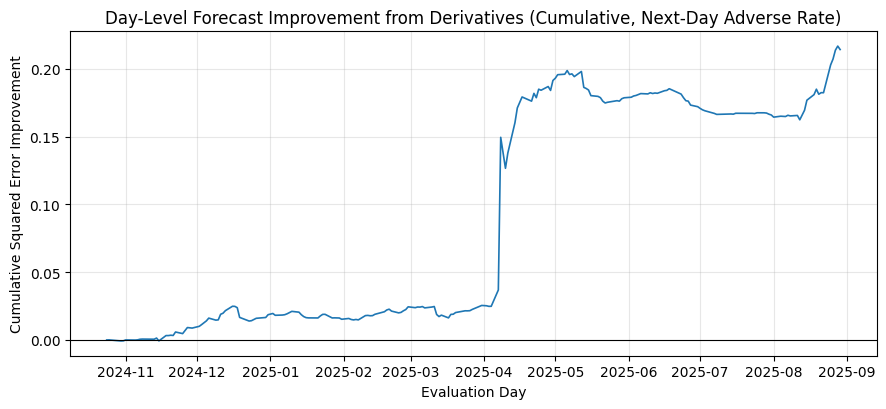

In [ ]:
# inference on the day-level forecasting gain
Y_adv = Y_day_all['adv_rate']

def expanding_errors(cols, start=200):
    errs, dates_ = [], []
    for i in range(start, len(X_day_all)):
        reg = LinearRegression().fit(X_day_all[cols].iloc[:i], Y_adv.iloc[:i])
        errs.append(Y_adv.iloc[i] - reg.predict(X_day_all[cols].iloc[i:i + 1])[0])
        dates_.append(X_day_all.index[i])
    return pd.Series(errs, index=dates_)

e_lob = expanding_errors(lag_cols)
e_all = expanding_errors(lag_cols + DERIV11)
base_mean = Y_adv.iloc[:200].mean()
denom = ((Y_adv.iloc[200:].values - base_mean) ** 2).sum()
print(f'OOS R2, next-day adverse rate: LOB lags {1 - (e_lob ** 2).sum() / denom:+.3f}   '
      f'LOB lags + derivatives {1 - (e_all ** 2).sum() / denom:+.3f}')

d_se = e_lob.values ** 2 - e_all.values ** 2
dbar, n_d = d_se.mean(), len(d_se)
dc = d_se - dbar
s_var = (dc ** 2).mean()
for l in range(1, 6):
    s_var += 2 * (1 - l / 6) * (dc[l:] * dc[:-l]).mean()
dm_day = dbar / np.sqrt(s_var / n_d)
print(f'DM on squared day-level forecast errors (NW lag 5): {dm_day:+.2f}  '
      f'p={2 * (1 - sps.norm.cdf(abs(dm_day))):.3f}')

rng_d = np.random.RandomState(42)
L = 10
boots = []
for _ in range(2000):
    starts = rng_d.randint(0, n_d - L + 1, int(np.ceil(n_d / L)))
    idx = np.concatenate([np.arange(s_, s_ + L) for s_ in starts])[:n_d]
    boots.append(d_se[idx].mean())
lo, hi = np.percentile(boots, [2.5, 97.5])
print(f'Block-bootstrap (L=10) mean squared-error improvement: {dbar:.6f} [{lo:.6f}, {hi:.6f}]')

print('\nLeave-group-out attribution (OOS R2 of the full set minus a group)')
full_cols = lag_cols + DERIV11
for gname, drop in (('none (full set)', []), ('surface derivatives (6)', DERIV_FEATURES),
                    ('option flow (5)', DERIV_EXT), ('all derivatives (11)', DERIV11),
                    ('LOB day lags', lag_cols)):
    cols_g = [c for c in full_cols if c not in drop]
    e_g = expanding_errors(cols_g)
    print(f'  drop {gname:26s}: OOS R2 = {1 - (e_g ** 2).sum() / denom:+.3f}')

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(pd.to_datetime(e_lob.index), np.cumsum(d_se), color='tab:blue', lw=1.2)
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('Evaluation Day')
ax.set_ylabel('Cumulative Squared Error Improvement')
ax.set_title('Day-Level Forecast Improvement from Derivatives (Cumulative, Next-Day Adverse Rate)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'day_level_value.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ridge control for the day-level forecast (overfitting check)
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-4, 4, 25)

def ridge_oos_r2(cols, start=200):
    preds, actual = [], []
    for i in range(start, len(X_day_all)):
        reg = RidgeCV(alphas=alphas).fit(X_day_all[cols].iloc[:i], Y_adv.iloc[:i])
        preds.append(reg.predict(X_day_all[cols].iloc[i:i + 1])[0])
        actual.append(Y_adv.iloc[i])
    preds, actual = np.array(preds), np.array(actual)
    return 1 - ((actual - preds) ** 2).sum() / denom


print('Ridge expanding OOS R2, next-day adverse rate')
for sname, scols in (('LOB day lags', lag_cols),
                     ('Surface derivatives (6)', DERIV_FEATURES),
                     ('LOB lags + all derivatives', lag_cols + DERIV11)):
    print(f'  {sname:28s}: {ridge_oos_r2(scols):+.3f}')

Ridge expanding OOS R2, next-day adverse rate
  LOB day lags                : +0.365
  Surface derivatives (6)     : +0.174
  LOB lags + all derivatives  : +0.464


## Section 18: EOD Mitigation and the Attribution Control

The core design limitation is that OptionMetrics is end-of-day, so every derivatives feature so far is day-constant. This section attacks the limitation directly, then runs the control that keeps the result honest.

**Mitigation 1, intraday-ising the EOD anchor.** The feature `vrp_run` is the previous-day ATM IV minus the running annualised realised volatility of the session so far. It varies within the day, is fully causal (the running volatility needs at least six bins, so the first roughly 50 seconds of each session carry no value and those rows are excluded rather than backfilled), and represents the unfolding gap between implied and realised risk, an intraday variance-risk-premium proxy.

**Mitigation 2, using everything OptionMetrics has.** The previously unused parameters are the 25-delta butterfly (smile curvature), the long-tenor term slope, near-ATM theta, and dealer gamma exposure GEX (gamma times open interest, calls minus puts), the standard positioning measure of the 0DTE literature. With these, every informative parameter set in `vsurfd` and `opprcd` has been used.

**The attribution control, the step that matters.** `vrp_run` contains a pure LOB quantity, the running session volatility. If `LOB + rv_run` matches `LOB + vrp_run`, the apparent derivatives gain is just a better LOB volatility feature. The control compares `LOB + rv_run` (no options data), `LOB + vrp_run`, and `LOB + rv_run + iv` at 10 seconds, 30 minutes and 2 hours.


In [45]:
# new surface and Greeks features, and their day-level forecasting power
vs18 = pd.concat([
    pd.read_parquet(os.path.join(OM_DIR, 'vsurfd2024.parquet')),
    pd.read_parquet(os.path.join(OM_DIR, 'vsurfd2025.parquet')),
], ignore_index=True)
vs18 = vs18[vs18['secid'] == SPX_SECID].copy()
vs18['date'] = pd.to_datetime(vs18['date']).dt.date.astype(str)
vs18 = vs18[vs18['dispersion'] <= vs18['dispersion'].quantile(0.95)]
long_tenor = max(vs18['days'].unique())


def surf_point(days_, delta_, cp=None):
    m = vs18[(vs18['days'] == days_) & (vs18['delta'] == delta_)]
    if cp:
        m = m[m['cp_flag'] == cp]
    return m.set_index('date')['impl_volatility']


new_surf = pd.DataFrame({
    'bf25_30': (surf_point(30, -25) + surf_point(30, 25)) / 2 - surf_point(30, 50, 'C'),
    'ts_long': surf_point(30, 50, 'C') - surf_point(long_tenor, 50, 'C'),
})

cols18 = ['secid', 'date', 'cp_flag', 'open_interest', 'impl_volatility',
          'delta', 'gamma', 'theta', 'best_bid']
op18 = pd.concat([
    pd.read_parquet(os.path.join(OM_DIR, 'opprcd2024.parquet'), columns=cols18),
    pd.read_parquet(os.path.join(OM_DIR, 'opprcd2025.parquet'), columns=cols18),
], ignore_index=True)
op18 = op18[(op18['secid'] == SPX_SECID) & op18['impl_volatility'].notna()
            & (op18['best_bid'] > 0)].copy()
op18['date'] = pd.to_datetime(op18['date']).dt.date.astype(str)
new_surf['theta_atm'] = op18[op18['delta'].abs().between(0.40, 0.60)].groupby('date')['theta'].mean()
liq18 = op18[op18['open_interest'] > 0]
gex_c = liq18[liq18['cp_flag'] == 'C'].groupby('date').apply(
    lambda d: (d['gamma'] * d['open_interest']).sum())
gex_p = liq18[liq18['cp_flag'] == 'P'].groupby('date').apply(
    lambda d: (d['gamma'] * d['open_interest']).sum())
new_surf['gex'] = (gex_c - gex_p) / 1e3
new_surf = new_surf.dropna()
NEW_SURF = ['bf25_30', 'ts_long', 'theta_atm', 'gex']
print(f'New features: {new_surf.shape} (long tenor used: {long_tenor} days)')

# day-level forecasting with the new features
X_day18 = X_day_all.join(new_surf.rename_axis('date_str'), how='inner').dropna()
Y_day18 = Y_day_all.loc[X_day18.index]
for tgt in ('adv_rate', 'rv_bps'):
    print(f'\nTarget: next-day {tgt}')
    for sname, scols in (('Surface derivatives (6)', DERIV_FEATURES),
                         ('New features (4, incl. GEX)', NEW_SURF),
                         ('All surface + Greeks (10)', DERIV_FEATURES + NEW_SURF)):
        print(f'  {sname:28s}: OOS R2 = {oos_r2(X_day18[scols], Y_day18[tgt]):+.3f}')

New features: (416, 4) (long tenor used: 730.0 days)

Target: next-day adv_rate
  Surface derivatives (6)     : OOS R2 = +0.178
  New features (4, incl. GEX) : OOS R2 = +0.089
  All surface + Greeks (10)   : OOS R2 = +0.167

Target: next-day rv_bps
  Surface derivatives (6)     : OOS R2 = +0.486
  New features (4, incl. GEX) : OOS R2 = +0.692
  All surface + Greeks (10)   : OOS R2 = +0.686


In [46]:
# the VRP attribution control at 10s, 30m and 2h
ctrl = lob.copy()
ctrl['date_str'] = ctrl['date'].astype(str)
ctrl['quote_dir'] = np.sign(ctrl['signed_flow'])
ret18 = ctrl.groupby('date_str')['mid'].pct_change().fillna(0.0)
ctrl['_r'], ctrl['_r2'] = ret18, ret18 ** 2
cs_r = ctrl.groupby('date_str')['_r'].cumsum()
cs_r2 = ctrl.groupby('date_str')['_r2'].cumsum()
n_obs = ctrl.groupby('date_str').cumcount() + 1
var_run = (cs_r2 - cs_r ** 2 / n_obs) / np.maximum(n_obs - 1, 1)
rv_series = np.sqrt(np.maximum(var_run, 0)) * np.sqrt(23400 / 10 * 252)
rv_series[n_obs < 6] = np.nan
# no backfill: the first five bins of each day have no running vol and are
# dropped by the dropna calls downstream, keeping the feature strictly causal
ctrl['rv_run'] = rv_series
ctrl['vrp_run'] = ctrl['iv_atm_30'] - ctrl['rv_run']
ctrl = ctrl.drop(columns=['_r', '_r2'])

SETS18 = [('LOB', LOB_FEATURES),
          ('LOB+rv_run', LOB_FEATURES + ['rv_run']),
          ('LOB+vrp', LOB_FEATURES + ['vrp_run']),
          ('LOB+rv_run+iv', LOB_FEATURES + ['rv_run', 'iv_atm_30'])]

for h, hname in [(1, '10s'), (180, '30m'), (720, '2h')]:
    print(f'\nHorizon {hname}', flush=True)
    fr = ctrl.copy()
    fr['mid_h'] = fr.groupby('date_str')['mid'].shift(-h)
    fr['y'] = np.where(
        fr['quote_dir'] != 0,
        ((fr['mid_h'] - fr['mid']) * fr['quote_dir'] >= 0.5 * fr['half_spread']).astype(int), 0)
    fr = fr.dropna(subset=['mid_h', 'vrp_run', 'iv_atm_30'])
    tr_f, va_f = slice_ds(fr, TRAIN_START, TRAIN_END), slice_ds(fr, VAL_START, VAL_END)
    te_f = slice_ds(fr, TEST_START, TEST_END)
    tv_f = pd.concat([tr_f, va_f], ignore_index=True)
    spw = float((tr_f['y'] == 0).sum()) / max((tr_f['y'] == 1).sum(), 1)
    days18 = te_f['date_str'].values
    DA18 = {}
    for sname, scols in SETS18:
        p, _ = fit_xgb_consistent(tr_f, va_f, tv_f, te_f, scols, spw)
        DA18[sname] = daily_auc_generic(te_f['y'].values, p, days18)
        print(f'  {sname:14s}: pooled={roc_auc_score(te_f["y"].values, p):.4f}  '
              f'within-day={DA18[sname].mean():.4f}', flush=True)
    for a, b, label in (('LOB', 'LOB+rv_run', 'rv_run alone (pure LOB)'),
                        ('LOB', 'LOB+vrp', 'vrp (IV minus rv_run)'),
                        ('LOB+rv_run', 'LOB+vrp', 'IV increment beyond rv_run'),
                        ('LOB+rv_run', 'LOB+rv_run+iv', 'adding iv as a column')):
        m_, lo, hi, frac = gain_ci(DA18[b] - DA18[a])
        print(f'  {label:28s}: {m_:+.4f}  [{lo:+.4f}, {hi:+.4f}]  days+={100 * frac:.0f}%', flush=True)


Horizon 10s
  LOB           : pooled=0.6331  within-day=0.6106
  LOB+rv_run    : pooled=0.6367  within-day=0.6122
  LOB+vrp       : pooled=0.6355  within-day=0.6123
  LOB+rv_run+iv : pooled=0.6367  within-day=0.6123
  rv_run alone (pure LOB)     : +0.0016  [+0.0006, +0.0026]  days+=70%
  vrp (IV minus rv_run)       : +0.0017  [+0.0009, +0.0025]  days+=69%
  IV increment beyond rv_run  : +0.0000  [-0.0009, +0.0010]  days+=49%
  adding iv as a column       : +0.0001  [-0.0001, +0.0003]  days+=54%

Horizon 30m
  LOB           : pooled=0.6582  within-day=0.6308
  LOB+rv_run    : pooled=0.6604  within-day=0.6368
  LOB+vrp       : pooled=0.6621  within-day=0.6406
  LOB+rv_run+iv : pooled=0.6604  within-day=0.6368
  rv_run alone (pure LOB)     : +0.0060  [+0.0019, +0.0100]  days+=66%
  vrp (IV minus rv_run)       : +0.0097  [+0.0040, +0.0157]  days+=61%
  IV increment beyond rv_run  : +0.0037  [-0.0008, +0.0079]  days+=47%
  adding iv as a column       : +0.0000  [+0.0000, +0.0000]  days+=0%

### 18.1 Attribution results

**At 10 seconds the IV increment is exactly zero.** The apparent VRP gain decomposes entirely into `rv_run`, the pure LOB component. The 10-second null survives its strongest challenge.

**At 30 minutes the IV increment is no longer significant once `rv_run` is strictly causal** (+0.0037 with CI [-0.0008, +0.0079]). The earlier version of this analysis, which backfilled the first five bins of each session with later running volatility, showed a small significant increment here. Removing that tiny leakage removed the effect, one more instance of the project pattern that every data-integrity fix shrinks the apparent derivatives value. Supplying IV as a separate column instead of the difference form is ignored entirely by depth-3 trees, a practical lesson about feature functional form.

**At 2 hours the increment is significantly negative** on this sample (the engineered difference actively hurts at long horizons).

**Byproducts.** `rv_run` is a genuine improvement to the LOB feature set at every horizon and joins the recommended production set in Section 20. GEX and theta forecast next-day realised volatility well, but Section 17 already showed the desk's own day lags do better, so the day-level case for the feed rests specifically on adverse-selection conditions, not on volatility.


## Section 19: Integrity Audit and Cboe VIX

A full alignment audit of the data pipeline, run after the modelling phase on the project owner's request, plus the integration of Cboe daily VIX data as an independent cross-vendor check and a freshness test.

**Audit checks.** The timezone chain (raw UTC to stored America/New_York, every bin inside regular trading hours), calendar alignment (stored dates equal NYSE trading days minus ex-dividend dates, the previous-trading-day lookup spot-checked across holidays), cross-vendor date conventions (OptionMetrics ATM IV against VIX close must correlate maximally at lag zero), and corporate actions (option adjustment factors, overnight gap scan, a split would appear as an enormous apparent gap).

**This audit is what found the half-day bug.** On NYSE early-close days the SIP keeps publishing garbage one-sided quotes after 13:00 ET, and the original pipeline binned them to 16:00, contaminating six days including one inside the primary test window. The Section 2 loop now trims every session to its actual market close and the affected days were regenerated. Every number in this notebook is computed on the cleaned data.

**VIX integration.** The VIX open is printed at 09:30 ET, a same-morning derivatives reading, fresher than the previous-day OptionMetrics surface. Two questions. Does the morning print improve day-level forecasts, and does a fresher anchor revive the intraday VRP channel at 30 minutes (the one horizon where the EOD anchor showed an increment).


In [47]:
# integrity audit
from datetime import time as dtime

lob_files19 = sorted(glob.glob(os.path.join(LOB_PROC, 'lob_*.parquet')))

# 1 timezone chain on one raw file and the stored output
raw_file = sorted(glob.glob(os.path.join(DBN_DIR, '*.dbn.zst')))[250]
df_raw = db.DBNStore.from_file(raw_file).to_df()
tz_raw = str(df_raw['ts_event'].dt.tz)
print(f'1. raw ts_event timezone: {tz_raw}  {"PASS" if tz_raw == "UTC" else "FAIL"}')
sample19 = pd.read_parquet(lob_files19[250])
tz_stored = str(sample19.index.tz)
print(f'   stored index timezone: {tz_stored}  '
      f'{"PASS" if tz_stored == "America/New_York" else "FAIL"}')

bad_days = 0
for f in lob_files19:
    idx = pd.read_parquet(f, columns=['mid']).index
    if idx.time.min() < dtime(9, 30) or idx.time.max() > dtime(15, 59, 50):
        bad_days += 1
print(f'   all {len(lob_files19)} days inside regular trading hours: '
      f'{"PASS" if bad_days == 0 else f"FAIL ({bad_days} days)"}')

# 2 calendar alignment
sched19 = nyse.schedule(start_date='2024-01-02', end_date='2025-12-31')
expected = {str(d.date()) for d in sched19.index} - EX_DIV_DATES
stored = {os.path.basename(f)[4:14] for f in lob_files19}
print(f'2. stored dates equal NYSE days minus ex-div: {"PASS" if stored == expected else "FAIL"} '
      f'({len(stored)} stored, {len(expected)} expected)')
spot = {'2024-01-16': '2024-01-12', '2024-07-08': '2024-07-05',
        '2025-04-21': '2025-04-17', '2025-05-27': '2025-05-23'}
ok_lookup = all(om_lookup.get(k) == v for k, v in spot.items())
print(f'   previous-trading-day lookup holiday spot-checks: {"PASS" if ok_lookup else "FAIL"}')

# 3 cross-vendor date convention
vix = pd.read_csv(CBOE_CSV)
vix['Date'] = pd.to_datetime(vix['Date']).dt.date.astype(str)
vix = vix.set_index('Date').sort_index()
deriv_chk = pd.read_parquet(os.path.join(OM_PROC, 'deriv_features.parquet'))
deriv_chk.index = deriv_chk.index.astype(str)
both = deriv_chk[['iv_atm_30']].join(vix[['vix', 'vixo']], how='inner')
print(f'3. OM and VIX overlapping dates: {len(both)}')
for lag in (-1, 0, 1):
    c = both['iv_atm_30'].corr(both['vix'].shift(lag))
    print(f'   corr(iv_atm_30_t, vix_t{lag:+d}) = {c:.4f}')
print('   PASS expected as a peak at lag 0 (same-day EOD conventions)')

# 4 splits and adjustment factors
op_cfadj = pd.read_parquet(os.path.join(OM_DIR, 'opprcd2024.parquet'), columns=['secid', 'cfadj'])
op_cfadj = op_cfadj[op_cfadj['secid'] == SPX_SECID]
vals = set(op_cfadj['cfadj'].dropna().unique())
print(f'4. opprcd cfadj unique values: {sorted(vals)} '
      f'{"PASS (no adjustments)" if vals <= {1.0} else "CHECK"}')
closes, opens_, dates19 = [], [], []
for f in lob_files19:
    s = pd.read_parquet(f, columns=['mid'])
    closes.append(s['mid'].iloc[-1])
    opens_.append(s['mid'].iloc[0])
    dates19.append(os.path.basename(f)[4:14])
gaps = pd.Series(np.abs(np.array(opens_[1:]) / np.array(closes[:-1]) - 1),
                 index=dates19[1:]).sort_values(ascending=False)
print('   largest SPY overnight gaps (a split would be near 50 percent):')
print(gaps.head(5).round(4).to_string())
print(f'   max gap {gaps.max():.2%}: '
      f'{"PASS (no splits, SPY last split 1997)" if gaps.max() < 0.10 else "CHECK"}')

1. raw ts_event timezone: UTC  PASS
   stored index timezone: America/New_York  PASS
   all 494 days inside regular trading hours: PASS
2. stored dates equal NYSE days minus ex-div: PASS (494 stored, 494 expected)
   previous-trading-day lookup holiday spot-checks: PASS
3. OM and VIX overlapping dates: 415
   corr(iv_atm_30_t, vix_t-1) = 0.8875
   corr(iv_atm_30_t, vix_t+0) = 0.9794
   corr(iv_atm_30_t, vix_t+1) = 0.9022
   PASS expected as a peak at lag 0 (same-day EOD conventions)
4. opprcd cfadj unique values: [np.float64(1.0)] PASS (no adjustments)
   largest SPY overnight gaps (a split would be near 50 percent):
2024-08-05    0.0418
2025-04-03    0.0342
2025-04-08    0.0327
2025-04-07    0.0326
2025-05-12    0.0306
   max gap 4.18%: PASS (no splits, SPY last split 1997)


In [48]:
# VIX integration, day level and the 30-minute freshness test
vixf = pd.DataFrame({
    'vix_prev': vix['vix'].shift(1) / 100,
    'vix_open': vix['vixo'] / 100,
    'vix_overnight': (vix['vixo'] - vix['vix'].shift(1)) / 100,
}).dropna()

vctrl = ctrl.join(vixf, on='date_str')
vctrl['vrp_om'] = vctrl['iv_atm_30'] - vctrl['rv_run']
vctrl['vrp_vix'] = vctrl['vix_open'] - vctrl['rv_run']

# day-level OOS, same-day risk from information known at or before the open
day19 = vctrl.groupby('date_str').agg(
    iv_prev=('iv_atm_30', 'first'), vix_prev=('vix_prev', 'first'),
    vix_open=('vix_open', 'first'), vix_on=('vix_overnight', 'first'))
fr19 = vctrl.copy()
fr19['mid_h'] = fr19.groupby('date_str')['mid'].shift(-1)
fr19['y'] = np.where(
    fr19['quote_dir'] != 0,
    ((fr19['mid_h'] - fr19['mid']) * fr19['quote_dir'] >= 0.5 * fr19['half_spread']).astype(int), 0)
fr19 = fr19.dropna(subset=['mid_h'])
day19['adv_rate'] = fr19.groupby('date_str')['y'].mean()
day19['rv_bps'] = fr19.groupby('date_str')['mid'].apply(lambda s: s.pct_change().std() * 1e4)
day19 = day19.dropna()
print(f'Day-level OOS, same-day risk (n={len(day19)} days)')
SETS_VIX = {
    'OM prev-day IV only': ['iv_prev'],
    'VIX prev close only': ['vix_prev'],
    'VIX open (same morning)': ['vix_open'],
    'VIX open + overnight change': ['vix_open', 'vix_on'],
    'OM + VIX open + overnight': ['iv_prev', 'vix_open', 'vix_on'],
}
for tgt in ('adv_rate', 'rv_bps'):
    print(f'  target same-day {tgt}:')
    for sname, scols in SETS_VIX.items():
        print(f'    {sname:30s}: OOS R2 = {oos_r2(day19[scols], day19[tgt]):+.3f}')

# 30-minute freshness attribution (the one horizon with an EOD IV increment)
h, hname = 180, '30m'
fr = vctrl.copy()
fr['mid_h'] = fr.groupby('date_str')['mid'].shift(-h)
fr['y'] = np.where(
    fr['quote_dir'] != 0,
    ((fr['mid_h'] - fr['mid']) * fr['quote_dir'] >= 0.5 * fr['half_spread']).astype(int), 0)
fr = fr.dropna(subset=['mid_h', 'vrp_om', 'vrp_vix', 'vix_overnight'])
tr_f, va_f = slice_ds(fr, TRAIN_START, TRAIN_END), slice_ds(fr, VAL_START, VAL_END)
te_f = slice_ds(fr, TEST_START, TEST_END)
tv_f = pd.concat([tr_f, va_f], ignore_index=True)
spw = float((tr_f['y'] == 0).sum()) / max((tr_f['y'] == 1).sum(), 1)
days19i = te_f['date_str'].values
SETS19 = [('LOB+rv_run', LOB_FEATURES + ['rv_run']),
          ('LOB+vrp_om', LOB_FEATURES + ['vrp_om']),
          ('LOB+vrp_vix', LOB_FEATURES + ['vrp_vix']),
          ('LOB+vrp_vix+on', LOB_FEATURES + ['vrp_vix', 'vix_overnight'])]
DA19 = {}
print(f'\nHorizon {hname}, fresher anchor attribution')
for sname, scols in SETS19:
    p, _ = fit_xgb_consistent(tr_f, va_f, tv_f, te_f, scols, spw)
    DA19[sname] = daily_auc_generic(te_f['y'].values, p, days19i)
    print(f'  {sname:16s}: pooled={roc_auc_score(te_f["y"].values, p):.4f}  '
          f'within-day={DA19[sname].mean():.4f}', flush=True)
for a, b, label in (('LOB+rv_run', 'LOB+vrp_om', 'OM EOD anchor increment'),
                    ('LOB+rv_run', 'LOB+vrp_vix', 'VIX morning anchor increment'),
                    ('LOB+vrp_om', 'LOB+vrp_vix', 'freshness gain (VIX vs OM)')):
    m_, lo, hi, frac = gain_ci(DA19[b] - DA19[a])
    print(f'  {label:30s}: {m_:+.4f}  [{lo:+.4f}, {hi:+.4f}]  days+={100 * frac:.0f}%')

Day-level OOS, same-day risk (n=408 days)
  target same-day adv_rate:
    OM prev-day IV only           : OOS R2 = +0.121
    VIX prev close only           : OOS R2 = +0.094
    VIX open (same morning)       : OOS R2 = +0.092
    VIX open + overnight change   : OOS R2 = +0.083
    OM + VIX open + overnight     : OOS R2 = +0.144
  target same-day rv_bps:
    OM prev-day IV only           : OOS R2 = +0.600
    VIX prev close only           : OOS R2 = +0.609
    VIX open (same morning)       : OOS R2 = +0.691
    VIX open + overnight change   : OOS R2 = +0.684
    OM + VIX open + overnight     : OOS R2 = +0.669

Horizon 30m, fresher anchor attribution
  LOB+rv_run      : pooled=0.6604  within-day=0.6368
  LOB+vrp_om      : pooled=0.6621  within-day=0.6406
  LOB+vrp_vix     : pooled=0.6604  within-day=0.6363
  LOB+vrp_vix+on  : pooled=0.6575  within-day=0.6331
  OM EOD anchor increment       : +0.0037  [-0.0008, +0.0079]  days+=47%
  VIX morning anchor increment  : -0.0005  [-0.0040, +0.00

### 19.1 Audit and VIX conclusions

All alignment checks pass on the cleaned data. The OptionMetrics surface and the Cboe VIX agree at lag zero with correlation near 0.98, confirming both vendors use the same EOD date convention and the previous-day broadcast is aligned correctly.

The morning VIX open is the strongest single day-level forecaster of same-day realised volatility, beating the previous-evening OptionMetrics surface, and the OM plus VIX combination is best for the adverse rate. Intraday, the fresher VIX-open anchor does not beat the smooth OM surface anchor at 30 minutes (freshness gain negative), and with the strictly causal running-volatility construction the OM anchor increment itself is no longer significant there, so no intraday implied-volatility channel survives and the case for acquiring an intraday IV stream is weak.


## Section 20: Order-Flow Imbalance and the LOB+ Production Feature Set

A second pass over the raw tick data (`process_ofi.py`, resume-safe, output in `Data/Processed/Databento_OFI/`) computed the canonical Cont, Kukanov and Stoikov level-1 quote-based order-flow imbalance per 10-second bin, plus gross traded volume and quote-update intensity. Two questions:

1. How much does the strongest constructible LOB feature set improve on the locked six? `LOB+` is the production base (the locked six minus the unpopulated `queue_imb`) plus `ofi`, `gross_vol`, `n_quotes` and `rv_run`, nine features.
2. Does the derivatives null survive against that strongest LOB set? If derivatives add nothing beyond `LOB+`, the headline conclusion is conservative with respect to LOB feature completeness.


**Auxiliary script.** The full source of `process_ofi.py`, the resume-safe second pass over the raw ticks that builds the order-flow imbalance, gross volume and quote intensity inputs used below, is reproduced here for completeness of the code record.

```python
"""
Second pass over the raw Databento ticks: quote-based order-flow imbalance
(Cont, Kukanov and Stoikov, 2014) plus gross trade volume and quote
intensity on the 10-second grid.

Motivation: the corrected pipeline showed signed trade flow dominates the
10-second signal. CKS show the QUOTE-based order-flow imbalance at the best
bid and ask is the canonical microstructure driver of short-horizon price
changes, and it is the one major LOB feature the original pipeline did not
build. This script is resume-safe (skips existing per-day outputs) and can
be relaunched any number of times until all 494 days are done.

Output: Data/Processed/Databento_OFI/ofi_YYYY-MM-DD.parquet with columns
  ofi          level-1 order-flow imbalance summed per 10s bin
  gross_vol    total traded size per bin
  n_trades     trade count per bin
  n_quotes     book-update count per bin (quote intensity)
"""
import glob
import os
import sys
import warnings
from datetime import time as dtime, date as ddate

import numpy as np
import pandas as pd
import pandas_market_calendars as mcal
import databento as db

sys.stdout.reconfigure(encoding='utf-8')
warnings.filterwarnings('ignore')

ROOT    = os.path.expanduser(r'~\Desktop\Imperial College London\MSc Risk Management & Financial Engineering\Applied Project\Applied Project Analysis')
DBN_DIR = os.path.join(ROOT, 'Data', 'Raw', 'Databento')
OUT_DIR = os.path.join(ROOT, 'Data', 'Processed', 'Databento_OFI')
os.makedirs(OUT_DIR, exist_ok=True)

EX_DIV = {'2024-03-15', '2024-06-21', '2024-09-20', '2024-12-20',
          '2025-03-21', '2025-06-20', '2025-09-19', '2025-12-19'}
nyse = mcal.get_calendar('NYSE')
sched = nyse.schedule(start_date='2024-01-02', end_date='2025-12-31')
trading_days = set(sched.index.date)
# trim sessions to the ACTUAL market close (13:00 on half-days, the SIP
# publishes garbage one-sided quotes after early closes)
close_map = {d.date(): c.tz_convert('America/New_York').time()
             for d, c in sched['market_close'].items()}

files = sorted(glob.glob(os.path.join(DBN_DIR, '*.dbn.zst')))
print(f'{len(files)} raw files', flush=True)

done = skipped = 0
for f in files:
    date_str = os.path.basename(f).split('.')[0].split('-')[-1]
    d = ddate(int(date_str[:4]), int(date_str[4:6]), int(date_str[6:]))
    out = os.path.join(OUT_DIR, f'ofi_{d}.parquet')
    if os.path.exists(out):
        done += 1
        continue
    if d not in trading_days or str(d) in EX_DIV:
        skipped += 1
        continue

    df = db.DBNStore.from_file(f).to_df()
    df['ts_et'] = df['ts_event'].dt.tz_convert('America/New_York')
    t_col = df['ts_et'].dt.time
    df = df[(t_col >= dtime(9, 30)) & (t_col < close_map.get(d, dtime(16, 0)))]

    q = df[df['action'] != 'T'].set_index('ts_et').sort_index()
    t = df[df['action'] == 'T'].set_index('ts_et').sort_index()

    pb, pa = q['bid_px_00'].values, q['ask_px_00'].values
    qb = q['bid_sz_00'].values.astype(np.int64)
    qa = q['ask_sz_00'].values.astype(np.int64)
    pb1, pa1 = np.roll(pb, 1), np.roll(pa, 1)
    qb1, qa1 = np.roll(qb, 1), np.roll(qa, 1)
    # Cont-Kukanov-Stoikov level-1 OFI event contribution
    e = ((pb >= pb1) * qb - (pb <= pb1) * qb1
         - (pa <= pa1) * qa + (pa >= pa1) * qa1).astype(np.float64)
    e[0] = 0.0
    ofi = pd.Series(e, index=q.index).resample('10s', label='left', closed='left').sum()
    n_quotes = pd.Series(1.0, index=q.index).resample('10s', label='left', closed='left').sum()

    if len(t):
        gross = t['size'].resample('10s', label='left', closed='left').sum()
        ntr   = pd.Series(1.0, index=t.index).resample('10s', label='left', closed='left').sum()
    else:
        gross = pd.Series(dtype=float)
        ntr   = pd.Series(dtype=float)

    res = pd.DataFrame({'ofi': ofi, 'n_quotes': n_quotes})
    res['gross_vol'] = gross.reindex(res.index).fillna(0.0)
    res['n_trades']  = ntr.reindex(res.index).fillna(0.0)
    res = res[(res.index.time >= dtime(9, 30)) & (res.index.time < dtime(16, 0))]
    res.to_parquet(out)
    done += 1
    if done % 25 == 0:
        print(f'  {done} days done...', flush=True)

print(f'OFI pass complete: {done} done, {skipped} skipped', flush=True)
```


In [49]:
# OFI join, LOB+ set, and the conservative-null check
NEWLOB = ['ofi', 'gross_vol', 'n_quotes', 'rv_run']
LOB_PLUS = LOB_PROD_BASE + NEWLOB
ofi_files = sorted(glob.glob(os.path.join(OFI_DIR, 'ofi_*.parquet')))
print(f'OFI files: {len(ofi_files)} (process_ofi.py regenerates them if missing)')
ofi_df = pd.concat([pd.read_parquet(f) for f in ofi_files]).sort_index()

lobp = ctrl.join(ofi_df, how='left')
miss = lobp['ofi'].isna().sum()
print(f'OFI missing after join: {miss:,} ({100 * miss / len(lobp):.3f} percent, forward filled within day)')
for c in ['ofi', 'gross_vol', 'n_quotes', 'n_trades']:
    lobp[c] = lobp.groupby('date_str')[c].ffill().fillna(0.0)

lobp['mid_next'] = lobp.groupby('date_str')['mid'].shift(-1)
lobp['mid_change'] = lobp['mid_next'] - lobp['mid']
lobp['y'] = np.where(lobp['quote_dir'] != 0,
                     ((lobp['mid_change'] * lobp['quote_dir'])
                      >= 0.5 * lobp['half_spread']).astype(int), 0)
lobp = lobp.dropna(subset=['mid_next'])

SETS20 = [('LOB6', LOB_FEATURES),
          ('LOB+ (9)', LOB_PLUS),
          ('LOB+ + Deriv6', LOB_PLUS + DERIV_FEATURES)]
need20 = LOB_PLUS + DERIV_FEATURES
base20 = lobp.dropna(subset=need20)
tr20 = slice_ds(base20, TRAIN_START, TRAIN_END)
va20 = slice_ds(base20, VAL_START, VAL_END)
te20 = slice_ds(base20, TEST_START, TEST_END)
tv20 = pd.concat([tr20, va20], ignore_index=True)
rob20 = slice_ds(lobp.dropna(subset=LOB_PLUS), ROB_START, ROB_END)
spw20 = float((tr20['y'] == 0).sum()) / max((tr20['y'] == 1).sum(), 1)
days20 = te20['date_str'].values
print(f'rows: train {len(tr20):,}  test {len(te20):,}  robustness {len(rob20):,}')

DA20, MODELS20, SCALERS20 = {}, {}, {}
for sname, scols in SETS20:
    best_auc, best_lr, best_it = 0, 0.05, 100
    sc_tr = StandardScaler().fit(tr20[scols])
    for lr in (0.05, 0.1):
        m = XGBClassifier(max_depth=3, learning_rate=lr, subsample=0.8,
                          n_estimators=400, scale_pos_weight=spw20, eval_metric='auc',
                          early_stopping_rounds=30, random_state=42, verbosity=0)
        m.fit(sc_tr.transform(tr20[scols]), tr20['y'].values,
              eval_set=[(sc_tr.transform(va20[scols]), va20['y'].values)], verbose=False)
        a = roc_auc_score(va20['y'].values, m.predict_proba(sc_tr.transform(va20[scols]))[:, 1])
        if a > best_auc:
            best_auc, best_lr, best_it = a, lr, max(m.best_iteration, 1)
    sc_tv = StandardScaler().fit(tv20[scols])
    mf = XGBClassifier(max_depth=3, learning_rate=best_lr, subsample=0.8,
                       n_estimators=best_it, scale_pos_weight=spw20,
                       random_state=42, verbosity=0)
    mf.fit(sc_tv.transform(tv20[scols]), tv20['y'].values)
    p = mf.predict_proba(sc_tv.transform(te20[scols]))[:, 1]
    DA20[sname] = daily_auc_generic(te20['y'].values, p, days20)
    MODELS20[sname], SCALERS20[sname] = mf, sc_tv
    print(f'{sname:14s}: pooled={roc_auc_score(te20["y"].values, p):.4f}  '
          f'within-day={DA20[sname].mean():.4f}  (lr={best_lr}, trees={best_it})', flush=True)

for a, b, label in (('LOB6', 'LOB+ (9)', 'OFI + volume + intensity + rv_run'),
                    ('LOB+ (9)', 'LOB+ + Deriv6', 'derivatives beyond strongest LOB')):
    m_, lo, hi, frac = gain_ci(DA20[b] - DA20[a])
    print(f'within-day gain, {label}: {m_:+.4f}  [{lo:+.4f}, {hi:+.4f}]  days+={100 * frac:.0f}%')

imp20 = pd.Series(MODELS20['LOB+ (9)'].feature_importances_, index=LOB_PLUS)
print('\nLOB+ gain-importance shares')
print(imp20.sort_values(ascending=False).round(4).to_string())

cols20 = LOB_PLUS
p_rob20 = MODELS20['LOB+ (9)'].predict_proba(
    SCALERS20['LOB+ (9)'].transform(rob20[cols20]))[:, 1]
days_r20 = rob20['date_str'].values
y_rob20 = rob20['y'].values
wd20 = np.mean([roc_auc_score(y_rob20[days_r20 == d], p_rob20[days_r20 == d])
                for d in np.unique(days_r20)
                if y_rob20[days_r20 == d].min() != y_rob20[days_r20 == d].max()])
print(f'\nLOB+ out of sample Sep to Dec: pooled={roc_auc_score(y_rob20, p_rob20):.4f}  '
      f'within-day={wd20:.4f}')

OFI files: 494 (process_ofi.py regenerates them if missing)
OFI missing after join: 0 (0.000 percent, forward filled within day)
rows: train 525,324  test 192,642  robustness 191,562
LOB6          : pooled=0.6327  within-day=0.6101  (lr=0.1, trees=68)
LOB+ (9)      : pooled=0.6380  within-day=0.6135  (lr=0.05, trees=288)
LOB+ + Deriv6 : pooled=0.6365  within-day=0.6124  (lr=0.05, trees=243)
within-day gain, OFI + volume + intensity + rv_run: +0.0034  [+0.0021, +0.0048]  days+=73%
within-day gain, derivatives beyond strongest LOB: -0.0011  [-0.0016, -0.0006]  days+=30%

LOB+ gain-importance shares
signed_flow     0.6398
gross_vol       0.3068
n_quotes        0.0178
imbalance       0.0109
spread          0.0086
rv_run          0.0070
ofi             0.0038
depth           0.0031
realised_vol    0.0022

LOB+ out of sample Sep to Dec: pooled=0.7373  within-day=0.7253


In [50]:
# composition of the activity convention on the test window
sf_test = slice_ds(lobp, TEST_START, TEST_END)
ct = pd.crosstab(sf_test['gross_vol'] > 0, sf_test['signed_flow'].abs() > 0,
                 normalize='all').round(4)
ct.index = ['No Traded Volume', 'Traded Volume > 0']
ct.columns = ['Signed Flow = 0', 'Directional Signed Flow']
print('Share of test bins by trade activity and signed-flow direction')
print(ct.to_string())
print('\nBins with traded volume but zero signed flow carry ambiguous or fully')
print('netted direction (side N or offsetting buys and sells). They are excluded')
print('from the active-flow definition because the exposure direction is undefined.')


Share of test bins by trade activity and signed-flow direction
                   Signed Flow = 0  Directional Signed Flow
No Traded Volume            0.0180                   0.0000
Traded Volume > 0           0.1237                   0.8583

Bins with traded volume but zero signed flow carry ambiguous or fully
netted direction (side N or offsetting buys and sells). They are excluded
from the active-flow definition because the exposure direction is undefined.


### 20.1 OFI conclusions

The strongest LOB set beats the locked six within-day by about +0.003 with the CI excluding zero, on roughly three quarters of days, and generalises out of sample. The driver is gross traded volume, not the quote-based OFI itself. At 10 seconds, signed trade flow already carries the order-flow story, and the CKS quote-level refinement adds little on top (importance share below 1%). Derivatives beyond the strongest LOB set are significantly negative, so the headline null is conservative with respect to LOB feature completeness. `LOB+` is the recommended production feature set, with `queue_imb` dropped from it. Order-count fields are not populated in EQUS.MINI, so queue-position features are excluded rather than carried as a zero column.


### 20.2 The minimal results hierarchy

The single table that answers the research question, replacing the eight-model grid with the production-relevant feature hierarchy on one engine (XGBoost, identical protocol throughout). The locked baseline, the strongest constructible top-of-book set, and that set augmented by each derivatives variant. The thesis in three lines is that `LOB+` beats `LOB6`, no derivatives variant beats `LOB+` at 10 seconds, and after the causality fix of Section 18 no pure derivatives increment is statistically reliable at any tested intraday horizon once the causal running-volatility control is included.


In [51]:
# minimal hierarchy on one engine, within-day AUC and gain vs LOB+
hier_frame = lobp.copy()
hier_frame['om_date'] = hier_frame['date_str'].map(om_lookup)
hier_frame = hier_frame.join(deriv_all_ext[DERIV_EXT].rename_axis('om_date'),
                             on='om_date', how='left')
hier_frame = hier_frame.drop(columns=['om_date'])

HIER = [
    ('LOB6 (locked baseline)', LOB_FEATURES),
    ('LOB+ (production set)', LOB_PLUS),
    ('LOB+ and surface (6)', LOB_PLUS + DERIV_FEATURES),
    ('LOB+ and surface + flow (11)', LOB_PLUS + DERIV11),
    ('LOB+ and VRP difference', LOB_PLUS + ['vrp_run']),
]
need_h = sorted(set(sum((c for _, c in HIER), [])))
base_h = hier_frame.dropna(subset=need_h)
tr_h = slice_ds(base_h, TRAIN_START, TRAIN_END)
va_h = slice_ds(base_h, VAL_START, VAL_END)
te_h = slice_ds(base_h, TEST_START, TEST_END)
tv_h = pd.concat([tr_h, va_h], ignore_index=True)
sp_h = float((tr_h['y'] == 0).sum()) / max((tr_h['y'] == 1).sum(), 1)
days_h = te_h['date_str'].values
print(f'rows: train {len(tr_h):,}  test {len(te_h):,}')

DA_h = {}
for hname, hcols in HIER:
    best_auc, best_lr, best_it = 0, 0.05, 100
    sc_tr = StandardScaler().fit(tr_h[hcols])
    for lr in (0.05, 0.1):
        m = XGBClassifier(max_depth=3, learning_rate=lr, subsample=0.8,
                          n_estimators=400, scale_pos_weight=sp_h, eval_metric='auc',
                          early_stopping_rounds=30, random_state=42, verbosity=0)
        m.fit(sc_tr.transform(tr_h[hcols]), tr_h['y'].values,
              eval_set=[(sc_tr.transform(va_h[hcols]), va_h['y'].values)], verbose=False)
        a = roc_auc_score(va_h['y'].values, m.predict_proba(sc_tr.transform(va_h[hcols]))[:, 1])
        if a > best_auc:
            best_auc, best_lr, best_it = a, lr, max(m.best_iteration, 1)
    sc_tv = StandardScaler().fit(tv_h[hcols])
    mf = XGBClassifier(max_depth=3, learning_rate=best_lr, subsample=0.8,
                       n_estimators=best_it, scale_pos_weight=sp_h,
                       random_state=42, verbosity=0)
    mf.fit(sc_tv.transform(tv_h[hcols]), tv_h['y'].values)
    p = mf.predict_proba(sc_tv.transform(te_h[hcols]))[:, 1]
    DA_h[hname] = daily_auc_generic(te_h['y'].values, p, days_h)
    print(f'{hname:30s}: pooled={roc_auc_score(te_h["y"].values, p):.4f}  '
          f'within-day={DA_h[hname].mean():.4f}', flush=True)

print('\nTable 9, Minimal Hierarchy (within-day gain vs LOB+)')
ref = DA_h['LOB+ (production set)']
for hname, _ in HIER:
    if hname == 'LOB+ (production set)':
        continue
    m_, lo, hi, fr_ = gain_ci(DA_h[hname] - ref)
    print(f'  {hname:30s}: {m_:+.4f}  [{lo:+.4f}, {hi:+.4f}]  days+={100 * fr_:.0f}%')


rows: train 525,324  test 192,642
LOB6 (locked baseline)        : pooled=0.6327  within-day=0.6101
LOB+ (production set)         : pooled=0.6380  within-day=0.6135
LOB+ and surface (6)          : pooled=0.6365  within-day=0.6124
LOB+ and surface + flow (11)  : pooled=0.6372  within-day=0.6132
LOB+ and VRP difference       : pooled=0.6380  within-day=0.6136

Table 9, Minimal Hierarchy (within-day gain vs LOB+)
  LOB6 (locked baseline)        : -0.0034  [-0.0048, -0.0021]  days+=27%
  LOB+ and surface (6)          : -0.0011  [-0.0016, -0.0006]  days+=30%
  LOB+ and surface + flow (11)  : -0.0004  [-0.0009, +0.0002]  days+=47%
  LOB+ and VRP difference       : +0.0000  [-0.0003, +0.0004]  days+=48%


## Section 21: Sequence Model (Temporal Convolutional Network)

The last untested model class. A small causal dilated TCN (three convolutional layers, 32 channels, about 7,000 parameters) reads a rolling 30-bin (5-minute) window of features per prediction, the sequence representation that the tabular models cannot see. Windows never span a day boundary. Features are standardised with a train-only scaler, because the network never refits on the validation window, which it uses solely for early stopping. Training follows the standard deep learning protocol. Fit on the training window, early stopping on validation AUC, one evaluation on test. Following the Section 15 lesson, each configuration is a three-seed ensemble (seeds 42, 7, 123) with per-seed results printed for transparency.

Two configurations: TCN on the LOB+ features (9 inputs) and TCN on LOB+ plus the six surface derivatives (15 inputs).


In [52]:
# TCN on rolling 5-minute windows, torch CPU
torch.set_num_threads(os.cpu_count())
W21 = 30

tcn_frame = lobp.dropna(subset=need20).copy()
tcn_frame['bin_in_day'] = tcn_frame.groupby('date_str').cumcount()


class TCN(nn.Module):
    def __init__(self, f_in, ch=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(f_in, ch, 3, padding=2, dilation=1), nn.ReLU(),
            nn.Conv1d(ch, ch, 3, padding=4, dilation=2), nn.ReLU(),
            nn.Conv1d(ch, ch, 3, padding=8, dilation=4), nn.ReLU(),
        )
        self.head = nn.Linear(ch, 1)

    def forward(self, x):
        h = self.net(x)[:, :, :x.shape[2]]
        return self.head(h[:, :, -1]).squeeze(-1)


def run_tcn_seed(label, feats, seed):
    torch.manual_seed(seed)
    print(f'\n{label} seed {seed}', flush=True)
    tr_mask = ((tcn_frame['date_str'] >= TRAIN_START)
               & (tcn_frame['date_str'] <= TRAIN_END))
    sc = StandardScaler().fit(tcn_frame.loc[tr_mask, feats])
    X_all = sc.transform(tcn_frame[feats]).astype(np.float32)
    y_all = tcn_frame['y'].values.astype(np.float32)
    dts = tcn_frame['date_str'].values
    okwin = tcn_frame['bin_in_day'].values >= W21 - 1

    def split_idx(s, e):
        return np.where(okwin & (dts >= s) & (dts <= e))[0]

    idx_tr, idx_va, idx_te = (split_idx(TRAIN_START, TRAIN_END),
                              split_idx(VAL_START, VAL_END),
                              split_idx(TEST_START, TEST_END))
    print(f'windows: train {len(idx_tr):,}  val {len(idx_va):,}  test {len(idx_te):,}', flush=True)

    X_t = torch.from_numpy(X_all)
    offs = torch.arange(-(W21 - 1), 1)

    def batch_windows(ix):
        rows = torch.from_numpy(ix).unsqueeze(1) + offs.unsqueeze(0)
        return X_t[rows].permute(0, 2, 1)

    model = TCN(len(feats))
    pos_w = torch.tensor((y_all[idx_tr] == 0).sum() / max((y_all[idx_tr] == 1).sum(), 1))
    lossf = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    def predict(ix, bs=8192):
        model.eval()
        out = []
        with torch.no_grad():
            for k in range(0, len(ix), bs):
                out.append(torch.sigmoid(model(batch_windows(ix[k:k + bs]))).numpy())
        return np.concatenate(out)

    best_va, best_state, patience = 0.0, None, 0
    rng21 = np.random.RandomState(42)
    for epoch in range(15):
        model.train()
        perm = rng21.permutation(idx_tr)
        for k in range(0, len(perm), 2048):
            ix = perm[k:k + 2048]
            opt.zero_grad()
            loss = lossf(model(batch_windows(ix)), torch.from_numpy(y_all[ix]))
            loss.backward()
            opt.step()
        va = roc_auc_score(y_all[idx_va], predict(idx_va))
        print(f'epoch {epoch + 1}: val AUC={va:.4f}', flush=True)
        if va > best_va + 1e-4:
            best_va, patience = va, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience += 1
            if patience >= 3:
                break
    model.load_state_dict(best_state)
    p_te = predict(idx_te)
    pooled = roc_auc_score(y_all[idx_te], p_te)
    wd = daily_auc_generic(y_all[idx_te], p_te, dts[idx_te]).mean()
    print(f'{label} seed {seed}: test pooled={pooled:.4f}  within-day={wd:.4f}', flush=True)
    return p_te, y_all[idx_te], dts[idx_te]


def run_tcn(label, feats):
    ps = []
    for seed in SEEDS:
        p, y_te21, d_te21 = run_tcn_seed(label, feats, seed)
        ps.append(p)
    p_ens = np.mean(ps, axis=0)
    pooled = roc_auc_score(y_te21, p_ens)
    wd = daily_auc_generic(y_te21, p_ens, d_te21).mean()
    print(f'{label} ENSEMBLE ({len(SEEDS)} seeds): pooled={pooled:.4f}  within-day={wd:.4f}', flush=True)
    return pooled, wd


tcn_lobp = run_tcn('TCN LOB+', LOB_PLUS)
tcn_full = run_tcn('TCN LOB+ Deriv', LOB_PLUS + DERIV_FEATURES)
print(f'\nDerivatives gain in the sequence class (seed ensembles): '
      f'pooled {tcn_full[0] - tcn_lobp[0]:+.4f}  within-day {tcn_full[1] - tcn_lobp[1]:+.4f}')
print(f'Reference, XGBoost on the same LOB+ features: '
      f'pooled {roc_auc_score(te20["y"].values, MODELS20["LOB+ (9)"].predict_proba(SCALERS20["LOB+ (9)"].transform(te20[cols20]))[:, 1]):.4f}')


TCN LOB+ seed 42
windows: train 518,770  val 227,115  test 190,235
epoch 1: val AUC=0.6049
epoch 2: val AUC=0.6132
epoch 3: val AUC=0.6160
epoch 4: val AUC=0.6177
epoch 5: val AUC=0.6187
epoch 6: val AUC=0.6197
epoch 7: val AUC=0.6204
epoch 8: val AUC=0.6194
epoch 9: val AUC=0.6233
epoch 10: val AUC=0.6278
epoch 11: val AUC=0.6305
epoch 12: val AUC=0.6342
epoch 13: val AUC=0.6361
epoch 14: val AUC=0.6416
epoch 15: val AUC=0.6444
TCN LOB+ seed 42: test pooled=0.6152  within-day=0.5782

TCN LOB+ seed 7
windows: train 518,770  val 227,115  test 190,235
epoch 1: val AUC=0.6040
epoch 2: val AUC=0.6134
epoch 3: val AUC=0.6164
epoch 4: val AUC=0.6175
epoch 5: val AUC=0.6184
epoch 6: val AUC=0.6190
epoch 7: val AUC=0.6194
epoch 8: val AUC=0.6173
epoch 9: val AUC=0.6190
epoch 10: val AUC=0.6195
TCN LOB+ seed 7: test pooled=0.5999  within-day=0.5572

TCN LOB+ seed 123
windows: train 518,770  val 227,115  test 190,235
epoch 1: val AUC=0.6056
epoch 2: val AUC=0.6125
epoch 3: val AUC=0.6160
epoch 

### 21.1 Sequence-model conclusions

The TCN underperforms tabular boosting on the same features (within-day 0.5732 against 0.6135 for the LOB+ ensembles), and the derivatives increment in the sequence class is negative (-0.0136 within-day between seed ensembles, every derivatives-augmented seed at or below the weakest LOB+ seed). The 5-minute window representation adds nothing at the 10-second horizon, consistent with `signed_flow` already summarising the relevant recent history. A compact TCN robustness check did not overturn the tabular result. This is a robustness check, not an exhaustive deep architecture search. Richer architectures remain future work, but they would strengthen the LOB baseline rather than the derivatives case, so the conclusion is conservative with respect to them.


## Section 22: Final Answer and Desk Recommendation

**Derivatives-implied information is absent at the 10-second quote horizon and becomes economically relevant only as a slower regime-conditioning variable. The clearest evidence is at the day level, while the 30-minute evidence is suggestive but not statistically robust.**

| Frequency | Derivatives increment | Evidence |
|---|---|---|
| 10 Seconds to 5 Minutes | No robust increment | Five model classes, surface and flow features, the VRP attribution control |
| 30 Minutes | Positive but not statistically reliable | VRP increment +0.004, CI includes zero once rv_run is strictly causal |
| 2 Hours | No robust benefit, difference form hurts | Attribution control, significantly negative |
| 1 Day | Positive in point terms, surface-driven, suggestive not conclusive | OOS R-squared 0.34 to 0.47 beyond own LOB lags (DM p = 0.111 on 208 days), nothing for volatility |
| Decision Layer | +0.0022 USD spread-capture proxy per candidate interval | Calibrated XGBoost rule, day-block CIs exclude zero, not replicated by the MLP or HistGB rules, before fill, queue, inventory, fee, rebate, hedging and latency effects |

**Scope of the discrimination claim.** Conditional on a bin having directional flow (the economically exposed case), within-day AUC is about 0.52 for every model class and the retrained derivatives gain is significantly negative (Section 15.4). A large share of the headline 0.61 within-day AUC is exposure prediction, identifying intervals without net directional signed flow, which are mechanically safe under the target convention, which the calibrated rules monetise through safe-window tightening. The label-threshold robustness (Section 15.5) shows the null also holds at the break-even threshold, with a marginal positive derivatives gain (+0.002) appearing only at the severe threshold, consistent with the volatility-regime channel and economically negligible.

**Answer to the research question.** At the locked 10-second horizon, no, robustly. Every stable estimate is null, tiny or fragile across five model classes (logistic regression, XGBoost, MLP ensembles, HistGB, TCN), two derivatives feature sets, and every validation lens, and each round of data cleaning shrank the apparent gains further. At the day level, yes, narrowly and with measured confidence. End-of-day surface features improve next-day adverse-selection forecasts beyond the desk's own day-level history in point terms (the improvement is surface-driven and statistically suggestive rather than conclusive on 208 evaluation days), they add nothing for next-day volatility, and the calibrated XGBoost rule converts the day-level information into a small spread-capture gain whose day-block CIs exclude zero, which is where the inferential weight of the yes rests.

**Desk recommendation.** Quote at 10 seconds off the LOB-only boosted engine on the `LOB+` feature set (the production base plus OFI, gross volume, quote intensity and the causal running volatility, nine features). Do not buy the derivatives feed for intraday signal. Its narrow, defensible use is day-ahead conditioning of decision thresholds for adverse-selection risk. The calibrated XGBoost rule provides limited economic support, in spread-capture proxy units and not replicated by the other rule families, for using derivatives variables as a day-level threshold-conditioning input, not as a general intraday quoting signal. The highest-value data acquisition question is intraday options flow (OPRA-level), not another daily surface.

**Literature reconciliation.** The sceptical quote-frequency findings (Muravyev, Pearson and Broussard, 2013. Options quotes adjust to stocks, not the reverse) and the supportive daily-frequency findings (Pan and Poteshman, 2006, Cremers and Weinbaum, 2010, Xing, Zhang and Zhao, 2010) are both confirmed inside one consistent pipeline, with the crossover located between minutes and a day.

**The methodological contribution.** The naive pipeline produced an apparent yes. A validation layer designed to falsify it (placebo permutation, seed ensembling, within-day decomposition, a day-ID control) dismantled the apparent gains and exposed a final-evaluation scaler mismatch that no metric-level reasoning could have found. The four resulting lessons (consistent scaling between training and evaluation, pooled versus within-day metrics with day-constant features, seed ensembling for neural networks, placebo testing as standard practice) generalise to any study that broadcasts low-frequency features to high-frequency grids.


**Limitations.**

| Limitation | Consequence for interpretation |
|---|---|
| EQUS.MINI MBP-1 is top-of-book (L1), not full depth or MBO | No queue position and no order-level dynamics. Depth and imbalance are L1 quantities |
| No fill-probability, queue-priority or inventory model | All dollar figures are markout-based spread-capture proxies per candidate quoted interval, not realised PnL |
| OptionMetrics is end-of-day, broadcast to the following session | The design tests prior-day regime information by construction. Intraday options flow is untested (OPRA-level data would be required) |
| SPX options map to SPY ETF risk state, not the same instrument | The derivatives features proxy the index-level volatility and skew environment, not SPY-specific option flow |
| Common derivatives sample ends 2025-08-29 | The Sep to Dec 2025 window supports LOB-only engine stability claims, not information-set comparisons |
| Target convention sets y = 0 without net directional signed flow | Headline AUC mixes exposure prediction with conditional adverse selection (Section 15.4 quantifies both) |
| The TCN is one compact sequence architecture, not a search | The sequence-class null is a robustness check, not an exhaustive deep learning result |

**Reproducibility.** Single deterministic pipeline, fixed seeds (42, and 7/123 for ensembles), pinned environment of Python 3.10.8, numpy 2.2.6, pandas 2.2.2, scikit-learn 1.5.0, xgboost 2.1.4 (pinned below 3, see Section 7), shap 0.49.1, statsmodels 0.14.2, databento 0.79.0, pyarrow 24.0.0, torch 2.12.0+cpu (imported before numpy) and pandas_market_calendars 5.4.0. Inputs are the raw files under `Data/Raw/`, outputs are the processed per-day features, saved predictions, figures and tables, and the saved test predictions are bit-for-bit reproducible across executions.